# CTM Experiments on Real Reach-to-Grasp Data

## 1. Experimental Objective

The synthetic experiments established a controlled framework for studying how the Continuous Thought Machine (CTM) responds to observation duration, temporal position, correlated noise, and internal computation time.

However, the synthetic trajectories were highly class-separable. Even short observation windows often provided enough information for perfect classification. The next stage therefore moves to real human reach-to-grasp data, where movement variability and the temporal development of intention are substantially more realistic.

The reach-to-grasp preprocessing pipeline has already been reconstructed and validated separately in `02_reach_to_grasp_preprocessing_final.ipynb`. The unified loader produces fingertip trajectories with 15 kinematic channels, resampled to 100 temporal positions.

The present notebook focuses on CTM experiments using the B1-B4 subset of the dataset.

B1-B4 are used first because they provide a clean and balanced experimental setting:

- 640 successful recordings
- 8 target-object classes
- 80 recordings per class
- 4 repetitions per participant, block, and trial
- 15 fingertip-coordinate channels
- 100 resampled temporal positions per trajectory

The initial objective is to determine whether the CTM can learn object-specific structure from complete real reach-to-grasp trajectories and generalize to repetitions that were not used during training.

The first experimental protocol therefore uses a fixed repetition split:

- repetitions 0 and 1 for training
- repetition 2 for validation
- repetition 3 for testing

This experiment evaluates **held-out repetition generalization**. The participants and experimental blocks represented in the validation and test sets are also represented during training. It therefore does not yet test generalization to unseen participants or entirely unseen experimental configurations.

After establishing the full-trajectory baseline, subsequent experiments will examine how performance changes when less of the human movement is observed, when different movement phases are available, when the trajectories are perturbed by noise, and when the CTM is given different amounts of internal computation.

## 2. Dataset and Experimental Protocol

The real-data experiments use the reach-to-grasp dataset reconstructed in `02_reach_to_grasp_preprocessing_final.ipynb`.

The unified preprocessing pipeline retains 958 successful recordings and produces trajectories with shape:

$$
X \in \mathbb{R}^{958 \times 15 \times 100}.
$$

Each trajectory contains 15 fingertip-coordinate channels:

$$
5 \text{ fingertips} \times 3 \text{ spatial coordinates} = 15 \text{ channels}.
$$

All trajectories are resampled to 100 temporal positions before being passed to the CTM.

### 2.1 Current experimental subset

The first CTM experiments use only blocks B1-B4.

Across these four blocks, the dataset contains:

$$
640
$$

recordings in total.

Each of the 8 target-object classes contains exactly:

$$
80
$$

recordings.

The resulting B1-B4 input array therefore has shape:

$$
X_{\mathrm{B1-B4}} \in \mathbb{R}^{640 \times 15 \times 100}.
$$

The corresponding labels belong to:

$$
y \in \{0,\ldots,7\}.
$$

### 2.2 B1-B4 movement definition

For B1-B4, movement onset is defined as the first sample for which `hand_active == 1`.

The movement endpoint is determined using the board sensor associated with the trial, `board_data_{trial_number}`.

Object lift is detected at the first crossing of 10% of the maximum relative board displacement.

The extracted movement trajectory therefore covers the interval from detected hand movement onset to detected object lift.

Only the five fingertip landmarks are retained for CTM input.

### 2.3 Why B1-B4 are used first

B1-B4 provide a balanced and internally consistent subset for the first real-data CTM experiments.

They also share the same source-defined movement extraction rule, unlike B0, which uses a different movement-start criterion and retains additional samples after its detected endpoint.

B0 is therefore preserved in the unified loader but excluded from the first baseline experiments. It can later be studied separately or used in experiments that explicitly account for the difference in movement definitions.

## 3. Fixed Repetition Split

The B1-B4 experiments use a deterministic split based on `rep_number` rather than randomly assigning individual recordings to train, validation, and test sets.

The split is defined as:

| Split | Repetitions | Recordings | Recordings per class |
|---|---:|---:|---:|
| Training | 0, 1 | 320 | 40 |
| Validation | 2 | 160 | 20 |
| Test | 3 | 160 | 20 |

The complete B1-B4 subset therefore satisfies:

$$
320 + 160 + 160 = 640.
$$

Because the dataset contains 8 balanced object classes, the random-guessing accuracy for this classification problem is:

$$
\frac{1}{8} = 0.125 = 12.5\%.
$$

### 3.1 Why split by repetition?

A random recording-level split could mix all four repetitions across training, validation, and test sets.

Instead, holding out complete repetition numbers creates a more explicit generalization question:

> Can a CTM trained on repetitions 0 and 1 correctly classify new repetitions of the same reach-to-grasp task?

The validation and test recordings therefore contain movements that were not used for parameter optimization.

However, the participants and B1-B4 experimental blocks represented in the validation and test sets are also represented during training.

The current protocol should therefore be interpreted as **held-out repetition generalization**, not as generalization to unseen participants or unseen experimental blocks.

### 3.2 Repetition-0 label correction

The preprocessing pipeline applies the dataset-specific repetition-0 target correction before the experimental split is constructed.

For B1-B4 repetition 0, the corrected target object is obtained using repetition 1 from the same participant, block, and trial as the reference.

Keeping repetitions 0 and 1 together in the training partition therefore also keeps this label-correction relationship within a single experimental split.

### 3.3 Fixed protocol

This repetition assignment is kept fixed throughout the initial RTG experiments.

The same train, validation, and test recordings should therefore be reused when comparing:

- full and partial movement observation
- different temporal windows
- noise conditions
- different CTM internal-computation settings

Keeping the data split fixed ensures that changes in performance can be attributed to the experimental manipulation rather than to a different random partition of the dataset.

## 4. Train-Only Standardization and Loader Validation

Before training the CTM, the B1-B4 trajectories are divided according to the fixed repetition split and standardized using statistics computed only from the training partition.

For each of the 15 input channels, one mean and one standard deviation are estimated across all training recordings and all 100 resampled temporal positions.

For channel $c$, the standardized input is:

$$
\tilde{X}_{n,c,t}
=
\frac{
X_{n,c,t} - \mu_c
}{
\sigma_c
}.
$$

The same training-derived values of $\mu_c$ and $\sigma_c$ are then applied unchanged to the validation and test partitions.

This avoids using information from held-out repetitions when defining the feature scale.

The loader validation checks:

- the expected train, validation, and test sizes
- class balance within each split
- separation of repetition numbers
- CTM input shape
- numerical finiteness of all partitions
- approximately zero training-channel means after standardization
- unit training-channel standard deviations after standardization

These checks are performed before any CTM training.

In [22]:
import importlib
import rtg_experiment_runner
import matplotlib.pyplot as plt

importlib.reload(rtg_experiment_runner)

from rtg_experiment_runner import (
    RTGExperimentConfig,
    build_rtg_loaders,
    validate_rtg_loaders,
)


config = RTGExperimentConfig()

bundle = build_rtg_loaders(config)

validate_rtg_loaders(bundle)

/Users/arthu/miniconda3/envs/ctm_robotics/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:1317: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2) / (dx1 * (dx1 + dx2))
/Users/arthu/miniconda3/envs/ctm_robotics/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:1318: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/Users/arthu/miniconda3/envs/ctm_robotics/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:1319: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/Users/arthu/miniconda3/envs/ctm_robotics/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:1328: RuntimeWarning: invalid value encountered in multiply
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] \
/Users/arthu/miniconda3/envs/ctm_robotics/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:1328: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)]

Split sizes:
{'train': 320, 'val': 160, 'test': 160}

Class counts by split:
class_label   0   1   2   3   4   5   6   7
split                                      
test         20  20  20  20  20  20  20  20
train        40  40  40  40  40  40  40  40
val          20  20  20  20  20  20  20  20

Repetitions by split:
rep_number    0    1    2    3
split                         
test          0    0    0  160
train       160  160    0    0
val           0    0  160    0

Example batch shapes:
train: torch.Size([32, 15, 100]) torch.Size([32])
val:   torch.Size([32, 15, 100]) torch.Size([32])
test:  torch.Size([32, 15, 100]) torch.Size([32])

RTG loader validation passed.
Finite:
train: True
val:   True
test:  True

Training channel means:
tensor([-8.2612e-08,  3.5613e-06,  2.7270e-06, -6.4135e-08,  1.3590e-08,
        -1.2355e-06,  1.1683e-08, -3.3689e-07,  5.4550e-07, -3.5763e-07,
        -5.0759e-07, -8.2135e-07, -1.7061e-06, -3.7956e-07, -4.6754e-07])

Training channel stds:
tensor([

### Validation outcome

The RTG experiment bridge passed all loader checks.

The fixed repetition split contains 320 training recordings, 160 validation recordings, and 160 test recordings, with balanced class counts in every partition.

All standardized tensors are finite.

The training-channel means are numerically close to zero, while all training-channel standard deviations are equal to one to displayed precision.

The real-data inputs are therefore ready for CTM training under the fixed experimental protocol.

## 5. Pipeline Smoke Test

Before running the full RTG experiment, a small memorization test is used to verify that the real-data pipeline is compatible with the CTM.

A balanced subset is constructed from the training partition using 8 recordings from each of the 8 target classes:

$$
8 \times 8 = 64
$$

training examples.

The CTM is trained and evaluated on this same 64-recording subset.

This is intentionally not a generalization experiment. Its purpose is only to test whether:

- the RTG tensors are accepted by the CTM
- the forward pass produces the expected outputs
- the CTM loss is compatible with the real-data labels
- gradients propagate correctly
- the optimizer can fit real reach-to-grasp trajectories

For an 8-class problem, chance accuracy is:

$$
\frac{1}{8} = 12.5\%.
$$

A successful smoke test should therefore show that the CTM can substantially exceed chance and eventually memorize the small training subset.

In [19]:
overfit_run = run_tiny_overfit_test(
    bundle=bundle,
    config=config,
    n_per_class=8,
    max_epochs=100,
    target_accuracy=0.98,
)

Device: mps
Tiny subset size: 64
Class counts: [8, 8, 8, 8, 8, 8, 8, 8]
Using neuron select type: random-pairing
Synch representation size action: 32
Synch representation size out: 32
Prediction shape: (32, 8, 25)
Certainty shape: (32, 2, 25)
Trainable parameters: 328,970
epoch 001 | loss 2.0844 | most-certain acc 0.125 | final-tick acc 0.125 | mean tick 11.06
epoch 002 | loss 2.0821 | most-certain acc 0.125 | final-tick acc 0.125 | mean tick 10.42
epoch 003 | loss 2.0783 | most-certain acc 0.141 | final-tick acc 0.156 | mean tick 10.66
epoch 004 | loss 2.0721 | most-certain acc 0.188 | final-tick acc 0.203 | mean tick 10.69
epoch 005 | loss 2.0590 | most-certain acc 0.203 | final-tick acc 0.219 | mean tick 13.20
epoch 006 | loss 2.0349 | most-certain acc 0.406 | final-tick acc 0.484 | mean tick 17.14
epoch 007 | loss 1.9996 | most-certain acc 0.469 | final-tick acc 0.500 | mean tick 19.38
epoch 008 | loss 1.9478 | most-certain acc 0.484 | final-tick acc 0.484 | mean tick 23.12
epoch 0

### Smoke-test outcome

The CTM successfully memorized the balanced 64-recording subset.

Training began near the 12.5% chance level and reached 98.4% most-certain-tick accuracy by epoch 37.

The training loss decreased from approximately 2.08 to 0.08 over the same period.

This result verifies that the real RTG representation, CTM forward pass, classification loss, gradient flow, and optimization procedure are functioning together correctly.

The smoke test therefore provides sufficient evidence to proceed to the full held-out-repetition experiment.

## 6. Experiment 1: Full-Trajectory RTG Baseline

The first main RTG experiment evaluates whether the CTM can classify the intended target object from the complete reach-to-grasp trajectory and generalize to held-out repetitions.

The fixed repetition protocol is used:

- repetitions 0 and 1 for training
- repetition 2 for validation
- repetition 3 for final testing

Each input contains the complete standardized B1-B4 trajectory:

$$
X_n \in \mathbb{R}^{15 \times 100}.
$$

The CTM configuration is kept consistent with the synthetic experiments:

- 25 internal ticks
- model width $d_{\mathrm{model}} = 256$
- input dimension $d_{\mathrm{input}} = 64$
- 4 attention heads
- memory length 15
- random-pairing synchronization
- AdamW optimization
- learning rate $3 \times 10^{-4}$

The model contains 328,970 trainable parameters.

Training is allowed to continue for 60 epochs. The final model is not selected from the final training epoch. Instead, the checkpoint with the highest validation most-certain-tick accuracy is retained, with validation loss used as a tie-breaker.

The test partition is not used for model selection.

In [ ]:
baseline_run = run_rtg_baseline(
    bundle=bundle,
    config=config,
    max_epochs=60,
)

/Users/arthu/miniconda3/envs/ctm_robotics/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:1317: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2) / (dx1 * (dx1 + dx2))
/Users/arthu/miniconda3/envs/ctm_robotics/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:1318: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/Users/arthu/miniconda3/envs/ctm_robotics/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:1319: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/Users/arthu/miniconda3/envs/ctm_robotics/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:1328: RuntimeWarning: invalid value encountered in multiply
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] \
/Users/arthu/miniconda3/envs/ctm_robotics/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:1328: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)]

Device: mps
Using neuron select type: random-pairing
Synch representation size action: 32
Synch representation size out: 32
Prediction shape: (32, 8, 25)
Certainty shape: (32, 2, 25)
Trainable parameters: 328,970
epoch 001 | train loss 2.0761 | train acc 0.125 | val loss 2.0389 | val MC 0.212 | val final 0.231 | mean tick 14.72
epoch 002 | train loss 1.9430 | train acc 0.359 | val loss 1.7973 | val MC 0.269 | val final 0.256 | mean tick 24.46
epoch 003 | train loss 1.6426 | train acc 0.331 | val loss 1.4654 | val MC 0.412 | val final 0.412 | mean tick 25.00
epoch 004 | train loss 1.3313 | train acc 0.481 | val loss 1.1771 | val MC 0.562 | val final 0.562 | mean tick 24.86
epoch 005 | train loss 1.0305 | train acc 0.578 | val loss 0.8717 | val MC 0.619 | val final 0.619 | mean tick 24.89
epoch 006 | train loss 0.7108 | train acc 0.709 | val loss 0.5591 | val MC 0.787 | val final 0.787 | mean tick 25.00
epoch 007 | train loss 0.4797 | train acc 0.806 | val loss 0.4174 | val MC 0.825 | va

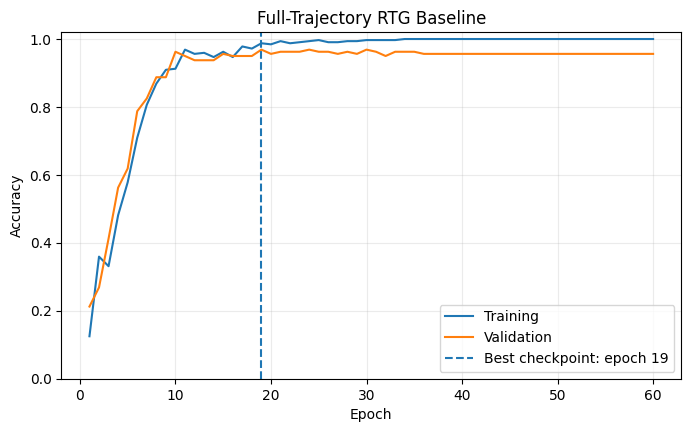

In [23]:
history = baseline_run["history"]

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(
    history["epoch"],
    history["train_accuracy"],
    label="Training",
)

ax.plot(
    history["epoch"],
    history["val_accuracy_most_certain"],
    label="Validation",
)

best_epoch = baseline_run["summary"]["best_epoch"]

ax.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best checkpoint: epoch {best_epoch}",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Full-Trajectory RTG Baseline")
ax.set_ylim(0.0, 1.02)

ax.legend()
ax.grid(alpha=0.25)

plt.show()

### 6.1 Validation-selected checkpoint

Performance increased rapidly during the first part of training.

The best validation checkpoint occurred at epoch 19.

At this checkpoint:

| Metric | Accuracy |
|---|---:|
| Training, most-certain tick | 98.4% |
| Validation, most-certain tick | 96.9% |
| Validation, final tick | 96.9% |

Training eventually reached 100% accuracy at later epochs, while validation performance remained approximately stable and validation loss began to increase.

The epoch-19 checkpoint is therefore retained for subsequent evaluation rather than using the final epoch-60 model.

In [9]:
from experiment_runner import evaluate_model

test_metrics = evaluate_model(
    baseline_run["model"],
    bundle["test_loader"],
    baseline_run["device"],
)

test_metrics

{'loss': 0.11228127609938383,
 'accuracy_most_certain': 0.9625,
 'accuracy_final_tick': 0.9625,
 'mean_most_certain_tick': 24.875,
 'mean_selected_certainty': 0.9575711965560914}

### 6.2 Held-out test result

After model selection was completed using repetition 2, the retained epoch-19 checkpoint was evaluated on repetition 3.

The held-out test results are:

| Metric | Result |
|---|---:|
| Most-certain-tick accuracy | 96.25% |
| Final-tick accuracy | 96.25% |
| Test loss | 0.1123 |
| Mean most-certain tick | 24.88 / 25 |
| Mean selected certainty | 0.958 |

The model correctly classified:

$$
154 / 160
$$

held-out test trajectories.

The close agreement between training, validation, and test performance indicates that the full-trajectory CTM baseline generalizes well to the held-out repetition under the current experimental protocol.

This result establishes the reference performance against which the subsequent partial-observation, temporal-window, noise, and internal-computation experiments will be compared.

### 6.3 Error Structure on the Held-Out Test Set

Overall test accuracy summarizes how often the model is correct, but it does not show whether the remaining errors are concentrated in particular target classes.

To inspect the structure of the six test errors, the retained epoch-19 checkpoint is used to collect predictions for every recording in the held-out repetition-3 test set.

The confusion matrix compares the true target class with the class predicted at the CTM's most-certain internal tick.

Per-class recall is also computed as:

$$
\mathrm{Recall}_c
=
\frac{
\text{correct predictions for class } c
}{
\text{number of test recordings belonging to class } c
}.
$$

Because the test split contains exactly 20 recordings from each of the eight classes, differences in recall can be interpreted directly without correcting for class imbalance.

In [25]:
test_outputs = rtg_experiment_runner.collect_split_predictions(
    model=baseline_run["model"],
    loader=bundle["test_loader"],
    device=baseline_run["device"],
)

targets = test_outputs["targets"]
predictions = test_outputs["most_certain_prediction"]

print("Number of test recordings:", len(targets))
print("Number correct:", (targets == predictions).sum())
print("Number incorrect:", (targets != predictions).sum())

Number of test recordings: 160
Number correct: 154
Number incorrect: 6


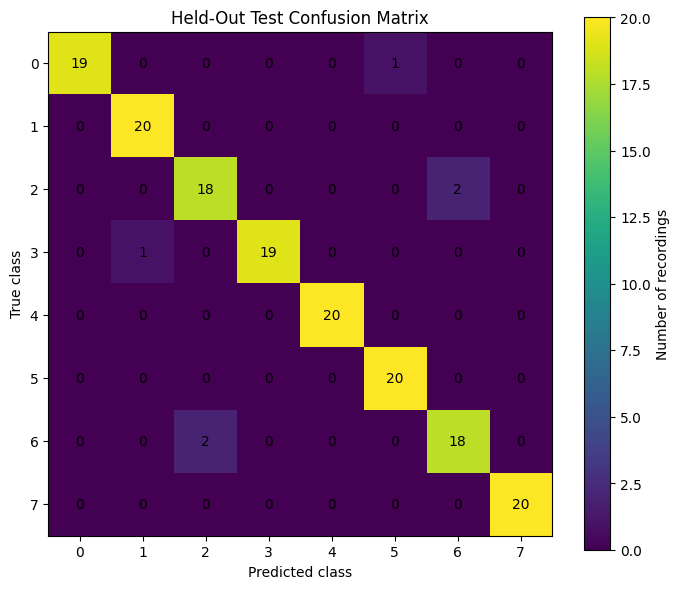

In [26]:
import numpy as np
import matplotlib.pyplot as plt

n_classes = 8

confusion_matrix = np.zeros(
    (n_classes, n_classes),
    dtype=int,
)

for true_class, predicted_class in zip(
    targets,
    predictions,
):
    confusion_matrix[
        true_class,
        predicted_class,
    ] += 1


fig, ax = plt.subplots(
    figsize=(7, 6)
)

image = ax.imshow(
    confusion_matrix,
)

ax.set_xticks(
    range(n_classes)
)

ax.set_yticks(
    range(n_classes)
)

ax.set_xlabel(
    "Predicted class"
)

ax.set_ylabel(
    "True class"
)

ax.set_title(
    "Held-Out Test Confusion Matrix"
)

for true_class in range(n_classes):
    for predicted_class in range(n_classes):

        ax.text(
            predicted_class,
            true_class,
            confusion_matrix[
                true_class,
                predicted_class,
            ],
            ha="center",
            va="center",
        )

fig.colorbar(
    image,
    ax=ax,
    label="Number of recordings",
)

plt.tight_layout()
plt.show()

In [27]:
import pandas as pd

per_class_results = []

for class_id in range(n_classes):

    class_mask = (
        targets == class_id
    )

    n_class = class_mask.sum()

    n_correct = (
        predictions[class_mask]
        == targets[class_mask]
    ).sum()

    recall = (
        n_correct / n_class
    )

    per_class_results.append(
        {
            "class_label": class_id,
            "n_test": int(n_class),
            "n_correct": int(n_correct),
            "n_errors": int(
                n_class - n_correct
            ),
            "recall": recall,
        }
    )


per_class_results = pd.DataFrame(
    per_class_results
)

per_class_results

,class_label,n_test,n_correct,n_errors,recall
0,0,20,19,1,0.95
1,1,20,20,0,1.00
2,2,20,18,2,0.90
3,3,20,19,1,0.95
4,4,20,20,0,1.00
5,5,20,20,0,1.00
6,6,20,18,2,0.90
7,7,20,20,0,1.00


### 6.3 Interpretation

The held-out test set contains 160 recordings, of which 154 are classified correctly and 6 incorrectly.

Performance is strong across all eight target classes:

| Class | Correct | Errors | Recall |
|---:|---:|---:|---:|
| 0 | 19 / 20 | 1 | 95% |
| 1 | 20 / 20 | 0 | 100% |
| 2 | 18 / 20 | 2 | 90% |
| 3 | 19 / 20 | 1 | 95% |
| 4 | 20 / 20 | 0 | 100% |
| 5 | 20 / 20 | 0 | 100% |
| 6 | 18 / 20 | 2 | 90% |
| 7 | 20 / 20 | 0 | 100% |

Four classes are classified perfectly on the held-out repetition.

The six errors are distributed as follows:

- one class-0 recording is predicted as class 5
- two class-2 recordings are predicted as class 6
- one class-3 recording is predicted as class 1
- two class-6 recordings are predicted as class 2

The most prominent error pattern is therefore a reciprocal confusion between classes 2 and 6.

This pattern should not yet be interpreted as evidence that these two object classes are intrinsically similar. Establishing the cause would require relating the class labels back to the corresponding objects and examining their trajectories, spatial configurations, and participant-level errors.

Importantly, no class exhibits a severe performance collapse. Even the two lowest-recall classes, 2 and 6, achieve 90% recall.

The full-trajectory baseline therefore provides strong and relatively balanced held-out-repetition performance across the complete eight-class task.

## 7. CTM Internal Computation Analysis

The full-trajectory baseline uses 25 CTM internal ticks.

These internal ticks should not be confused with the 100 temporal positions of the reach-to-grasp trajectory.

The two dimensions represent different processes:

- the 100 trajectory positions describe the observed human movement
- the 25 internal ticks describe successive steps of CTM computation after receiving that input

The baseline test result showed a mean most-certain tick of approximately 24.9 out of 25. However, this value only indicates where the model's maximum certainty tends to occur.

It does not show when the model first becomes capable of making an accurate classification.

To examine the development of the decision across internal computation, the retained epoch-19 baseline checkpoint is evaluated at every internal tick on the same held-out repetition-3 test set.

No retraining is performed for this analysis.

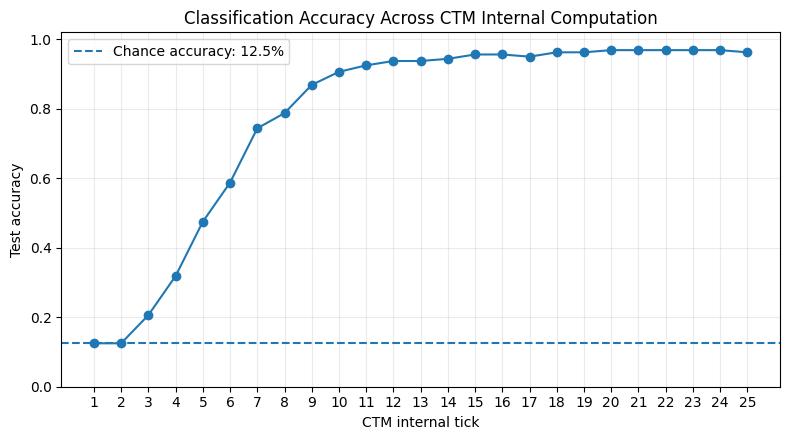

In [28]:
accuracy_per_tick = test_outputs["accuracy_per_tick"]

ticks = np.arange(
    1,
    len(accuracy_per_tick) + 1,
)

fig, ax = plt.subplots(
    figsize=(8, 4.5)
)

ax.plot(
    ticks,
    accuracy_per_tick,
    marker="o",
)

ax.axhline(
    0.125,
    linestyle="--",
    label="Chance accuracy: 12.5%",
)

ax.set_xlabel(
    "CTM internal tick"
)

ax.set_ylabel(
    "Test accuracy"
)

ax.set_title(
    "Classification Accuracy Across CTM Internal Computation"
)

ax.set_xticks(
    ticks
)

ax.set_ylim(
    0.0,
    1.02,
)

ax.grid(
    alpha=0.25
)

ax.legend()

plt.tight_layout()
plt.show()

In [29]:
tick_summary = pd.DataFrame(
    {
        "internal_tick": ticks,
        "test_accuracy": accuracy_per_tick,
    }
)

tick_summary

,internal_tick,test_accuracy
0,1,0.12500
1,2,0.12500
2,3,0.20625
3,4,0.31875
4,5,0.47500
5,6,0.58750
6,7,0.74375
7,8,0.78750
8,9,0.86875
9,10,0.90625


### 7.1 Internal computation dynamics

Classification performance develops progressively across CTM internal computation.

At the first two internal ticks, test accuracy remains at the 12.5% chance level.

Performance then increases rapidly:

| Internal tick | Test accuracy |
|---:|---:|
| 1 | 12.5% |
| 5 | 47.5% |
| 7 | 74.4% |
| 10 | 90.6% |
| 15 | 95.6% |
| 20 | 96.9% |
| 24 | 96.9% |
| 25 | 96.2% |

The CTM therefore does not produce its final classification quality immediately. Useful object-specific information emerges progressively across successive internal computation steps.

Importantly, the model reaches more than 90% test accuracy by internal tick 10 and approximately 95% by tick 15.

The maximum observed test accuracy of 96.9% is reached at ticks 20 through 24.

This provides a more informative interpretation than the mean most-certain tick alone. Although maximum certainty usually occurs very late, near tick 25, classification accuracy has already approached its final level several internal ticks earlier.

The result therefore suggests a distinction between:

- when the CTM becomes capable of making a correct decision
- when the CTM becomes maximally certain about that decision

This distinction will be important when later experiments explicitly vary the available internal-computation budget.

## 8. Current Findings and Experimental Roadmap

The first real-data CTM baseline is now complete.

The preprocessing, experimental split, model integration, held-out evaluation, and internal-computation analysis establish a stable reference point for the remaining RTG experiments.

### 8.1 Findings so far

The current results support several observations.

#### Full reach-to-grasp trajectories are highly informative

Using the complete B1-B4 trajectory, the CTM achieved:

- 98.4% training accuracy at the selected checkpoint
- 96.9% validation accuracy
- 96.25% held-out test accuracy

The test set contained 160 recordings, of which 154 were classified correctly.

Performance was also balanced across classes. Per-class recall ranged from 90% to 100%, with no class showing a major performance collapse.

#### The model generalizes across held-out repetitions

The model was trained using repetitions 0 and 1 and evaluated on repetitions that were not used for parameter optimization.

The high validation and test performance therefore shows that the CTM can generalize to new repetitions of the reach-to-grasp task under the current participant and block conditions.

This result does not yet establish generalization to unseen participants or unseen experimental configurations.

#### Classification develops across CTM internal computation

Test accuracy was initially at the 12.5% chance level during the first two internal ticks.

It then increased progressively:

| Internal tick | Test accuracy |
|---:|---:|
| 1 | 12.5% |
| 5 | 47.5% |
| 7 | 74.4% |
| 10 | 90.6% |
| 15 | 95.6% |
| 20 | 96.9% |
| 24 | 96.9% |
| 25 | 96.2% |

The model therefore approaches its final classification performance before reaching its maximum-certainty point.

This suggests that decision quality and maximum certainty should be treated as related but distinct properties of CTM computation.

### 8.2 Two temporal dimensions

The RTG experiments contain two different notions of time.

The first is **external observation time**:

> How much of the human reach-to-grasp movement has the model observed?

This corresponds to the 100 resampled positions of the movement trajectory.

The second is **internal computation time**:

> How much CTM computation is performed after receiving the available movement information?

This corresponds to the CTM internal ticks.

The full-trajectory baseline held external observation time fixed at 100% while examining the development of classification across internal ticks.

The next experiments will begin varying external observation time.

### 8.3 Experimental roadmap

The remaining RTG experiments are organized around the following questions.

**Experiment 2: Full-trained model evaluated on partial trajectories**

How much of the movement is required before the already-trained full-trajectory CTM can recognize the target object?

This tests generalization from complete trajectories to incomplete observations without retraining the model.

**Experiment 3: Matched partial-observation training**

How well can CTMs perform when they are trained specifically for limited observation durations?

Separate models will be trained using different fractions of the movement.

This distinguishes lack of available information from distribution shift caused by presenting a full-trajectory model with shortened inputs.

**Experiment 4: Temporal position**

Is target information equally available throughout the movement?

Beginning, middle, and late trajectory windows will be compared while controlling observation duration.

**Experiment 5: Noise robustness**

How robust is classification when realistic correlated perturbations are added to the kinematic trajectories?

The Wiener-process experiments from the synthetic stage provide the starting methodology.

**Experiment 6: Internal computation budget**

How much internal CTM computation is actually required?

Models with different internal-tick budgets will be compared rather than only inspecting intermediate outputs from a model trained with 25 ticks.

### 8.4 Later extensions

Additional experiments may subsequently investigate:

- B0-to-B1-B4 transfer
- generalization to unseen participants
- participant-specific performance
- block and spatial-configuration effects
- detailed analysis of misclassified trajectories
- CTM population and activation dynamics

These extensions are kept separate from the initial baseline so that the first real-data experiments remain interpretable and reproducible.

## 9. Experiment 2: Full-Trained CTM on Partial Trajectories

The full-trajectory baseline established that the CTM can classify held-out reach-to-grasp repetitions with high accuracy when the complete movement trajectory is available.

The next experiment asks whether the same trained model can retain useful classification performance when only part of the movement is observed.

The epoch-19 baseline checkpoint is kept fixed.

No additional training or parameter optimization is performed.

Instead, each held-out test trajectory is truncated to a prefix of the original 100 resampled temporal positions.

The evaluated observation lengths are:

- 10% of the movement
- 25% of the movement
- 50% of the movement
- 75% of the movement
- 100% of the movement

These correspond to prefix lengths of:

$$
10,\ 25,\ 50,\ 75,\ 100
$$

temporal positions.

For each observation length, the same 160 held-out test recordings are evaluated.

This experiment therefore measures how well a CTM trained on complete movements generalizes to incomplete movement observations.

Because the model was trained only on full trajectories, reduced performance at short prefixes may reflect both limited movement information and distribution shift relative to the training data.

A later matched-training experiment will separate these two effects by training dedicated models on partial trajectories.

In [30]:
import importlib
import rtg_experiment_runner

importlib.reload(
    rtg_experiment_runner
)

<module 'rtg_experiment_runner' from '/Users/arthu/Desktop/CTM_Res-Pro/models/ctm/rtg_experiment_runner.py'>

In [31]:
prefix_results = (
    rtg_experiment_runner
    .evaluate_partial_prefixes(
        model=baseline_run["model"],
        loader=bundle["test_loader"],
        device=baseline_run["device"],
        prefix_lengths=(
            10,
            25,
            50,
            75,
            100,
        ),
    )
)

prefix_results

,prefix_length,fraction_observed,percent_observed,loss,accuracy_most_certain,accuracy_final_tick,mean_most_certain_tick,mean_selected_certainty
0,10,0.10,10.0,3.130514,0.34375,0.3375,24.61250,0.820211
1,25,0.25,25.0,1.858247,0.49375,0.5000,24.52500,0.831098
2,50,0.50,50.0,0.798598,0.73750,0.7375,24.61875,0.880950
3,75,0.75,75.0,0.262355,0.90000,0.9000,24.80000,0.929084
4,100,1.00,100.0,0.112281,0.96250,0.9625,24.87500,0.957571


In [32]:
full_prefix_accuracy = (
    prefix_results.loc[
        prefix_results["prefix_length"] == 100,
        "accuracy_most_certain",
    ]
    .iloc[0]
)

print(
    "100% prefix accuracy:",
    full_prefix_accuracy,
)

100% prefix accuracy: 0.9625


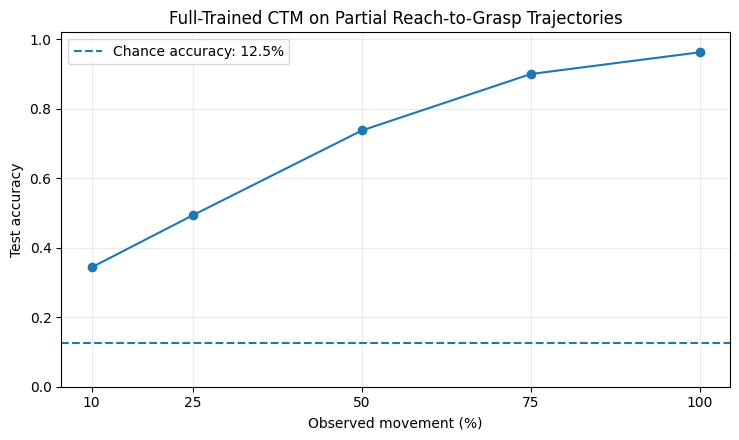

In [33]:
fig, ax = plt.subplots(
    figsize=(7.5, 4.5)
)

ax.plot(
    prefix_results[
        "percent_observed"
    ],
    prefix_results[
        "accuracy_most_certain"
    ],
    marker="o",
)

ax.axhline(
    0.125,
    linestyle="--",
    label="Chance accuracy: 12.5%",
)

ax.set_xlabel(
    "Observed movement (%)"
)

ax.set_ylabel(
    "Test accuracy"
)

ax.set_title(
    "Full-Trained CTM on Partial Reach-to-Grasp Trajectories"
)

ax.set_xticks(
    prefix_results[
        "percent_observed"
    ]
)

ax.set_ylim(
    0.0,
    1.02,
)

ax.grid(
    alpha=0.25
)

ax.legend()

plt.tight_layout()
plt.show()

### 9.1 Partial-observation result

The frozen full-trajectory CTM shows a clear dependence on the amount of observed reach-to-grasp movement.

Test accuracy increases monotonically with observation duration:

| Observed movement | Test accuracy |
|---:|---:|
| 10% | 34.4% |
| 25% | 49.4% |
| 50% | 73.8% |
| 75% | 90.0% |
| 100% | 96.25% |

Even the first 10% of the resampled movement produces accuracy above the 12.5% chance level.

However, substantial additional information becomes available as the reach progresses. Accuracy increases to approximately 74% after half of the movement and 90% after three quarters of the movement.

The result therefore suggests that target-related kinematic information develops progressively throughout the reach-to-grasp trajectory rather than appearing only near object lift.

Because this model was trained exclusively on complete trajectories, reduced performance on short prefixes cannot be attributed solely to insufficient movement information. The truncated inputs also represent a distribution shift relative to the model's training data.

A matched partial-observation training experiment is therefore required to determine how much information each prefix contains when the CTM is explicitly trained to operate at that observation duration.

The CTM's selected certainty also increases with observation duration, from approximately 0.82 at 10% observation to 0.96 for the complete trajectory.

However, certainty remains relatively high even when short-prefix classification accuracy is much lower. Certainty should therefore not yet be interpreted as a calibrated measure of available decision evidence.

Across all prefix lengths, the most-certain prediction continues to occur near the end of the 25-tick internal-computation budget.

## 10. Experiment 3: Matched Partial-Observation Training

Experiment 2 evaluated shortened trajectories using a CTM that had been trained exclusively on complete movements.

The resulting decrease in accuracy could therefore arise from two sources:

1. less task-relevant information is available early in the movement
2. shortened trajectories differ from the full trajectories used during training

To separate these effects, a separate CTM is now trained for each observation duration.

The evaluated movement prefixes are:

$$
10\%,\ 25\%,\ 50\%,\ 75\%,\ 100\%.
$$

Each model uses the same fixed repetition split and the same training-derived feature standardization as the full-trajectory baseline.

For every observation length:

- repetitions 0 and 1 are used for training
- repetition 2 is used for checkpoint selection
- repetition 3 is used for final evaluation

The CTM architecture and optimization settings remain unchanged.

The only difference between conditions is the amount of the reach-to-grasp trajectory available to the model.

In [34]:
import importlib
import rtg_experiment_runner

importlib.reload(
    rtg_experiment_runner
)

<module 'rtg_experiment_runner' from '/Users/arthu/Desktop/CTM_Res-Pro/models/ctm/rtg_experiment_runner.py'>

In [35]:
matched_prefix_results = (
    rtg_experiment_runner
    .run_matched_prefix_training(
        bundle=bundle,
        config=config,
        prefix_lengths=(
            10,
            25,
            50,
            75,
            100,
        ),
        max_epochs=60,
        verbose=True,
    )
)

matched_prefix_results


Matched prefix training: 10/100 (10%)
Using neuron select type: random-pairing
Synch representation size action: 32
Synch representation size out: 32
prefix  10 | epoch 001 | train loss 2.0771 | val MC 0.125 | val final 0.138
prefix  10 | epoch 002 | train loss 2.0205 | val MC 0.150 | val final 0.169
prefix  10 | epoch 003 | train loss 1.9495 | val MC 0.281 | val final 0.275
prefix  10 | epoch 004 | train loss 1.8116 | val MC 0.300 | val final 0.300
prefix  10 | epoch 005 | train loss 1.6470 | val MC 0.319 | val final 0.319
prefix  10 | epoch 006 | train loss 1.4993 | val MC 0.388 | val final 0.388
prefix  10 | epoch 007 | train loss 1.3753 | val MC 0.431 | val final 0.431
prefix  10 | epoch 008 | train loss 1.2423 | val MC 0.494 | val final 0.494
prefix  10 | epoch 009 | train loss 1.1194 | val MC 0.544 | val final 0.550
prefix  10 | epoch 010 | train loss 1.0150 | val MC 0.544 | val final 0.550
prefix  10 | epoch 011 | train loss 0.9618 | val MC 0.575 | val final 0.575
prefix  10 | 

,prefix_length,fraction_observed,percent_observed,best_epoch,train_accuracy_most_certain,val_accuracy_most_certain,test_accuracy_most_certain,test_accuracy_final_tick,test_loss,test_mean_most_certain_tick,test_mean_selected_certainty
0,10,0.10,10.0,51,0.937500,0.75000,0.71250,0.68125,1.101806,23.81250,0.881127
1,25,0.25,25.0,60,1.000000,0.86875,0.84375,0.83750,0.648735,23.73750,0.956708
2,50,0.50,50.0,37,0.984375,0.93125,0.89375,0.90625,0.266760,24.36875,0.961386
3,75,0.75,75.0,35,1.000000,0.95000,0.95000,0.94375,0.176420,24.78125,0.967879
4,100,1.00,100.0,19,0.984375,0.96875,0.96250,0.96250,0.112281,24.87500,0.957571


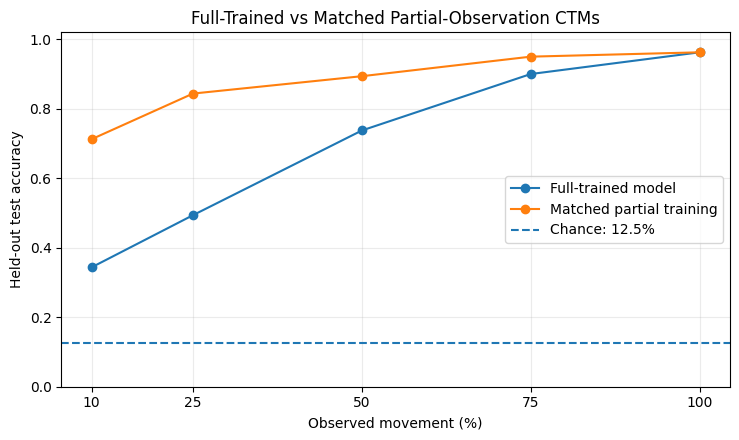

In [36]:
fig, ax = plt.subplots(
    figsize=(7.5, 4.5)
)

ax.plot(
    prefix_results[
        "percent_observed"
    ],
    prefix_results[
        "accuracy_most_certain"
    ],
    marker="o",
    label="Full-trained model",
)

ax.plot(
    matched_prefix_results[
        "percent_observed"
    ],
    matched_prefix_results[
        "test_accuracy_most_certain"
    ],
    marker="o",
    label="Matched partial training",
)

ax.axhline(
    0.125,
    linestyle="--",
    label="Chance: 12.5%",
)

ax.set_xlabel(
    "Observed movement (%)"
)

ax.set_ylabel(
    "Held-out test accuracy"
)

ax.set_title(
    "Full-Trained vs Matched Partial-Observation CTMs"
)

ax.set_xticks(
    [
        10,
        25,
        50,
        75,
        100,
    ]
)

ax.set_ylim(
    0.0,
    1.02,
)

ax.grid(
    alpha=0.25
)

ax.legend()

plt.tight_layout()
plt.show()

### 10.1 Matched partial-observation result

Training CTMs specifically for partial movement observation substantially improves early intention classification.

The comparison with the frozen full-trajectory model is:

| Observed movement | Full-trained model | Matched partial training |
|---:|---:|---:|
| 10% | 34.4% | 71.3% |
| 25% | 49.4% | 84.4% |
| 50% | 73.8% | 89.4% |
| 75% | 90.0% | 95.0% |
| 100% | 96.25% | 96.25% |

The largest differences occur at the shortest observation durations.

At 10% observation, matched training improves held-out test accuracy by approximately 37 percentage points.

At 25% observation, the improvement is approximately 35 percentage points.

The performance difference becomes progressively smaller as more of the movement is observed and disappears for the complete trajectory.

This result shows that the low short-prefix accuracy of the full-trained model cannot be interpreted as evidence that early reach-to-grasp kinematics contain little target information.

Instead, substantial target-related information is already present early in the movement, but a model trained only on complete trajectories does not fully exploit it when presented with strongly truncated inputs.

The matched 10% model achieves 71.3% accuracy and the matched 25% model achieves 84.4% accuracy on held-out repetitions, demonstrating that intention-related structure can be learned from relatively early portions of the movement.

The 100% matched condition reproduces the original full-trajectory baseline, providing a consistency check for the matched-training implementation.

The 25% model selected its best validation checkpoint at the 60-epoch training limit, so its reported performance should not be interpreted as a fully converged upper bound.

## 11. Experiment 4: Internal Computation Budget

The previous internal-tick analysis examined intermediate predictions from a CTM that had been trained with 25 internal ticks.

That analysis showed when classification accuracy emerged during the computation of a 25-tick model, but it did not determine whether the CTM could learn the task when explicitly restricted to fewer computation steps.

This experiment therefore trains separate CTMs using different internal-computation budgets:

$$
5,\ 10,\ 15,\ 25
$$

internal ticks.

The complete 100-position reach-to-grasp trajectory is provided in every condition.

External movement observation is therefore held constant while only the amount of CTM internal computation changes.

All other experimental settings remain fixed:

- repetitions 0 and 1 for training
- repetition 2 for validation-based checkpoint selection
- repetition 3 for held-out testing
- identical input standardization
- identical CTM dimensions
- identical optimizer settings
- identical random seed

This experiment distinguishes intermediate outputs of a 25-tick model from the performance of models that are actually trained to operate under restricted internal-computation budgets.

In [45]:
import importlib
import rtg_experiment_runner

importlib.reload(
    rtg_experiment_runner
)

<module 'rtg_experiment_runner' from '/Users/arthu/Desktop/CTM_Res-Pro/models/ctm/rtg_experiment_runner.py'>

In [46]:
tick_budget_results = (
    rtg_experiment_runner
    .run_internal_tick_budget_sweep(
        bundle=bundle,
        config=config,
        tick_budgets=(
            5,
            10,
            15,
            25,
        ),
        max_epochs=60,
        verbose=False,
    )
)

tick_budget_results


Internal-tick budget: 5
Device: mps
Using neuron select type: random-pairing
Synch representation size action: 32
Synch representation size out: 32
Prediction shape: (32, 8, 5)
Certainty shape: (32, 2, 5)
Trainable parameters: 328,970

Best checkpoint
epoch: 40
train MC accuracy: 0.997
validation MC accuracy: 0.975
validation final-tick accuracy: 0.969
validation mean MC tick: 4.97
saved to: results/rtg/20260926T232140Z_b1_b4_tick_budget_5_seed0

Held-out test result:
MC accuracy: 0.944
final-tick accuracy: 0.944
mean most-certain tick: 4.97

Internal-tick budget: 10
Device: mps
Using neuron select type: random-pairing
Synch representation size action: 32
Synch representation size out: 32
Prediction shape: (32, 8, 10)
Certainty shape: (32, 2, 10)
Trainable parameters: 328,970

Best checkpoint
epoch: 22
train MC accuracy: 0.981
validation MC accuracy: 0.969
validation final-tick accuracy: 0.969
validation mean MC tick: 9.99
saved to: results/rtg/20260926T232156Z_b1_b4_tick_budget_10_se

,internal_ticks,best_epoch,train_accuracy_most_certain,val_accuracy_most_certain,test_accuracy_most_certain,test_accuracy_final_tick,test_loss,test_mean_most_certain_tick,test_mean_selected_certainty,checkpoint_dir
0,5,40,0.996875,0.97500,0.94375,0.94375,0.159475,4.97500,0.968327,results/rtg/20260926T232140Z_b1_b4_tick_budget...
1,10,22,0.981250,0.96875,0.96875,0.96875,0.127700,9.96875,0.954813,results/rtg/20260926T232156Z_b1_b4_tick_budget...
2,15,29,0.990625,0.98125,0.96875,0.96250,0.124721,14.88125,0.982266,results/rtg/20260926T232218Z_b1_b4_tick_budget...
3,25,19,0.984375,0.96875,0.96250,0.96250,0.112281,24.87500,0.957571,results/rtg/20260926T232252Z_b1_b4_tick_budget...


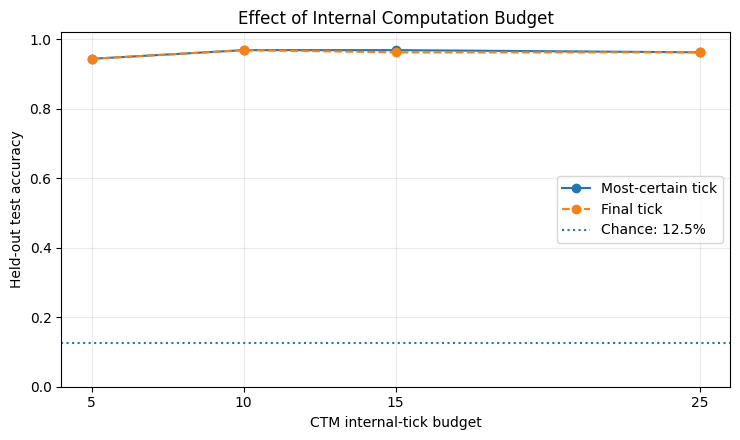

In [48]:
fig, ax = plt.subplots(
    figsize=(7.5, 4.5)
)

ax.plot(
    tick_budget_results[
        "internal_ticks"
    ],
    tick_budget_results[
        "test_accuracy_most_certain"
    ],
    marker="o",
    label="Most-certain tick",
)

ax.plot(
    tick_budget_results[
        "internal_ticks"
    ],
    tick_budget_results[
        "test_accuracy_final_tick"
    ],
    marker="o",
    linestyle="--",
    label="Final tick",
)

ax.axhline(
    0.125,
    linestyle=":",
    label="Chance: 12.5%",
)

ax.set_xlabel(
    "CTM internal-tick budget"
)

ax.set_ylabel(
    "Held-out test accuracy"
)

ax.set_title(
    "Effect of Internal Computation Budget"
)

ax.set_xticks(
    tick_budget_results[
        "internal_ticks"
    ]
)

ax.set_ylim(
    0.0,
    1.02,
)

ax.grid(
    alpha=0.25
)

ax.legend()

plt.tight_layout()
plt.show()

### 11.1 Internal-computation budget result

Restricting the CTM to fewer internal ticks has only a small effect when the complete reach-to-grasp trajectory is available.

Held-out test performance is:

| Internal ticks | Most-certain accuracy | Final-tick accuracy |
|---:|---:|---:|
| 5 | 94.4% | 94.4% |
| 10 | 96.9% | 96.9% |
| 15 | 96.9% | 96.3% |
| 25 | 96.3% | 96.3% |

The 5-tick model performs slightly worse than the longer-budget models, but by 10 internal ticks the CTM already reaches approximately the same held-out accuracy as the 25-tick baseline.

There is therefore no clear evidence that increasing the computation budget beyond approximately 10 ticks improves classification when the complete movement trajectory is available.

The most-certain prediction occurs close to the end of the available computation budget in every condition:

- 5-tick model: mean most-certain tick ≈ 5
- 10-tick model: mean most-certain tick ≈ 10
- 15-tick model: mean most-certain tick ≈ 15
- 25-tick model: mean most-certain tick ≈ 25

This indicates that the model tends to use the full computation budget it is given, even though classification accuracy saturates with substantially fewer ticks.

The slightly higher test accuracy of the 10- and 15-tick models relative to the 25-tick model should not be interpreted as evidence that those budgets are intrinsically superior. The differences correspond to only one or two test recordings and are small relative to the overall performance level.

The result instead suggests that the full-trajectory classification task provides sufficiently strong external evidence that long internal computation is not required for high accuracy.

## 12. Experiment 4b: Internal Computation Under Limited External Evidence

The previous experiment varied internal computation while providing the complete reach-to-grasp trajectory.

Under this condition, classification accuracy was already very high even with a small internal-tick budget.

This may make the full-trajectory task too easy to reveal a meaningful relationship between available evidence and internal computation.

The next experiment therefore combines two controlled restrictions:

1. limited external movement evidence
2. limited internal CTM computation

Only the first 10% of each reach-to-grasp trajectory is provided to the model.

Separate CTMs are then trained with internal computation budgets of:

$$
5,\ 10,\ 15,\ 25
$$

ticks.

All other experimental conditions remain unchanged.

This experiment asks:

> When only a small amount of movement information is available, does additional CTM internal computation improve held-out classification?

The 10% trajectory condition is chosen because the matched partial-observation experiment achieved approximately 71% test accuracy, leaving substantial uncertainty while still remaining well above chance.

This setup therefore provides a more informative regime for studying the interaction between external evidence and internal computation.

It also provides a natural bridge toward later Drift Diffusion Model analyses, where decision quality is studied as evidence accumulates over a sequence of computational states.

In [49]:
import importlib
import rtg_experiment_runner

importlib.reload(
    rtg_experiment_runner
)

<module 'rtg_experiment_runner' from '/Users/arthu/Desktop/CTM_Res-Pro/models/ctm/rtg_experiment_runner.py'>

In [50]:
limited_tick_results = (
    rtg_experiment_runner
    .run_limited_evidence_tick_sweep(
        bundle=bundle,
        config=config,
        prefix_length=10,
        tick_budgets=(
            5,
            10,
            15,
            25,
        ),
        max_epochs=60,
        verbose=False,
    )
)

limited_tick_results


External evidence: 10/100 (10%)
Internal-tick budget: 5
Device: mps
Using neuron select type: random-pairing
Synch representation size action: 32
Synch representation size out: 32
Prediction shape: (32, 8, 5)
Certainty shape: (32, 2, 5)
Trainable parameters: 328,970

Best checkpoint
epoch: 52
train MC accuracy: 0.894
validation MC accuracy: 0.738
validation final-tick accuracy: 0.731
validation mean MC tick: 4.96
saved to: results/rtg/20260926T232901Z_b1_b4_prefix_10_ticks_5_seed0

Held-out test result:
MC accuracy: 0.706
final-tick accuracy: 0.713
mean most-certain tick: 4.99

External evidence: 10/100 (10%)
Internal-tick budget: 10
Device: mps
Using neuron select type: random-pairing
Synch representation size action: 32
Synch representation size out: 32
Prediction shape: (32, 8, 10)
Certainty shape: (32, 2, 10)
Trainable parameters: 328,970

Best checkpoint
epoch: 57
train MC accuracy: 0.975
validation MC accuracy: 0.762
validation final-tick accuracy: 0.756
validation mean MC tick:

,prefix_length,percent_observed,internal_ticks,best_epoch,train_accuracy_most_certain,val_accuracy_most_certain,test_accuracy_most_certain,test_accuracy_final_tick,test_loss,test_mean_most_certain_tick,test_mean_selected_certainty,checkpoint_dir
0,10,10.0,5,52,0.89375,0.73750,0.70625,0.71250,1.047893,4.98750,0.840268,results/rtg/20260926T232901Z_b1_b4_prefix_10_t...
1,10,10.0,10,57,0.97500,0.76250,0.72500,0.71875,1.097515,9.95000,0.876450,results/rtg/20260926T232917Z_b1_b4_prefix_10_t...
2,10,10.0,15,60,0.96875,0.75625,0.70000,0.71250,1.249904,14.70625,0.890700,results/rtg/20260926T232938Z_b1_b4_prefix_10_t...
3,10,10.0,25,51,0.93750,0.75000,0.71250,0.68125,1.101806,23.81250,0.881127,results/rtg/20260926T233011Z_b1_b4_prefix_10_t...


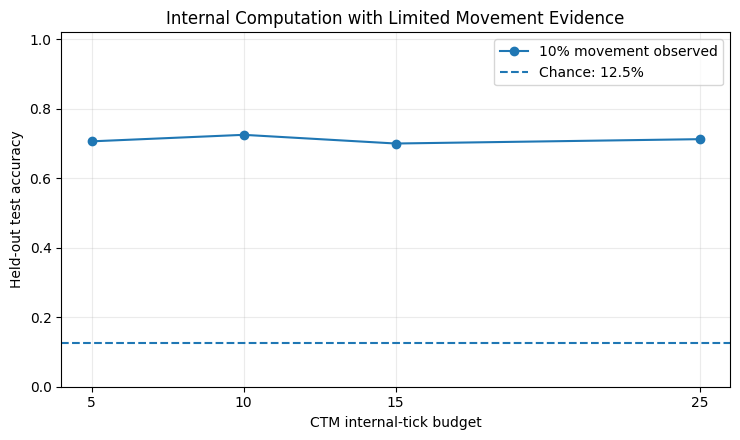

In [51]:
fig, ax = plt.subplots(
    figsize=(7.5, 4.5)
)

ax.plot(
    limited_tick_results[
        "internal_ticks"
    ],
    limited_tick_results[
        "test_accuracy_most_certain"
    ],
    marker="o",
    label="10% movement observed",
)

ax.axhline(
    0.125,
    linestyle="--",
    label="Chance: 12.5%",
)

ax.set_xlabel(
    "CTM internal-tick budget"
)

ax.set_ylabel(
    "Held-out test accuracy"
)

ax.set_title(
    "Internal Computation with Limited Movement Evidence"
)

ax.set_xticks(
    limited_tick_results[
        "internal_ticks"
    ]
)

ax.set_ylim(
    0.0,
    1.02,
)

ax.grid(
    alpha=0.25
)

ax.legend()

plt.tight_layout()
plt.show()

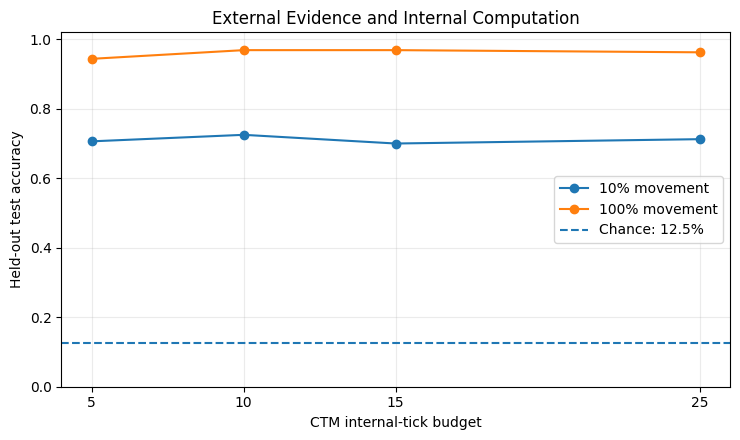

In [52]:
fig, ax = plt.subplots(
    figsize=(7.5, 4.5)
)

ax.plot(
    limited_tick_results[
        "internal_ticks"
    ],
    limited_tick_results[
        "test_accuracy_most_certain"
    ],
    marker="o",
    label="10% movement",
)

ax.plot(
    tick_budget_results[
        "internal_ticks"
    ],
    tick_budget_results[
        "test_accuracy_most_certain"
    ],
    marker="o",
    label="100% movement",
)

ax.axhline(
    0.125,
    linestyle="--",
    label="Chance: 12.5%",
)

ax.set_xlabel(
    "CTM internal-tick budget"
)

ax.set_ylabel(
    "Held-out test accuracy"
)

ax.set_title(
    "External Evidence and Internal Computation"
)

ax.set_xticks(
    [
        5,
        10,
        15,
        25,
    ]
)

ax.set_ylim(
    0.0,
    1.02,
)

ax.grid(
    alpha=0.25
)

ax.legend()

plt.tight_layout()
plt.show()

### 12.1 Limited-evidence computation result

Restricting the available movement to the first 10% substantially reduces classification accuracy compared with the complete-trajectory condition.

However, increasing the CTM internal-computation budget does not systematically recover the missing performance.

Held-out test accuracy is:

| Internal ticks | Test accuracy |
|---:|---:|
| 5 | 70.6% |
| 10 | 72.5% |
| 15 | 70.0% |
| 25 | 71.3% |

The differences correspond to only a few recordings out of the 160-sample test set and do not show a monotonic relationship between internal-tick budget and classification performance.

The 25-tick condition reproduces the earlier matched 10% partial-observation result, providing a consistency check for the implementation.

Together with the full-trajectory tick-budget experiment, these results suggest that the amount of available external movement information has a much larger influence on classification performance than the number of internal computation steps within the tested range.

Additional internal ticks do not compensate for strongly limited movement evidence under the present experimental setup.

This also changes the interpretation of the CTM internal dynamics for later decision-model analysis. Rather than treating the number of internal ticks as a direct measure of decision quality, a more informative direction is to study how decision-related quantities evolve within a trained model across those ticks.

Candidate quantities for later analysis include:

- target-class evidence
- target-versus-competitor logit margin
- model certainty
- prediction stability
- the internal tick at which a decision criterion is first crossed

These internal trajectories provide a more direct connection to later evidence-accumulation and Drift Diffusion Model analyses.

## 13. Experiment 5: Temporal Position of Movement Information

The previous partial-observation experiments varied how much of the reach-to-grasp movement was available.

This experiment instead asks whether equally sized portions of the movement contain equal amounts of target-related information.

A fixed window length of 25 temporal positions is used in every condition.

Three temporal regions are compared:

- beginning: positions 0 to 24
- middle: positions 37 to 61
- end: positions 75 to 99

Each window therefore contains exactly 25% of the resampled movement trajectory.

Separate CTMs are trained for each temporal position using the same repetition split, model architecture, optimization settings, and train-derived standardization.

Holding window length constant allows performance differences to be attributed to the temporal location of the observed movement segment rather than to the amount of input provided.

This experiment directly transfers the beginning-middle-end temporal-position design previously used with the synthetic trajectories to the real reach-to-grasp dataset.

In [53]:
import importlib
import rtg_experiment_runner

importlib.reload(
    rtg_experiment_runner
)

<module 'rtg_experiment_runner' from '/Users/arthu/Desktop/CTM_Res-Pro/models/ctm/rtg_experiment_runner.py'>

In [54]:
temporal_position_results = (
    rtg_experiment_runner
    .run_temporal_position_training(
        bundle=bundle,
        config=config,
        window_length=25,
        window_specs=(
            ("beginning", 0),
            ("middle", 37),
            ("end", 75),
        ),
        max_epochs=60,
        verbose=False,
    )
)

temporal_position_results


Temporal position: beginning
Window: [0:25] length=25
Device: mps
Using neuron select type: random-pairing
Synch representation size action: 32
Synch representation size out: 32
Prediction shape: (32, 8, 25)
Certainty shape: (32, 2, 25)
Trainable parameters: 328,970

Best checkpoint
epoch: 60
train MC accuracy: 1.000
validation MC accuracy: 0.869
validation final-tick accuracy: 0.844
validation mean MC tick: 24.06
saved to: results/rtg/20260926T233927Z_b1_b4_window_beginning_L25_seed0

Held-out test result:
MC accuracy: 0.844
final-tick accuracy: 0.838

Temporal position: middle
Window: [37:62] length=25
Device: mps
Using neuron select type: random-pairing
Synch representation size action: 32
Synch representation size out: 32
Prediction shape: (32, 8, 25)
Certainty shape: (32, 2, 25)
Trainable parameters: 328,970

Best checkpoint
epoch: 24
train MC accuracy: 0.972
validation MC accuracy: 0.938
validation final-tick accuracy: 0.938
validation mean MC tick: 24.66
saved to: results/rtg/2

,position,window_start,window_end,window_length,window_center,fraction_observed,best_epoch,train_accuracy_most_certain,val_accuracy_most_certain,test_accuracy_most_certain,test_accuracy_final_tick,test_loss,test_mean_most_certain_tick,test_mean_selected_certainty,checkpoint_dir
0,beginning,0,25,25,12.5,0.25,60,1.000000,0.86875,0.84375,0.83750,0.648735,23.73750,0.956708,results/rtg/20260926T233927Z_b1_b4_window_begi...
1,middle,37,62,25,49.5,0.25,24,0.971875,0.93750,0.93750,0.93750,0.214279,24.54375,0.944208,results/rtg/20260926T234000Z_b1_b4_window_midd...
2,end,75,100,25,87.5,0.25,35,1.000000,0.95625,0.96875,0.95625,0.112522,24.63125,0.987157,results/rtg/20260926T234033Z_b1_b4_window_end_...


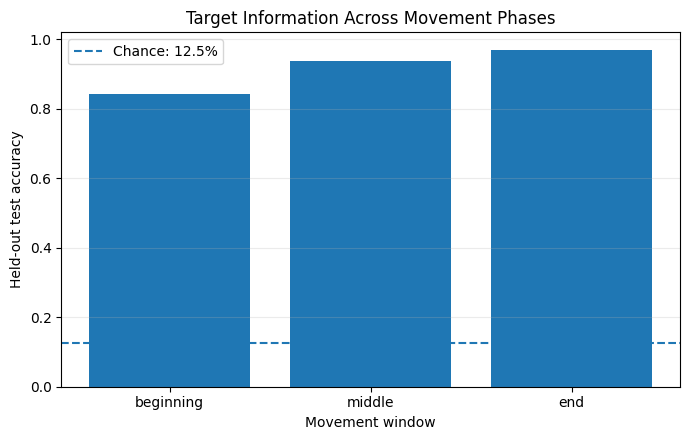

In [55]:
fig, ax = plt.subplots(
    figsize=(7, 4.5)
)

ax.bar(
    temporal_position_results[
        "position"
    ],
    temporal_position_results[
        "test_accuracy_most_certain"
    ],
)

ax.axhline(
    0.125,
    linestyle="--",
    label="Chance: 12.5%",
)

ax.set_xlabel(
    "Movement window"
)

ax.set_ylabel(
    "Held-out test accuracy"
)

ax.set_title(
    "Target Information Across Movement Phases"
)

ax.set_ylim(
    0.0,
    1.02,
)

ax.grid(
    axis="y",
    alpha=0.25,
)

ax.legend()

plt.tight_layout()
plt.show()

### 13.1 Temporal-position result

Holding observation duration fixed at 25% of the movement reveals a clear temporal structure in the real reach-to-grasp data.

Held-out test accuracy is:

| Movement window | Test accuracy |
|---|---:|
| Beginning | 84.4% |
| Middle | 93.8% |
| End | 96.9% |

The beginning-window result exactly reproduces the matched 25% prefix experiment, providing a consistency check for the temporal-window implementation.

Classification improves substantially as the observation window is moved later in the movement.

The first quarter of the reach already contains considerable target-related information, reaching 84.4% accuracy on held-out repetitions.

The middle quarter increases accuracy to 93.8%, while the final quarter reaches 96.9%, approximately matching the full-trajectory baseline.

The small numerical difference between the end-window result and the full-trajectory baseline corresponds to only one test recording and should not be interpreted as evidence that the final quarter is intrinsically superior to the complete movement.

The main result is therefore that target-related kinematic information becomes increasingly discriminative as the reach progresses.

Unlike the synthetic trajectories, where equally sized windows remained highly separable throughout the movement, the real RTG data exhibit a clear dependence on temporal position.

## 14. Experiment 6: Robustness to Temporally Correlated Noise

The synthetic experiments showed that independent frame-wise Gaussian perturbations had little effect on classification, motivating the use of temporally correlated Wiener noise.

Wiener perturbations accumulate across the trajectory and therefore produce persistent drift rather than independent noise at each temporal position.

The present experiment applies the same type of perturbation to the real RTG trajectories.

The validation-selected full-trajectory CTM checkpoint is kept fixed.

No retraining is performed.

Only the held-out repetition-3 test trajectories are perturbed.

The evaluated Wiener-noise levels are:

$$
\sigma_W
\in
\{0.0,\ 0.1,\ 0.5,\ 1.0,\ 2.0\}.
$$

Because the RTG trajectories were standardized using statistics derived from the training partition, the perturbation is applied in standardized feature space.

The same underlying Wiener realization is reused across noise levels so that the conditions differ primarily in perturbation magnitude.

This experiment therefore measures the robustness of the clean-trained CTM to increasing temporally correlated distortion of the observed movement.

In [56]:
import importlib
import rtg_experiment_runner

importlib.reload(
    rtg_experiment_runner
)

<module 'rtg_experiment_runner' from '/Users/arthu/Desktop/CTM_Res-Pro/models/ctm/rtg_experiment_runner.py'>

In [57]:
wiener_results = (
    rtg_experiment_runner
    .evaluate_wiener_robustness(
        model=baseline_run["model"],
        loader=bundle["test_loader"],
        device=baseline_run["device"],
        sigmas=(
            0.0,
            0.1,
            0.5,
            1.0,
            2.0,
        ),
        noise_seed=0,
    )
)

wiener_results

sigma= 0.0 | MC acc=0.963 | final acc=0.963 | mean tick=24.88 | certainty=0.958
sigma= 0.1 | MC acc=0.963 | final acc=0.956 | mean tick=24.88 | certainty=0.955
sigma= 0.5 | MC acc=0.838 | final acc=0.838 | mean tick=24.84 | certainty=0.903
sigma= 1.0 | MC acc=0.625 | final acc=0.625 | mean tick=24.74 | certainty=0.834
sigma= 2.0 | MC acc=0.362 | final acc=0.362 | mean tick=24.93 | certainty=0.789


,wiener_sigma,test_loss,test_accuracy_most_certain,test_accuracy_final_tick,test_mean_most_certain_tick,test_mean_selected_certainty
0,0.0,0.112281,0.9625,0.96250,24.87500,0.957571
1,0.1,0.134927,0.9625,0.95625,24.88125,0.955183
2,0.5,0.617744,0.8375,0.83750,24.83750,0.903356
3,1.0,1.528941,0.6250,0.62500,24.73750,0.834207
4,2.0,2.779895,0.3625,0.36250,24.92500,0.789319


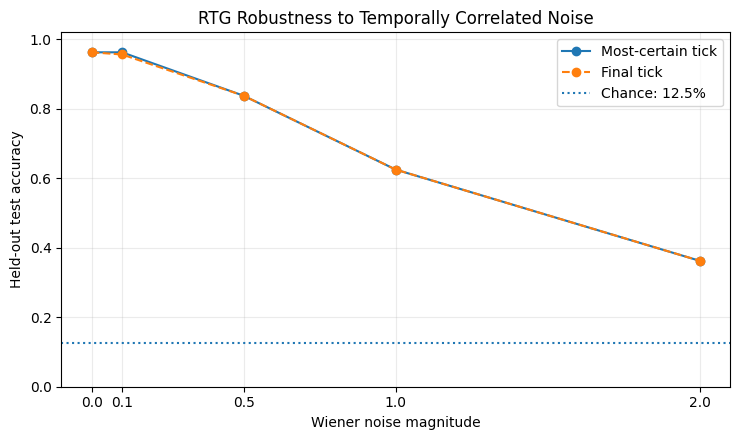

In [58]:
fig, ax = plt.subplots(
    figsize=(7.5, 4.5)
)

ax.plot(
    wiener_results[
        "wiener_sigma"
    ],
    wiener_results[
        "test_accuracy_most_certain"
    ],
    marker="o",
    label="Most-certain tick",
)

ax.plot(
    wiener_results[
        "wiener_sigma"
    ],
    wiener_results[
        "test_accuracy_final_tick"
    ],
    marker="o",
    linestyle="--",
    label="Final tick",
)

ax.axhline(
    0.125,
    linestyle=":",
    label="Chance: 12.5%",
)

ax.set_xlabel(
    "Wiener noise magnitude"
)

ax.set_ylabel(
    "Held-out test accuracy"
)

ax.set_title(
    "RTG Robustness to Temporally Correlated Noise"
)

ax.set_xticks(
    wiener_results[
        "wiener_sigma"
    ]
)

ax.set_ylim(
    0.0,
    1.02,
)

ax.grid(
    alpha=0.25
)

ax.legend()

plt.tight_layout()
plt.show()

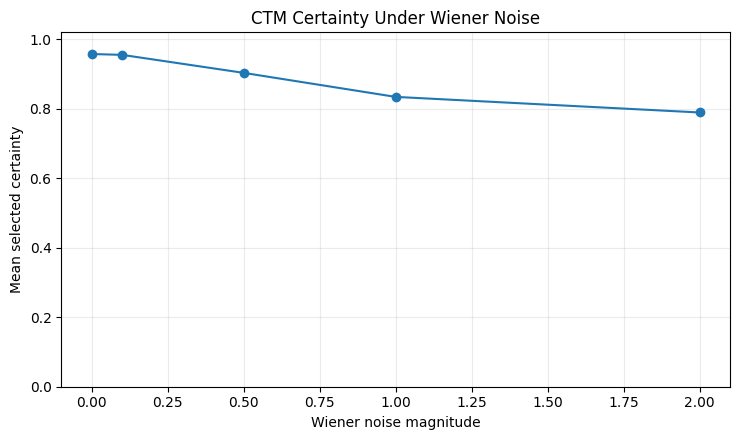

In [59]:
fig, ax = plt.subplots(
    figsize=(7.5, 4.5)
)

ax.plot(
    wiener_results[
        "wiener_sigma"
    ],
    wiener_results[
        "test_mean_selected_certainty"
    ],
    marker="o",
)

ax.set_xlabel(
    "Wiener noise magnitude"
)

ax.set_ylabel(
    "Mean selected certainty"
)

ax.set_title(
    "CTM Certainty Under Wiener Noise"
)

ax.set_ylim(
    0.0,
    1.02,
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()

### 14.1 Wiener-noise robustness result

The clean-trained CTM is robust to small temporally correlated perturbations but degrades progressively as Wiener-noise magnitude increases.

Held-out test performance is:

| Wiener noise $\sigma_W$ | Test accuracy | Mean selected certainty |
|---:|---:|---:|
| 0.0 | 96.25% | 0.958 |
| 0.1 | 96.25% | 0.955 |
| 0.5 | 83.75% | 0.903 |
| 1.0 | 62.50% | 0.834 |
| 2.0 | 36.25% | 0.789 |

Very small correlated drift has essentially no effect on classification.

At larger perturbation magnitudes, accuracy decreases substantially, reaching 83.8% at $\sigma_W = 0.5$, 62.5% at $\sigma_W = 1.0$, and 36.3% at $\sigma_W = 2.0$.

The degradation is monotonic across the tested range.

Model certainty also decreases as the perturbation becomes stronger, but considerably more slowly than classification accuracy.

At $\sigma_W = 2.0$, mean selected certainty remains approximately 0.79 even though classification accuracy has fallen to 36.3%.

The CTM certainty signal should therefore not be interpreted as a calibrated measure of decision reliability under strong distribution shift.

The mean most-certain internal tick remains close to the end of the 25-tick computation budget across all noise levels.

This suggests that additional internal computation does not compensate for severely corrupted external movement evidence in the frozen clean-trained model.

## 15. B0 to B1-B4 Transfer

The original reach-to-grasp experimental design uses B0 for model fitting and B1-B4 for evaluation under changed object locations.

The present experiment adopts the same high-level partition for CTM while deriving a harmonized trajectory representation for transfer evaluation.

The source-faithful preprocessing remains unchanged.

For this transfer experiment only, B0 and B1-B4 trajectories are re-extracted using one common reach-to-lift definition:

- movement onset: first `hand_active == 1`
- movement endpoint: 10% relative displacement of the target board sensor
- no post-lift samples
- five fingertip landmarks
- 15 coordinate channels
- 100 resampled temporal positions

The target board sensor remains block-specific according to the validated dataset metadata.

B0 is used exclusively for model development:

- B0 repetitions 0-5: training
- B0 repetitions 6-7: validation

All B1-B4 recordings remain untouched until final transfer evaluation.

Feature standardization is fitted only on the B0 training partition.

In [61]:
import importlib
import rtg_experiment_runner

importlib.reload(
    rtg_experiment_runner
)

transfer_bundle = (
    rtg_experiment_runner
    .build_b0_to_b1_b4_transfer_bundle(
        config=config
    )
)

In [62]:
transfer_metadata = (
    transfer_bundle["metadata"]
)

print(
    "Split sizes:"
)

print(
    transfer_metadata[
        "split"
    ].value_counts()
)

print(
    "\nBlocks by split:"
)

print(
    pd.crosstab(
        transfer_metadata["split"],
        transfer_metadata["block"],
    )
)

print(
    "\nClass counts by split:"
)

print(
    pd.crosstab(
        transfer_metadata["split"],
        transfer_metadata[
            "class_label"
        ],
    )
)

print(
    "\nExtraction failures:",
    len(
        transfer_bundle[
            "extraction_failures"
        ]
    ),
)

Split sizes:
split
test     640
train    238
val       80
Name: count, dtype: int64

Blocks by split:
block    0    1    2    3    4
split                         
test     0  160  160  160  160
train  238    0    0    0    0
val     80    0    0    0    0

Class counts by split:
class_label   0   1   2   3   4   5   6   7
split                                      
test         80  80  80  80  80  80  80  80
train        30  30  30  29  29  30  30  30
val          10  10  10  10  10  10  10  10

Extraction failures: 0


In [64]:
import torch

for split_name in [
    "train",
    "val",
    "test",
]:

    loader = transfer_bundle[
        f"{split_name}_loader"
    ]

    X_split, y_split = (
        loader.dataset.tensors
    )

    print(
        split_name,
        X_split.shape,
        "finite:",
        torch.isfinite(
            X_split
        ).all().item(),
    )

train torch.Size([238, 15, 100]) finite: True
val torch.Size([80, 15, 100]) finite: True
test torch.Size([640, 15, 100]) finite: True


In [65]:
X_train, _ = (
    transfer_bundle[
        "train_loader"
    ].dataset.tensors
)

X_val, _ = (
    transfer_bundle[
        "val_loader"
    ].dataset.tensors
)

X_test, _ = (
    transfer_bundle[
        "test_loader"
    ].dataset.tensors
)


print(
    "Finite:"
)

print(
    "train:",
    torch.isfinite(X_train)
    .all()
    .item()
)

print(
    "val:",
    torch.isfinite(X_val)
    .all()
    .item()
)

print(
    "test:",
    torch.isfinite(X_test)
    .all()
    .item()
)


print(
    "\nB0 training channel means:"
)

print(
    X_train.mean(
        dim=(0, 2)
    )
)


print(
    "\nB0 training channel stds:"
)

print(
    X_train.std(
        dim=(0, 2),
        unbiased=False,
    )
)

Finite:
train: True
val: True
test: True

B0 training channel means:
tensor([-3.6865e-08, -1.9219e-06,  4.0198e-06,  2.2279e-07,  2.1414e-07,
         1.4554e-06, -1.9298e-07, -1.0354e-07,  5.1290e-08, -5.8663e-07,
        -2.2568e-07, -7.1646e-07, -3.7089e-07, -2.9492e-07,  2.5164e-07])

B0 training channel stds:
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [66]:
transfer_metadata = (
    transfer_bundle[
        "metadata"
    ]
)

length_summary = (
    transfer_metadata
    .groupby("block")[
        "transfer_trajectory_length"
    ]
    .agg(
        [
            "count",
            "mean",
            "median",
            "min",
            "max",
        ]
    )
)

length_summary

,count,mean,median,min,max
block,,,,,
0,318,50.981132,52.0,2,198
1,160,62.162500,62.5,19,108
2,160,58.162500,59.0,2,122
3,160,63.968750,61.0,26,257
4,160,59.456250,59.0,4,139


In [67]:
split_length_summary = (
    transfer_metadata
    .groupby("split")[
        "transfer_trajectory_length"
    ]
    .agg(
        [
            "count",
            "mean",
            "median",
            "min",
            "max",
        ]
    )
)

split_length_summary

,count,mean,median,min,max
split,,,,,
test,640,60.937500,60.0,2,257
train,238,50.752101,52.0,2,138
val,80,51.662500,52.5,2,198


### 15.1 Transfer Model Training

The harmonized transfer dataset passed the preprocessing and split checks.

The resulting partitions are:

| Partition | Source | Recordings |
|---|---|---:|
| Training | B0 repetitions 0-5 | 238 |
| Validation | B0 repetitions 6-7 | 80 |
| Transfer test | all B1-B4 recordings | 640 |

All 958 retained recordings were successfully reconstructed using the common reach-to-lift extraction rule.

No B1-B4 recording is used for model optimization or checkpoint selection.

Feature standardization is fitted only on the B0 training partition and then applied unchanged to B0 validation and B1-B4 transfer data.

The CTM is trained using the same architecture and optimization settings as the previous full-trajectory RTG baseline.

Checkpoint selection is performed exclusively using held-out B0 validation performance.

Only after the best B0 validation checkpoint has been selected is the model evaluated on B1-B4.

In [68]:
from dataclasses import replace

transfer_config = replace(
    config,
    experiment_name="b0_to_b1_b4_transfer",
)

transfer_run = rtg_experiment_runner.run_rtg_baseline(
    bundle=transfer_bundle,
    config=transfer_config,
    max_epochs=60,
    verbose=True,
)

Device: mps
Using neuron select type: random-pairing
Synch representation size action: 32
Synch representation size out: 32
Prediction shape: (32, 8, 25)
Certainty shape: (32, 2, 25)
Trainable parameters: 328,970
epoch 001 | train loss 2.0817 | train acc 0.126 | val loss 2.0678 | val MC 0.225 | val final 0.225 | mean tick 9.12
epoch 002 | train loss 2.0318 | train acc 0.252 | val loss 1.9459 | val MC 0.412 | val final 0.400 | mean tick 18.70
epoch 003 | train loss 1.8542 | train acc 0.471 | val loss 1.6974 | val MC 0.463 | val final 0.450 | mean tick 24.70
epoch 004 | train loss 1.5529 | train acc 0.508 | val loss 1.3199 | val MC 0.512 | val final 0.512 | mean tick 25.00
epoch 005 | train loss 1.1606 | train acc 0.571 | val loss 0.9264 | val MC 0.688 | val final 0.688 | mean tick 25.00
epoch 006 | train loss 0.7944 | train acc 0.714 | val loss 0.5836 | val MC 0.800 | val final 0.800 | mean tick 25.00
epoch 007 | train loss 0.5129 | train acc 0.773 | val loss 0.3728 | val MC 0.838 | val

In [69]:
transfer_run["summary"]

{'run_id': '20260927T001135Z_b0_to_b1_b4_transfer_seed0',
 'best_epoch': 19,
 'best_val_accuracy': 0.9875,
 'best_val_loss': 0.1833956502377987,
 'train_accuracy_most_certain': 0.9915966386554622,
 'train_accuracy_final_tick': 0.9915966386554622,
 'val_accuracy_most_certain': 0.9875,
 'val_accuracy_final_tick': 0.9875,
 'val_mean_most_certain_tick': 24.9,
 'runtime_seconds': 28.167951999988873}

In [70]:
from experiment_runner import evaluate_model

transfer_test_metrics = evaluate_model(
    transfer_run["model"],
    transfer_bundle["test_loader"],
    transfer_run["device"],
)

transfer_test_metrics

{'loss': 0.4285026893019676,
 'accuracy_most_certain': 0.8765625,
 'accuracy_final_tick': 0.8796875,
 'mean_most_certain_tick': 24.7265625,
 'mean_selected_certainty': 0.9291970491409302}

In [71]:
transfer_test_outputs = (
    rtg_experiment_runner
    .collect_split_predictions(
        model=transfer_run["model"],
        loader=transfer_bundle["test_loader"],
        device=transfer_run["device"],
    )
)

print(
    transfer_test_outputs[
        "logits"
    ].shape
)

(640, 8, 25)


In [72]:
transfer_targets = transfer_test_outputs["targets"]
transfer_predictions = transfer_test_outputs[
    "most_certain_prediction"
]
transfer_final_predictions = transfer_test_outputs[
    "final_prediction"
]

transfer_mc_accuracy = (
    transfer_predictions
    == transfer_targets
).mean()

transfer_final_accuracy = (
    transfer_final_predictions
    == transfer_targets
).mean()

print(
    "B1-B4 transfer MC accuracy:",
    transfer_mc_accuracy,
)

print(
    "B1-B4 transfer final-tick accuracy:",
    transfer_final_accuracy,
)

B1-B4 transfer MC accuracy: 0.8765625
B1-B4 transfer final-tick accuracy: 0.8796875


In [73]:
transfer_test_metadata = (
    transfer_bundle["metadata"]
    .query("split == 'test'")
    .reset_index(drop=True)
    .copy()
)

assert (
    len(transfer_test_metadata)
    == len(transfer_targets)
)

transfer_test_metadata[
    "target"
] = transfer_targets

transfer_test_metadata[
    "prediction_mc"
] = transfer_predictions

transfer_test_metadata[
    "prediction_final"
] = transfer_final_predictions

transfer_test_metadata[
    "correct_mc"
] = (
    transfer_test_metadata[
        "target"
    ]
    == transfer_test_metadata[
        "prediction_mc"
    ]
)

transfer_test_metadata[
    "correct_final"
] = (
    transfer_test_metadata[
        "target"
    ]
    == transfer_test_metadata[
        "prediction_final"
    ]
)

block_transfer_summary = (
    transfer_test_metadata
    .groupby("block")
    .agg(
        n_recordings=(
            "correct_mc",
            "size",
        ),
        mc_accuracy=(
            "correct_mc",
            "mean",
        ),
        final_accuracy=(
            "correct_final",
            "mean",
        ),
    )
    .reset_index()
)

block_transfer_summary

,block,n_recordings,mc_accuracy,final_accuracy
0,1,160,0.89375,0.89375
1,2,160,0.88750,0.88750
2,3,160,0.83125,0.83750
3,4,160,0.89375,0.90000


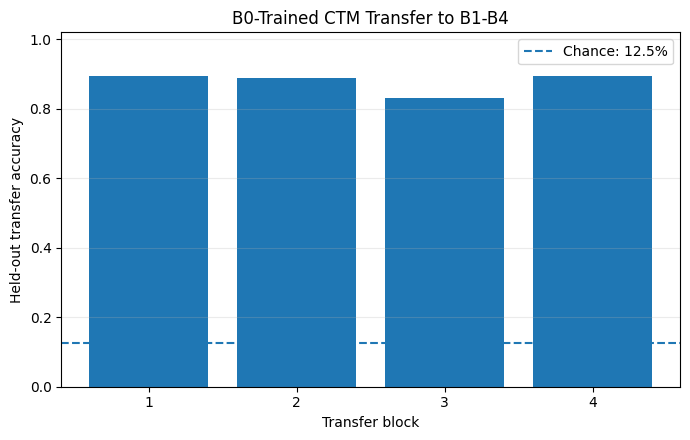

In [74]:
fig, ax = plt.subplots(
    figsize=(7, 4.5)
)

ax.bar(
    block_transfer_summary[
        "block"
    ].astype(str),
    block_transfer_summary[
        "mc_accuracy"
    ],
)

ax.axhline(
    0.125,
    linestyle="--",
    label="Chance: 12.5%",
)

ax.set_xlabel(
    "Transfer block"
)

ax.set_ylabel(
    "Held-out transfer accuracy"
)

ax.set_title(
    "B0-Trained CTM Transfer to B1-B4"
)

ax.set_ylim(
    0.0,
    1.02,
)

ax.grid(
    axis="y",
    alpha=0.25,
)

ax.legend()

plt.tight_layout()
plt.show()

### 15.2 B0 to B1-B4 transfer result

The CTM learns the harmonized B0 reach-to-grasp representation successfully.

Using B0 repetitions 0-5 for training and B0 repetitions 6-7 for validation, the selected checkpoint achieved:

- 99.2% training accuracy
- 98.75% held-out B0 validation accuracy

The same validation-selected model was then evaluated on all 640 B1-B4 recordings without further training.

Overall B1-B4 transfer performance was:

| Metric | Accuracy |
|---|---:|
| Most-certain-tick accuracy | 87.66% |
| Final-tick accuracy | 87.97% |

Transfer performance by block was:

| Block | Recordings | Accuracy |
|---:|---:|---:|
| B1 | 160 | 89.38% |
| B2 | 160 | 88.75% |
| B3 | 160 | 83.13% |
| B4 | 160 | 89.38% |

The CTM therefore retains substantial classification performance when moving from B0 to the B1-B4 transfer domain.

However, performance decreases from 98.75% on held-out B0 validation data to approximately 87.7% across B1-B4, indicating a meaningful transfer gap.

B3 shows the lowest transfer accuracy, while B1, B2, and B4 remain close to 89%.

This experiment follows the high-level structure of the original reach-to-grasp protocol, in which B0 is used for model fitting and B1-B4 are used for evaluation under changed object arrangements.

The transfer-specific representation uses one common reach-to-lift extraction rule across all blocks, reducing preprocessing differences between the source and target domains.

The remaining performance decrease should nevertheless be interpreted as a general cross-block distribution shift rather than being attributed solely to object location changes.

## 16. Experiment 8: Generalization to an Unseen Participant

The preceding experiments evaluate generalization across repetitions, temporal conditions, noise, and experimental blocks while all participants remain represented during model development.

The final RTG experiment asks whether the learned movement representation transfers to a person whose reach-to-grasp kinematics were never observed during training.

A leave-one-participant-out protocol is used on B1-B4.

For each fold, one of the five participants is completely excluded from model development.

For the remaining four participants:

- repetitions 0, 1, and 2 are used for training
- repetition 3 is used for validation and checkpoint selection

All B1-B4 recordings from the held-out participant are used as the final test set.

The held-out participant contributes no recordings to training, validation, checkpoint selection, or feature-standardization statistics.

A fresh CTM is trained for each of the five held-out participants.

This experiment therefore evaluates person-independent generalization while keeping the B1-B4 experimental conditions represented in the training domain.

In [79]:
import importlib
import rtg_experiment_runner

importlib.reload(
    rtg_experiment_runner
)

<module 'rtg_experiment_runner' from '/Users/arthu/Desktop/CTM_Res-Pro/models/ctm/rtg_experiment_runner.py'>

In [80]:
participant_results = (
    rtg_experiment_runner
    .run_unseen_participant_sweep(
        config=config,
        participants=(
            1,
            2,
            3,
            4,
            5,
        ),
        train_reps=(
            0,
            1,
            2,
        ),
        val_reps=(
            3,
        ),
        max_epochs=60,
        verbose=False,
    )
)

participant_results

/Users/arthu/miniconda3/envs/ctm_robotics/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:1317: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2) / (dx1 * (dx1 + dx2))
/Users/arthu/miniconda3/envs/ctm_robotics/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:1318: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/Users/arthu/miniconda3/envs/ctm_robotics/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:1319: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/Users/arthu/miniconda3/envs/ctm_robotics/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:1328: RuntimeWarning: invalid value encountered in multiply
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] \
/Users/arthu/miniconda3/envs/ctm_robotics/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:1328: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)]


Held-out participant: 1
train: 384 | val: 128 | test: 128
Device: mps
Using neuron select type: random-pairing
Synch representation size action: 32
Synch representation size out: 32
Prediction shape: (32, 8, 25)
Certainty shape: (32, 2, 25)
Trainable parameters: 328,970

Best checkpoint
epoch: 33
train MC accuracy: 0.995
validation MC accuracy: 0.969
validation final-tick accuracy: 0.969
validation mean MC tick: 24.95
saved to: results/rtg/20260927T002351Z_b1_b4_unseen_participant_1_seed0

Held-out test result:
MC accuracy: 0.984
final-tick accuracy: 0.984

Held-out participant: 2
train: 384 | val: 128 | test: 128
Device: mps
Using neuron select type: random-pairing
Synch representation size action: 32
Synch representation size out: 32
Prediction shape: (32, 8, 25)
Certainty shape: (32, 2, 25)
Trainable parameters: 328,970

Best checkpoint
epoch: 17
train MC accuracy: 0.997
validation MC accuracy: 0.992
validation final-tick accuracy: 0.984
validation mean MC tick: 24.88
saved to: res

,held_out_participant,n_train,n_val,n_test,best_epoch,train_accuracy_most_certain,val_accuracy_most_certain,test_accuracy_most_certain,test_accuracy_final_tick,test_loss,test_mean_most_certain_tick,test_mean_selected_certainty,checkpoint_dir
0,1,384,128,128,33,0.994792,0.968750,0.984375,0.984375,0.070027,24.937500,0.965351,results/rtg/20260927T002351Z_b1_b4_unseen_part...
1,2,384,128,128,17,0.997396,0.992188,0.718750,0.726562,1.491061,24.632812,0.951380,results/rtg/20260927T002430Z_b1_b4_unseen_part...
2,3,384,128,128,36,1.000000,0.992188,0.875000,0.875000,0.601365,24.476562,0.955656,results/rtg/20260927T002509Z_b1_b4_unseen_part...
3,4,384,128,128,16,0.981771,0.984375,0.492188,0.484375,2.956384,24.765625,0.915708,results/rtg/20260927T002548Z_b1_b4_unseen_part...
4,5,384,128,128,55,1.000000,0.968750,0.726562,0.750000,0.942230,24.523438,0.930485,results/rtg/20260927T002627Z_b1_b4_unseen_part...


In [81]:
participant_summary = pd.DataFrame(
    {
        "mean_test_accuracy": [
            participant_results[
                "test_accuracy_most_certain"
            ].mean()
        ],

        "std_test_accuracy": [
            participant_results[
                "test_accuracy_most_certain"
            ].std(
                ddof=1
            )
        ],

        "min_test_accuracy": [
            participant_results[
                "test_accuracy_most_certain"
            ].min()
        ],

        "max_test_accuracy": [
            participant_results[
                "test_accuracy_most_certain"
            ].max()
        ],
    }
)

participant_summary

,mean_test_accuracy,std_test_accuracy,min_test_accuracy,max_test_accuracy
0,0.759375,0.185816,0.492188,0.984375


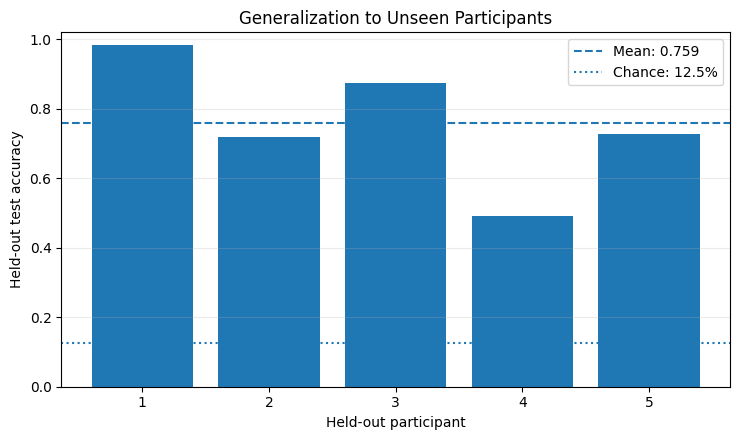

In [82]:
mean_accuracy = (
    participant_results[
        "test_accuracy_most_certain"
    ].mean()
)

fig, ax = plt.subplots(
    figsize=(7.5, 4.5)
)

ax.bar(
    participant_results[
        "held_out_participant"
    ].astype(str),
    participant_results[
        "test_accuracy_most_certain"
    ],
)

ax.axhline(
    mean_accuracy,
    linestyle="--",
    label=(
        f"Mean: "
        f"{mean_accuracy:.3f}"
    ),
)

ax.axhline(
    0.125,
    linestyle=":",
    label="Chance: 12.5%",
)

ax.set_xlabel(
    "Held-out participant"
)

ax.set_ylabel(
    "Held-out test accuracy"
)

ax.set_title(
    "Generalization to Unseen Participants"
)

ax.set_ylim(
    0.0,
    1.02,
)

ax.grid(
    axis="y",
    alpha=0.25,
)

ax.legend()

plt.tight_layout()
plt.show()

### 16.1 Unseen-participant generalization result

Leave-one-participant-out evaluation reveals substantially greater variability than the earlier held-out-repetition experiments.

Held-out test performance is:

| Held-out participant | Test accuracy |
|---:|---:|
| P1 | 98.44% |
| P2 | 71.88% |
| P3 | 87.50% |
| P4 | 49.22% |
| P5 | 72.66% |

Across the five participants:

$$
\mathrm{mean\ accuracy} = 75.94\%
$$

with a standard deviation of approximately:

$$
18.58
$$

percentage points.

All five source-domain validation accuracies remain high, ranging from approximately 96.9% to 99.2%.

The considerably larger variation therefore appears when the trained model is transferred to a participant whose movements were completely absent from model development.

For some participants, transfer is very strong. The model reaches 98.4% accuracy on P1 and 87.5% on P3.

For others, the transfer gap is substantially larger. P4 reaches only 49.2% accuracy despite high validation performance on the four participants used for model development.

The results therefore show that the CTM learns movement structure that transfers across people to a substantial degree, but this representation is not uniformly participant-invariant.

The mean accuracy alone should consequently be interpreted cautiously because it hides considerable participant-specific variability.

These results are descriptive rather than an estimate of population-level generalization. The dataset contains only five participants, and each leave-one-participant-out condition was trained using a single random seed.

An additional observation is that selected certainty remains relatively high even for participants with substantially reduced accuracy. This further indicates that CTM certainty should not automatically be interpreted as calibrated decision reliability under distribution shift.

> **Protocol update:** Following supervisor clarification, the primary RTG evaluation uses all successful B0 recordings for training and all B1-B4 recordings for testing. The earlier B0 train/validation split is retained as a development experiment and will not be used as the final transfer protocol.

## 17. Final B0 to B1-B4 Protocol

Following supervisor clarification, the primary RTG evaluation is defined using the original block-level partition:

- all successful B0 recordings are used for model training
- all B1-B4 recordings are used for transfer evaluation

No B0 recordings are reserved for validation in the final model.

The model-training duration is fixed before evaluating B1-B4.

The earlier B0 development experiment used 238 training recordings and selected epoch 19. This corresponds to approximately 152 optimizer updates.

Training on all 318 B0 recordings produces approximately 10 mini-batches per epoch. The final training duration is therefore fixed at 15 epochs, corresponding to approximately 150 optimizer updates.

This preserves approximately the same optimization budget while allowing every successful B0 recording to contribute to the final model.

The harmonized movement representation remains restricted to the reach-to-grasp interval ending at object lift, with no post-lift samples.

Feature standardization is fitted exclusively on B0.

In [99]:
import importlib
import rtg_experiment_runner

importlib.reload(
    rtg_experiment_runner
)

final_transfer_bundle = (
    rtg_experiment_runner
    .build_final_b0_transfer_bundle(
        config=config
    )
)

In [100]:
final_metadata = (
    final_transfer_bundle[
        "metadata"
    ]
)

print(
    final_metadata[
        "split"
    ].value_counts()
)

print()

print(
    pd.crosstab(
        final_metadata["split"],
        final_metadata[
            "class_label"
        ],
    )
)

split
test     640
train    318
Name: count, dtype: int64

class_label   0   1   2   3   4   5   6   7
split                                      
test         80  80  80  80  80  80  80  80
train        40  40  40  39  39  40  40  40


In [105]:
from dataclasses import replace

final_transfer_config = replace(
    config,
    experiment_name=(
        "final_all_b0_to_b1_b4"
    ),
)

final_transfer_run = (
    rtg_experiment_runner
    .run_fixed_epoch_rtg_training(
        bundle=(
            final_transfer_bundle
        ),
        config=(
            final_transfer_config
        ),
        epochs=15,
        verbose=True,
    )
)

Device: mps
Using neuron select type: random-pairing
Synch representation size action: 32
Synch representation size out: 32
Prediction shape: (32, 8, 25)
Certainty shape: (32, 2, 25)
Trainable parameters: 328,970
epoch 001 | train loss 2.0766 | train MC acc 0.126
epoch 002 | train loss 1.9623 | train MC acc 0.393
epoch 003 | train loss 1.6860 | train MC acc 0.481
epoch 004 | train loss 1.2816 | train MC acc 0.560
epoch 005 | train loss 0.9300 | train MC acc 0.585
epoch 006 | train loss 0.6363 | train MC acc 0.720
epoch 007 | train loss 0.4132 | train MC acc 0.840
epoch 008 | train loss 0.2331 | train MC acc 0.909
epoch 009 | train loss 0.1636 | train MC acc 0.937
epoch 010 | train loss 0.1330 | train MC acc 0.959
epoch 011 | train loss 0.1098 | train MC acc 0.972
epoch 012 | train loss 0.0886 | train MC acc 0.975
epoch 013 | train loss 0.0607 | train MC acc 0.981
epoch 014 | train loss 0.0355 | train MC acc 0.984
epoch 015 | train loss 0.0302 | train MC acc 0.987

Final fixed-budget tr

### 17.1 Final Transfer Evaluation

The final CTM was trained for the pre-specified 15-epoch optimization budget using all 318 successful B0 recordings.

The frozen model was then evaluated on all 640 B1-B4 recordings.

The final transfer performance was:

| Metric | Accuracy |
|---|---:|
| B0 training, most-certain tick | 99.06% |
| B1-B4 transfer, most-certain tick | 85.31% |
| B1-B4 transfer, final tick | 85.63% |

The B1-B4 recordings were not used for training or for choosing the training duration.

The following analyses examine whether transfer performance differs across experimental blocks and target objects.

In [107]:
# ============================================================
# Collect final B1-B4 transfer predictions
# ============================================================

final_test_outputs = (
    rtg_experiment_runner
    .collect_split_predictions(
        model=final_transfer_run[
            "model"
        ],
        loader=final_transfer_bundle[
            "test_loader"
        ],
        device=final_transfer_run[
            "device"
        ],
    )
)

print(
    "Logit shape:",
    final_test_outputs[
        "logits"
    ].shape,
)

print(
    "Number of targets:",
    len(
        final_test_outputs[
            "targets"
        ]
    ),
)

Logit shape: (640, 8, 25)
Number of targets: 640


In [108]:
# ============================================================
# Align predictions with final B1-B4 metadata
# ============================================================

final_test_metadata = (
    final_transfer_bundle[
        "metadata"
    ]
    .query(
        "split == 'test'"
    )
    .reset_index(
        drop=True
    )
    .copy()
)

assert (
    len(
        final_test_metadata
    )
    ==
    len(
        final_test_outputs[
            "targets"
        ]
    )
)

final_test_metadata[
    "target"
] = final_test_outputs[
    "targets"
]

final_test_metadata[
    "prediction"
] = final_test_outputs[
    "most_certain_prediction"
]

final_test_metadata[
    "correct"
] = (
    final_test_metadata[
        "target"
    ]
    ==
    final_test_metadata[
        "prediction"
    ]
)

print(
    "Overall transfer accuracy:",
    final_test_metadata[
        "correct"
    ].mean(),
)

Overall transfer accuracy: 0.853125


In [ ]:
# ============================================================
# Final transfer accuracy by block
# ============================================================

final_block_summary = (
    final_test_metadata
    .groupby(
        "block"
    )
    .agg(
        n=(
            "correct",
            "size",
        ),
        accuracy=(
            "correct",
            "mean",
        ),
    )
    .reset_index()
)

final_block_summary

,block,n,accuracy
0,1,160,0.8750
1,2,160,0.8625
2,3,160,0.8125
3,4,160,0.8625


In [110]:
# ============================================================
# Object-by-block transfer accuracy
# ============================================================

object_block_accuracy = (
    final_test_metadata
    .pivot_table(
        index="class_label",
        columns="block",
        values="correct",
        aggfunc="mean",
    )
)

object_block_accuracy

block,1,2,3,4
class_label,,,,
0,0.95,0.75,0.90,0.9
1,0.95,1.00,0.95,1.0
2,0.85,0.60,0.70,0.6
3,1.00,1.00,0.75,1.0
4,0.90,1.00,0.95,1.0
5,1.00,1.00,0.90,1.0
6,0.40,0.60,0.40,0.4
7,0.95,0.95,0.95,1.0


### 17.2 Final B0 to B1-B4 Transfer Results

The final CTM was trained using all 318 successful B0 recordings for the fixed 15-epoch optimization budget.

The resulting B0 training accuracy was:

$$
99.06\%
$$

The frozen model was then evaluated on all 640 B1-B4 recordings, producing:

$$
85.31\%
$$

most-certain-tick accuracy and:

$$
85.63\%
$$

final-tick accuracy.

Transfer performance by block was:

| Block | Recordings | Accuracy |
|---:|---:|---:|
| B1 | 160 | 87.50% |
| B2 | 160 | 86.25% |
| B3 | 160 | 81.25% |
| B4 | 160 | 86.25% |

The decrease in transfer performance is therefore not restricted to a single B1-B4 block, although B3 shows the lowest accuracy.

The object-level analysis reveals considerably stronger variation.

| Class | Accuracy |
|---:|---:|
| 0 | 87.50% |
| 1 | 97.50% |
| 2 | 68.75% |
| 3 | 93.75% |
| 4 | 96.25% |
| 5 | 97.50% |
| 6 | 45.00% |
| 7 | 96.25% |

Most target classes transfer with high accuracy, whereas classes 2 and especially 6 account for a substantial fraction of the transfer errors.

Class 6 remains difficult across all four transfer blocks, with block-specific accuracies between 40% and 60%. This suggests that the reduced B0-to-B1-B4 transfer performance is not simply caused by one unusually difficult block.

The result should be interpreted as performance under the B0-to-B1-B4 transfer conditions rather than as a difference from an independently evaluated B0 test set, since all successful B0 recordings are used for fitting the final model.

The final model and its training duration were fixed before the B1-B4 evaluation.

## 18. Anticipation with the Final B0-Trained CTM

The final B0-trained CTM is now kept frozen while the amount of B1-B4 movement evidence available to the model is varied.

The first analysis evaluates prediction as a function of normalized trajectory progression.

Each B1-B4 trajectory has already been resampled to 100 positions between the selected movement onset and object lift. Prefixes of this representation therefore provide an operational normalized progression from early movement toward lift.

Two complementary quantities are evaluated:

1. classification accuracy at each observation fraction
2. the earliest observation fraction from which the predicted target remains correct through the final observation

The second measure is motivated by the negative-latency definition used in the original RTG study, where an anticipation point is required to remain consistent through object lift.

This analysis uses the same frozen CTM trained on all B0 recordings. No additional training or checkpoint selection is performed on B1-B4.

In [111]:
# ============================================================
# Final-model anticipation across normalized movement
# ============================================================

from torch.utils.data import DataLoader, TensorDataset

full_test_X, full_test_y = (
    final_transfer_bundle[
        "test_loader"
    ].dataset.tensors
)

fraction_grid = np.arange(
    0.05,
    1.001,
    0.05,
)

fraction_records = []
fraction_predictions = []

for fraction in fraction_grid:

    n_observed = max(
        2,
        int(
            round(
                full_test_X.shape[-1]
                * fraction
            )
        ),
    )

    prefix_loader = DataLoader(
        TensorDataset(
            full_test_X[
                :,
                :,
                :n_observed,
            ],
            full_test_y,
        ),
        batch_size=config.batch_size,
        shuffle=False,
    )

    outputs = (
        rtg_experiment_runner
        .collect_split_predictions(
            model=final_transfer_run[
                "model"
            ],
            loader=prefix_loader,
            device=final_transfer_run[
                "device"
            ],
        )
    )

    targets = outputs[
        "targets"
    ]

    predictions = outputs[
        "most_certain_prediction"
    ]

    accuracy = (
        predictions
        == targets
    ).mean()

    fraction_records.append(
        {
            "fraction_observed":
                fraction,

            "n_positions":
                n_observed,

            "accuracy":
                accuracy,

            "mean_most_certain_tick":
                outputs[
                    "most_certain_tick"
                ].mean(),
        }
    )

    fraction_predictions.append(
        predictions
    )

fraction_summary = pd.DataFrame(
    fraction_records
)

fraction_summary

,fraction_observed,n_positions,accuracy,mean_most_certain_tick
0,0.05,5,0.295312,24.740625
1,0.10,10,0.329688,24.751562
2,0.15,15,0.357812,24.793750
3,0.20,20,0.393750,24.796875
4,0.25,25,0.423438,24.784375
5,0.30,30,0.468750,24.690625
6,0.35,35,0.500000,24.690625
7,0.40,40,0.517188,24.717188
8,0.45,45,0.554688,24.759375
9,0.50,50,0.576562,24.768750


In [112]:
assert np.isclose(
    fraction_summary.iloc[-1][
        "accuracy"
    ],
    0.853125,
)

print(
    "Full-trajectory reproduction passed."
)

Full-trajectory reproduction passed.


In [113]:
# ============================================================
# Earliest sustained-correct prediction
# ============================================================

prediction_matrix = np.stack(
    fraction_predictions,
    axis=1,
)

targets = (
    full_test_y
    .cpu()
    .numpy()
)

correct_matrix = (
    prediction_matrix
    ==
    targets[:, None]
)

sustained_correct = (
    np.zeros_like(
        correct_matrix,
        dtype=bool,
    )
)

sustained_correct[
    :,
    -1,
] = correct_matrix[
    :,
    -1,
]

for index in range(
    correct_matrix.shape[1] - 2,
    -1,
    -1,
):
    sustained_correct[
        :,
        index,
    ] = (
        correct_matrix[
            :,
            index,
        ]
        &
        sustained_correct[
            :,
            index + 1,
        ]
    )

has_sustained_prediction = (
    sustained_correct.any(
        axis=1
    )
)

first_sustained_index = np.full(
    len(targets),
    -1,
    dtype=int,
)

first_sustained_index[
    has_sustained_prediction
] = (
    sustained_correct[
        has_sustained_prediction
    ]
    .argmax(
        axis=1
    )
)

first_sustained_fraction = np.full(
    len(targets),
    np.nan,
    dtype=float,
)

first_sustained_fraction[
    has_sustained_prediction
] = fraction_grid[
    first_sustained_index[
        has_sustained_prediction
    ]
]

print(
    "Trials with a sustained correct prediction:",
    has_sustained_prediction.mean(),
)

print(
    "Median first sustained fraction:",
    np.nanmedian(
        first_sustained_fraction
    ),
)

print(
    "Mean first sustained fraction:",
    np.nanmean(
        first_sustained_fraction
    ),
)

Trials with a sustained correct prediction: 0.853125
Median first sustained fraction: 0.30000000000000004
Mean first sustained fraction: 0.36968864468864465


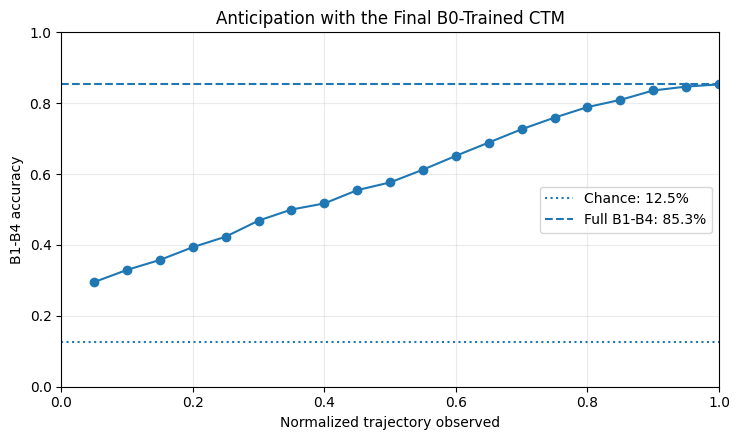

In [114]:
fig, ax = plt.subplots(
    figsize=(7.5, 4.5)
)

ax.plot(
    fraction_summary[
        "fraction_observed"
    ],
    fraction_summary[
        "accuracy"
    ],
    marker="o",
)

ax.axhline(
    0.125,
    linestyle=":",
    label="Chance: 12.5%",
)

ax.axhline(
    0.853125,
    linestyle="--",
    label="Full B1-B4: 85.3%",
)

ax.set_xlabel(
    "Normalized trajectory observed"
)

ax.set_ylabel(
    "B1-B4 accuracy"
)

ax.set_title(
    "Anticipation with the Final B0-Trained CTM"
)

ax.set_xlim(
    0.0,
    1.0,
)

ax.set_ylim(
    0.0,
    1.0,
)

ax.grid(
    alpha=0.25,
)

ax.legend()

plt.tight_layout()
plt.show()

### 18.1 Anticipation by Normalized Movement Progression

The frozen B0-trained CTM was evaluated using progressively larger fractions of the B1-B4 reach-to-grasp trajectory.

Accuracy increases steadily as more movement information becomes available:

| Fraction observed | Accuracy |
|---:|---:|
| 5% | 29.5% |
| 10% | 33.0% |
| 25% | 42.3% |
| 50% | 57.7% |
| 75% | 75.9% |
| 90% | 83.6% |
| 100% | 85.3% |

The full-trajectory result exactly reproduces the primary B0-to-B1-B4 transfer accuracy of 85.31%.

The model therefore contains target-related information substantially before object lift, but prediction reliability increases progressively as the reach-to-grasp movement unfolds.

To approximate a sustained anticipation criterion, the earliest observation fraction was identified from which the predicted class remained correct for every later evaluated fraction up to the full trajectory.

A sustained correct prediction was found for 85.31% of trials, corresponding to the trials that were correctly classified at the full trajectory.

Among these trials:

$$
\mathrm{median\ first\ sustained\ fraction} = 0.30
$$

and:

$$
\mathrm{mean\ first\ sustained\ fraction} \approx 0.37.
$$

Thus, among ultimately correct trials, many predictions become stable relatively early in the normalized movement trajectory.

This sustained criterion is evaluated on a discrete 5%-spaced observation grid and should therefore be interpreted as an approximation of the continuous negative-latency definition used in the original RTG study, rather than as an exact latency measurement.

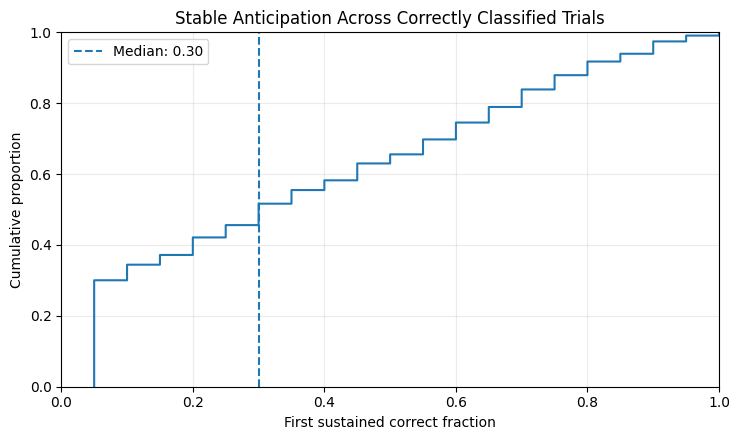

In [115]:
# ============================================================
# Distribution of first sustained correct prediction
# ============================================================

valid_sustained_fraction = (
    first_sustained_fraction[
        np.isfinite(
            first_sustained_fraction
        )
    ]
)

sorted_fraction = np.sort(
    valid_sustained_fraction
)

cumulative = (
    np.arange(
        1,
        len(sorted_fraction) + 1,
    )
    / len(sorted_fraction)
)

fig, ax = plt.subplots(
    figsize=(7.5, 4.5)
)

ax.step(
    sorted_fraction,
    cumulative,
    where="post",
)

ax.axvline(
    np.median(
        valid_sustained_fraction
    ),
    linestyle="--",
    label=(
        "Median: "
        f"{np.median(valid_sustained_fraction):.2f}"
    ),
)

ax.set_xlabel(
    "First sustained correct fraction"
)

ax.set_ylabel(
    "Cumulative proportion"
)

ax.set_title(
    "Stable Anticipation Across Correctly Classified Trials"
)

ax.set_xlim(
    0.0,
    1.0,
)

ax.set_ylim(
    0.0,
    1.0,
)

ax.grid(
    alpha=0.25,
)

ax.legend()

plt.tight_layout()
plt.show()

In [125]:
import importlib
import rtg_experiment_runner

importlib.reload(
    rtg_experiment_runner
)

<module 'rtg_experiment_runner' from '/Users/arthu/Desktop/CTM_Res-Pro/models/ctm/rtg_experiment_runner.py'>

In [121]:
# ============================================================
# Audit physical onset-to-lift durations
# ============================================================

physical_duration_df = (
    rtg_experiment_runner
    .audit_b1_b4_physical_durations(
        metadata=(
            final_transfer_bundle[
                "metadata"
            ]
        )
    )
)

physical_duration_df[
    "duration_ms"
].describe(
    percentiles=[
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
    ]
)

count     640.000000
mean      943.223438
std       321.887997
min        15.000000
5%        515.400000
10%       630.800000
25%       784.750000
50%       929.500000
75%      1097.250000
90%      1239.200000
95%      1397.400000
max      4017.000000
Name: duration_ms, dtype: float64

In [122]:
physical_duration_df[
    "median_sample_step_ms"
].describe()

count    640.0
mean      16.0
std        0.0
min       16.0
25%       16.0
50%       16.0
75%       16.0
max       16.0
Name: median_sample_step_ms, dtype: float64

In [123]:
(
    physical_duration_df
    .groupby(
        "block"
    )[
        "duration_ms"
    ]
    .agg(
        [
            "count",
            "mean",
            "median",
            "min",
            "max",
        ]
    )
)

,count,mean,median,min,max
block,,,,,
1,160,962.71250,964.0,284.0,1682.0
2,160,898.75625,916.5,15.0,1904.0
3,160,991.88750,946.0,394.0,4017.0
4,160,919.53750,912.0,47.0,2177.0


### 18.2 Anticipation in Physical Time Before Object Lift

Normalized movement progression does not directly express how much real time remains before interaction with the object.

The second anticipation analysis therefore returns to the original glove timestamps.

For each B1-B4 recording, the detected object-lift time is identified using the same movement boundary used by the final transfer representation. The trajectory is then truncated at fixed physical lead times before lift.

The primary evaluation uses:

- 500 ms before lift
- 400 ms before lift
- 300 ms before lift
- 200 ms before lift
- 100 ms before lift
- object lift itself

Only samples physically available by the requested cutoff are retained. The resulting raw prefix is then resampled to the fixed 100-position CTM input representation and standardized using the scaler fitted exclusively on B0.

The CTM remains frozen throughout this analysis.

Trials for which fewer than two glove observations are available at a requested cutoff are excluded from that condition and the number of valid trials is reported explicitly.

For comparison with the original RTG negative-latency convention, a lead time of 500 ms before lift corresponds to a latency of:

$$
-500\ \mathrm{ms},
$$

while object lift corresponds to:

$$
0\ \mathrm{ms}.
$$

This analysis measures classification using observations available at a known physical time before lift. It does not yet define an online stopping rule for deciding when the model should commit to a prediction.

In [126]:
# ============================================================
# Physical-time pipeline sanity check at object lift
# ============================================================

zero_lead_result = (
    rtg_experiment_runner
    .evaluate_physical_time_cutoffs(
        model=final_transfer_run[
            "model"
        ],
        device=final_transfer_run[
            "device"
        ],
        bundle=final_transfer_bundle,
        config=config,
        lead_times_ms=[
            0,
        ],
    )
)

zero_lead_result[
    "summary"
]

,lead_time_ms,n_valid,n_excluded,accuracy,mean_actual_lead_ms,mean_raw_fraction_available,mean_most_certain_tick
0,0.0,640,0,0.853125,0.0,1.0,24.8


In [127]:
# ============================================================
# Physical-time anticipation sweep
# ============================================================

physical_lead_times_ms = [
    500,
    400,
    300,
    200,
    100,
    0,
]

physical_time_result = (
    rtg_experiment_runner
    .evaluate_physical_time_cutoffs(
        model=final_transfer_run[
            "model"
        ],
        device=final_transfer_run[
            "device"
        ],
        bundle=final_transfer_bundle,
        config=config,
        lead_times_ms=(
            physical_lead_times_ms
        ),
    )
)

physical_time_summary = (
    physical_time_result[
        "summary"
    ]
)

physical_time_summary

,lead_time_ms,n_valid,n_excluded,accuracy,mean_actual_lead_ms,mean_raw_fraction_available,mean_most_certain_tick
0,500.0,608,32,0.532895,505.268092,0.459456,24.745066
1,400.0,615,25,0.621138,408.902439,0.557718,24.798374
2,300.0,626,14,0.698083,308.091054,0.658391,24.782748
3,200.0,629,11,0.779014,204.674086,0.771065,24.820350
4,100.0,629,11,0.829889,110.327504,0.876805,24.756757
5,0.0,640,0,0.853125,0.000000,1.000000,24.800000


In [128]:
physical_time_summary[
    "latency_ms"
] = -physical_time_summary[
    "lead_time_ms"
]

physical_time_summary[
    [
        "latency_ms",
        "lead_time_ms",
        "n_valid",
        "n_excluded",
        "accuracy",
        "mean_actual_lead_ms",
        "mean_raw_fraction_available",
    ]
]

,latency_ms,lead_time_ms,n_valid,n_excluded,accuracy,mean_actual_lead_ms,mean_raw_fraction_available
0,-500.0,500.0,608,32,0.532895,505.268092,0.459456
1,-400.0,400.0,615,25,0.621138,408.902439,0.557718
2,-300.0,300.0,626,14,0.698083,308.091054,0.658391
3,-200.0,200.0,629,11,0.779014,204.674086,0.771065
4,-100.0,100.0,629,11,0.829889,110.327504,0.876805
5,-0.0,0.0,640,0,0.853125,0.000000,1.000000


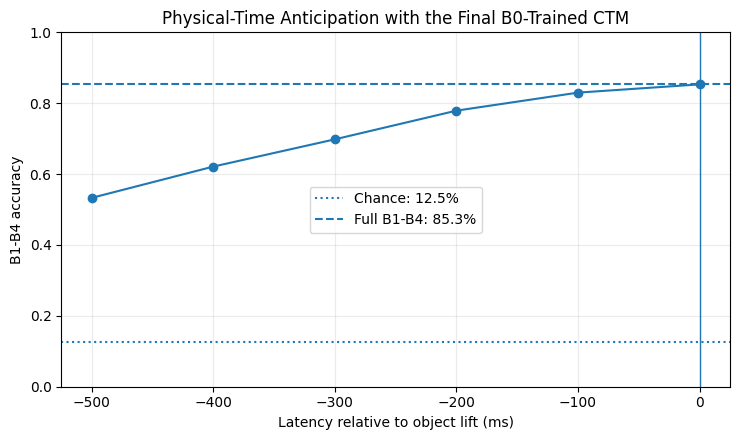

In [129]:
# ============================================================
# Accuracy as a function of physical time before lift
# ============================================================

plot_df = (
    physical_time_summary
    .sort_values(
        "latency_ms"
    )
)

fig, ax = plt.subplots(
    figsize=(7.5, 4.5)
)

ax.plot(
    plot_df[
        "latency_ms"
    ],
    plot_df[
        "accuracy"
    ],
    marker="o",
)

ax.axhline(
    0.125,
    linestyle=":",
    label="Chance: 12.5%",
)

ax.axhline(
    0.853125,
    linestyle="--",
    label="Full B1-B4: 85.3%",
)

ax.axvline(
    0,
    linewidth=1,
)

ax.set_xlabel(
    "Latency relative to object lift (ms)"
)

ax.set_ylabel(
    "B1-B4 accuracy"
)

ax.set_title(
    "Physical-Time Anticipation with the Final B0-Trained CTM"
)

ax.set_ylim(
    0.0,
    1.0,
)

ax.grid(
    alpha=0.25,
)

ax.legend()

plt.tight_layout()
plt.show()

In [134]:
physical_time_result[
    "metadata_by_lead"
]

{500.0:      participant  block  class_label  trial_number  rep_number  \
 0              1      1            0             0           0   
 1              1      1            0             0           1   
 2              1      1            0             0           2   
 3              1      1            0             0           3   
 4              1      1            1             1           0   
 ..           ...    ...          ...           ...         ...   
 603            5      4            2             6           3   
 604            5      4            3             7           0   
 605            5      4            3             7           1   
 606            5      4            3             7           2   
 607            5      4            3             7           3   
 
                             file  lead_time_ms  actual_lead_ms  \
 0    B1_trial0_rep0_attempt0.csv         500.0           506.0   
 1    B1_trial0_rep1_attempt0.csv         500.0      

In [135]:
# ============================================================
# Common cohort for physical-time comparison
# ============================================================

cohort_500 = (
    physical_time_result[
        "metadata_by_lead"
    ][500.0]
    .copy()
)

cohort_500[
    "recording_key"
] = list(
    zip(
        cohort_500[
            "participant"
        ],
        cohort_500[
            "file"
        ],
    )
)

common_recordings = set(
    cohort_500[
        "recording_key"
    ]
)

print(
    "Common cohort size:",
    len(
        common_recordings
    ),
)

Common cohort size: 608


In [136]:
# ============================================================
# Physical-time accuracy on a fixed common cohort
# ============================================================

common_cohort_records = []

for lead_time_ms in (
    physical_lead_times_ms
):

    df = (
        physical_time_result[
            "metadata_by_lead"
        ][
            float(
                lead_time_ms
            )
        ]
        .copy()
    )

    df[
        "recording_key"
    ] = list(
        zip(
            df[
                "participant"
            ],
            df[
                "file"
            ],
        )
    )

    df = df[
        df[
            "recording_key"
        ].isin(
            common_recordings
        )
    ]

    assert len(
        df
    ) == 608

    common_cohort_records.append(
        {
            "lead_time_ms":
                lead_time_ms,

            "latency_ms":
                -lead_time_ms,

            "n":
                len(
                    df
                ),

            "accuracy":
                df[
                    "correct"
                ].mean(),

            "mean_raw_fraction_available":
                df[
                    "raw_fraction_available"
                ].mean(),
        }
    )

common_cohort_summary = (
    pd.DataFrame(
        common_cohort_records
    )
)

common_cohort_summary

,lead_time_ms,latency_ms,n,accuracy,mean_raw_fraction_available
0,500,-500,608,0.532895,0.459456
1,400,-400,608,0.620066,0.562651
2,300,-300,608,0.695724,0.670439
3,200,-200,608,0.777961,0.781321
4,100,-100,608,0.828947,0.882330
5,0,0,608,0.850329,1.000000


### 18.2.1 Physical-Time Anticipation Results

The frozen B0-trained CTM shows progressively increasing target recognition as object lift approaches.

Using all trials that support each physical cutoff:

| Time before lift | Valid trials | Accuracy |
|---:|---:|---:|
| 500 ms | 608 | 53.29% |
| 400 ms | 615 | 62.11% |
| 300 ms | 626 | 69.81% |
| 200 ms | 629 | 77.90% |
| 100 ms | 629 | 82.99% |
| 0 ms | 640 | 85.31% |

The actual last observed sample occurs slightly earlier than the nominal cutoff because glove samples are separated by approximately 16 ms. The implementation always selects the last sample available at or before the requested cutoff and therefore does not use future observations.

For example, the mean actual lead times are approximately:

- 505 ms for a requested 500 ms cutoff
- 309 ms for a requested 300 ms cutoff
- 110 ms for a requested 100 ms cutoff

A fixed-cohort analysis was also performed using the 608 trials that are valid at the earliest 500 ms cutoff.

This produced:

| Time before lift | Accuracy |
|---:|---:|
| 500 ms | 53.29% |
| 400 ms | 62.01% |
| 300 ms | 69.57% |
| 200 ms | 77.80% |
| 100 ms | 82.89% |
| 0 ms | 85.03% |

The fixed-cohort results are nearly identical to the variable-cohort results. The increasing accuracy toward object lift is therefore not explained by changes in the evaluated trial population.

Approximately 46% of the movement is available on average at 500 ms before lift, 67% at 300 ms, and 88% at 100 ms.

The physical-time results therefore closely agree with the normalized movement-progression analysis.

The model already performs substantially above chance 500 ms before lift, and most of its final classification performance is available by approximately 100 ms before lift.

This experiment measures classification using observations available at known physical times before lift. It does not define an online stopping rule and should not be interpreted as an exact reproduction of the continuous negative-latency procedure used in the original RTG study.

In [137]:
# ============================================================
# Physical-time anticipation by target object
# ============================================================

object_latency_records = []

for lead_time_ms in (
    physical_lead_times_ms
):

    df = (
        physical_time_result[
            "metadata_by_lead"
        ][
            float(
                lead_time_ms
            )
        ]
        .copy()
    )

    grouped = (
        df
        .groupby(
            "class_label"
        )[
            "correct"
        ]
        .agg(
            [
                "count",
                "mean",
            ]
        )
        .reset_index()
    )

    for _, row in (
        grouped
        .iterrows()
    ):

        object_latency_records.append(
            {
                "class_label":
                    int(
                        row[
                            "class_label"
                        ]
                    ),

                "lead_time_ms":
                    int(
                        lead_time_ms
                    ),

                "latency_ms":
                    -int(
                        lead_time_ms
                    ),

                "n":
                    int(
                        row[
                            "count"
                        ]
                    ),

                "accuracy":
                    float(
                        row[
                            "mean"
                        ]
                    ),
            }
        )

object_latency_df = pd.DataFrame(
    object_latency_records
)

object_latency_table = (
    object_latency_df
    .pivot(
        index="class_label",
        columns="latency_ms",
        values="accuracy",
    )
    .sort_index(
        axis=1
    )
)

object_latency_table

latency_ms,-500,-400,-300,-200,-100,0
class_label,,,,,,
0,0.544304,0.762500,0.775000,0.800000,0.800000,0.8750
1,0.675000,0.712500,0.725000,0.812500,0.950000,0.9750
2,0.513158,0.602564,0.612500,0.637500,0.675000,0.6875
3,0.600000,0.684211,0.810127,0.862500,0.912500,0.9375
4,0.164179,0.304348,0.579710,0.845070,0.957746,0.9625
5,0.481013,0.550000,0.687500,0.862500,0.925000,0.9750
6,0.329114,0.392405,0.430380,0.468354,0.468354,0.4500
7,0.931507,0.945205,0.949367,0.949367,0.962025,0.9625


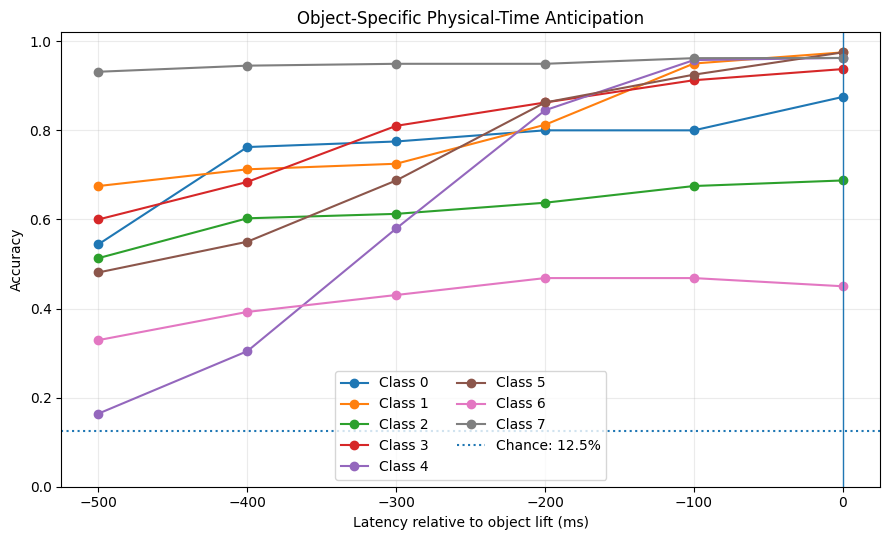

In [138]:
# ============================================================
# Physical-time anticipation by target object
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

for class_label in sorted(
    object_latency_df[
        "class_label"
    ].unique()
):

    class_df = (
        object_latency_df[
            object_latency_df[
                "class_label"
            ]
            == class_label
        ]
        .sort_values(
            "latency_ms"
        )
    )

    ax.plot(
        class_df[
            "latency_ms"
        ],
        class_df[
            "accuracy"
        ],
        marker="o",
        label=(
            f"Class {class_label}"
        ),
    )

ax.axhline(
    0.125,
    linestyle=":",
    label="Chance: 12.5%",
)

ax.axvline(
    0,
    linewidth=1,
)

ax.set_xlabel(
    "Latency relative to object lift (ms)"
)

ax.set_ylabel(
    "Accuracy"
)

ax.set_title(
    "Object-Specific Physical-Time Anticipation"
)

ax.set_ylim(
    0.0,
    1.02,
)

ax.grid(
    alpha=0.25,
)

ax.legend(
    ncol=2,
)

plt.tight_layout()
plt.show()

### 18.3 Object-Specific Anticipation

Physical-time anticipation differs substantially across target classes.

Some classes are already highly discriminable several hundred milliseconds before object lift, whereas others require later movement information or remain difficult even at the full trajectory.

Class 7 shows the strongest early performance, reaching approximately 93% accuracy at 500 ms before lift and remaining above 94% throughout the evaluated interval.

Classes 3 and 5 also show strong anticipation, reaching more than 80% accuracy by approximately 300 ms and 200 ms before lift, respectively.

Class 4 follows a markedly different trajectory. Accuracy is only approximately 16% at 500 ms before lift, but rises rapidly as the movement progresses, reaching approximately 96% at object lift. This suggests that the class-specific kinematic information used by the CTM becomes substantially more discriminative later in the movement.

Classes 2 and 6 remain comparatively difficult. Class 6 in particular stays below 50% accuracy throughout the evaluated interval and reaches only 45% at object lift.

This indicates that the overall anticipation curve reflects at least two distinct effects:

1. temporal emergence of discriminative movement information
2. class-specific transferability from B0 to the B1-B4 conditions

The object-specific results are therefore useful for interpreting both early prediction and the transfer errors observed in the final B0-to-B1-B4 experiment.

# 19. RTG-CTM Experimental Summary

The reach-to-grasp experiments establish a final evaluation protocol in which the CTM is trained using all successful B0 recordings and evaluated on B1-B4.

This follows the high-level structure of the original RTG experiment, where B0 provides the fitting data and B1-B4 evaluate generalization across changed object arrangements.

For the CTM experiments, movement input is restricted to the reach-to-grasp interval ending at detected object lift. No post-lift samples are used.

### 19.1 Primary B0 to B1-B4 transfer result

The final CTM was trained on all 318 successful B0 recordings for a fixed 15-epoch optimization budget.

The B1-B4 recordings were not used for model fitting or for selecting the training duration.

The final model achieved:

| Evaluation | Accuracy |
|---|---:|
| B0 training, most-certain tick | 99.06% |
| B1-B4 transfer, most-certain tick | 85.31% |
| B1-B4 transfer, final tick | 85.63% |

Transfer performance was broadly similar across B1-B4:

| Block | Accuracy |
|---:|---:|
| B1 | 87.50% |
| B2 | 86.25% |
| B3 | 81.25% |
| B4 | 86.25% |

The transfer errors are not distributed uniformly across target classes.

Most classes retain high transfer accuracy, whereas classes 2 and particularly 6 are substantially more difficult.

Class 6 reaches only 45% accuracy at the complete trajectory and remains difficult in every B1-B4 block.

The primary conclusion is therefore that a CTM fitted on B0 transfers substantially to the B1-B4 conditions, but transferability is strongly target-dependent.

### 19.2 Anticipation from normalized movement progression

The frozen final CTM was evaluated using progressively larger fractions of the B1-B4 movement trajectory.

Accuracy increased monotonically as more of the movement became available:

| Movement observed | Accuracy |
|---:|---:|
| 5% | 29.5% |
| 10% | 33.0% |
| 25% | 42.3% |
| 50% | 57.7% |
| 75% | 75.9% |
| 90% | 83.6% |
| 100% | 85.3% |

The full-trajectory condition exactly reproduces the final B0-to-B1-B4 transfer result.

A sustained-correct criterion was also evaluated over the 5%-spaced observation grid.

Among trials that were ultimately classified correctly:

$$
\mathrm{median\ first\ sustained\ fraction} = 0.30
$$

and:

$$
\mathrm{mean\ first\ sustained\ fraction} \approx 0.37.
$$

This indicates that for many successfully classified trials, the predicted target becomes stable well before movement completion.

### 19.3 Anticipation in physical time

Physical-time anticipation was evaluated directly from the original glove timestamps.

For every requested cutoff, only observations physically available before that time were retained before resampling and classification.

The resulting performance was:

| Time before object lift | Accuracy |
|---:|---:|
| 500 ms | 53.29% |
| 400 ms | 62.11% |
| 300 ms | 69.81% |
| 200 ms | 77.90% |
| 100 ms | 82.99% |
| 0 ms | 85.31% |

The glove sampling interval is approximately 16 ms, so the actual final observation lies slightly earlier than the requested cutoff.

A fixed-cohort analysis using the same 608 recordings at every lead time produced nearly identical results:

| Time before object lift | Fixed-cohort accuracy |
|---:|---:|
| 500 ms | 53.29% |
| 400 ms | 62.01% |
| 300 ms | 69.57% |
| 200 ms | 77.80% |
| 100 ms | 82.89% |
| 0 ms | 85.03% |

The temporal increase in classification performance is therefore not explained by different trials entering the evaluation at later cutoffs.

The physical-time and normalized-progression analyses closely agree.

Approximately half of the final movement information is available 500 ms before lift, where the model already reaches approximately 53% accuracy.

By 100 ms before lift, the model reaches approximately 83% accuracy, close to its 85.3% performance at object lift.

### 19.4 Object-specific anticipation

Anticipation varies substantially across target classes.

Some classes are highly discriminable very early in the movement, while others develop a recognizable kinematic signature only later.

Class 7 already exceeds 93% accuracy at 500 ms before lift.

Class 4 shows a particularly strong temporal progression:

$$
16.4\%
\rightarrow
30.4\%
\rightarrow
58.0\%
\rightarrow
84.5\%
\rightarrow
95.8\%
\rightarrow
96.3\%
$$

from 500 ms before lift to object lift.

In contrast, class 6 remains difficult throughout the entire trajectory and reaches only 45% accuracy at object lift.

This suggests that two related but distinct factors contribute to the results:

1. the time at which discriminative movement information becomes available
2. the extent to which the B0-trained representation transfers to a particular target under B1-B4 conditions

### 19.5 Supporting experiments

Several additional experiments were performed before the final supervisor-aligned protocol was fixed.

These experiments remain useful for understanding the behavior of the CTM, but they are treated as supporting analyses rather than the primary evaluation.

#### Held-out repetitions

Using B1-B4 repetition 0-1 for training, repetition 2 for validation, and repetition 3 for testing, the CTM reached:

$$
96.25\%
$$

test accuracy.

This established that the model can learn the RTG classification task reliably when participants and experimental blocks are represented during training.

#### Matched partial-observation training

When separate models were trained specifically on partial movement prefixes, classification was substantially stronger than when a full-trajectory model was simply evaluated on truncated inputs.

For example:

| Movement observed | Frozen full-trained model | Matched partial model |
|---:|---:|---:|
| 10% | 34.4% | 71.3% |
| 25% | 49.4% | 84.4% |
| 50% | 73.8% | 89.4% |
| 75% | 90.0% | 95.0% |

This shows that substantial target information exists early in the reach, even when the full-trajectory CTM does not make optimal use of it.

#### Temporal position

For equal 25%-length movement windows:

| Window | Accuracy |
|---|---:|
| Beginning | 84.4% |
| Middle | 93.8% |
| End | 96.9% |

Later movement segments therefore contain more discriminative target information than the beginning of the reach.

#### Internal computation budget

Changing the CTM internal computation budget between 5 and 25 ticks produced only small differences in full-trajectory accuracy.

The same was true when only the first 10% of external movement evidence was available.

Increasing internal computation did not compensate for missing external movement information.

#### Correlated-noise robustness

The full-trajectory CTM remained accurate under small Wiener-process perturbations but degraded progressively under stronger temporally correlated noise.

Model certainty decreased more slowly than accuracy, indicating that high CTM certainty should not automatically be interpreted as calibrated reliability under substantial distribution shift.

#### Unseen participants

Leave-one-participant-out evaluation produced:

$$
75.94\% \pm 18.58
$$

percentage points across the five held-out participants.

Performance ranged from approximately 49% to 98%, revealing substantial variability in person-independent transfer.

This result is retained as an exploratory observation rather than part of the primary B0-to-B1-B4 protocol.

### 19.6 Main conclusions

The RTG experiments lead to several consistent findings.

First, the CTM successfully learns target-specific reach-to-grasp kinematics and transfers substantially from B0 to B1-B4.

Second, target information is available before object lift and becomes progressively more discriminative as the movement unfolds.

Third, anticipation can be expressed consistently both as normalized movement progression and as physical time before object lift.

Fourth, object identity strongly influences both final transfer performance and the time at which reliable prediction becomes possible.

Fifth, additional internal CTM computation does not by itself compensate for missing external sensory evidence.

Finally, the model can become highly confident even when performance deteriorates under distribution shift, motivating a closer examination of how evidence and certainty evolve internally.

These findings motivate the next stage of the project: analysis of the CTM's internal temporal dynamics during individual decisions.

Rather than asking only whether increasing the number of internal ticks improves classification, the next analysis will examine how target evidence evolves across the internal ticks of a fixed trained CTM.

Relevant quantities include:

- target-class logit
- strongest competing-class logit
- target-versus-competitor margin
- prediction stability
- certainty
- threshold-crossing time

These internal trajectories provide the bridge from the behavioral RTG experiments to drift-diffusion-style analysis of decision formation.

## 20. Supervisor-Requested RTG Follow-Up

Following supervisor feedback, the remaining RTG experiments focus on:

1. reporting pooled-model performance separately for each participant
2. evaluating physical-time anticipation without stretching every partial trajectory to 100 positions
3. training participant-specific CTMs using B0 from one participant and testing that participant on B1-B4
4. comparing pooled and participant-specific models under identical evaluation conditions

The existing pooled B0-to-B1-B4 model is preserved unchanged.

Before adding new experiments, its saved checkpoint, scaler, configuration, recording identities, and predictions are audited to ensure that all subsequent comparisons use the exact established model and data split.

In [1]:
# ============================================================
# Stage 1: final pooled-model artifact audit
# ============================================================

from pathlib import Path
from dataclasses import asdict, replace
from datetime import datetime, timezone
import json
import math

import numpy as np
import pandas as pd
import torch

import importlib
import rtg_experiment_runner

importlib.reload(
    rtg_experiment_runner
)

from rtg_experiment_runner import (
    RTGExperimentConfig,
)

from experiment_runner import (
    build_model,
    resolve_device,
)


POOL_RUN_DIR = Path(
    "results/rtg/"
    "20260927T130855Z_final_all_b0_to_b1_b4_seed0"
)

assert POOL_RUN_DIR.exists(), (
    f"Run directory not found: {POOL_RUN_DIR.resolve()}"
)

print(
    "Pooled run:",
    POOL_RUN_DIR.resolve(),
)

print("\nSaved files:")

for path in sorted(
    POOL_RUN_DIR.iterdir()
):
    print(
        " ",
        path.name,
    )

Pooled run: /Users/arthu/Desktop/CTM_Res-Pro/models/ctm/results/rtg/20260927T130855Z_final_all_b0_to_b1_b4_seed0

Saved files:
  checkpoint.pt
  scaler.npz
  split_metadata.csv
  training_history.csv


/Users/arthu/miniconda3/envs/ctm_robotics/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================================================
# Inspect checkpoint and saved metadata
# ============================================================

checkpoint_candidates = [
    POOL_RUN_DIR
    / "checkpoint.pt",

    POOL_RUN_DIR
    / "best_checkpoint.pt",
]

checkpoint_path = next(
    (
        path
        for path
        in checkpoint_candidates
        if path.exists()
    ),
    None,
)

assert checkpoint_path is not None, (
    "No checkpoint found."
)

checkpoint = torch.load(
    checkpoint_path,
    map_location="cpu",
    weights_only=False,
)

print(
    "Checkpoint:",
    checkpoint_path.name,
)

print(
    "Checkpoint keys:",
    sorted(
        checkpoint.keys()
    ),
)


scaler_path = (
    POOL_RUN_DIR
    / "scaler.npz"
)

metadata_path = (
    POOL_RUN_DIR
    / "split_metadata.csv"
)

history_path = (
    POOL_RUN_DIR
    / "training_history.csv"
)

assert scaler_path.exists()
assert metadata_path.exists()
assert history_path.exists()


saved_scaler_npz = np.load(
    scaler_path
)

saved_scaler = {
    "mean":
        saved_scaler_npz[
            "mean"
        ],

    "std":
        saved_scaler_npz[
            "std"
        ],
}

saved_metadata = pd.read_csv(
    metadata_path
)

saved_history = pd.read_csv(
    history_path
)


print(
    "\nMetadata split counts:"
)

print(
    saved_metadata[
        "split"
    ].value_counts()
)

print(
    "\nTraining epochs saved:",
    len(
        saved_history
    ),
)

print(
    "\nScaler shapes:",
    saved_scaler[
        "mean"
    ].shape,
    saved_scaler[
        "std"
    ].shape,
)

Checkpoint: checkpoint.pt
Checkpoint keys: ['epochs', 'model_state_dict', 'parameter_count', 'run_seed']

Metadata split counts:
split
test     640
train    318
Name: count, dtype: int64

Training epochs saved: 15

Scaler shapes: (1, 15, 1) (1, 15, 1)


In [3]:
# ============================================================
# Recover exact configuration source
# ============================================================

config_json_path = (
    POOL_RUN_DIR
    / "config.json"
)

if config_json_path.exists():

    with config_json_path.open(
        "r",
        encoding="utf-8",
    ) as f:
        config_dict = json.load(
            f
        )

    pooled_config = (
        RTGExperimentConfig(
            **config_dict
        )
    )

    config_source = (
        "saved config.json"
    )

elif (
    "config"
    in checkpoint
):

    pooled_config = (
        RTGExperimentConfig(
            **checkpoint[
                "config"
            ]
        )
    )

    config_source = (
        "checkpoint config"
    )

else:

    pooled_config = replace(
        RTGExperimentConfig(),
        experiment_name=(
            "final_all_b0_to_b1_b4"
        ),
    )

    config_source = (
        "reconstructed from current "
        "RTGExperimentConfig + final protocol"
    )


print(
    "Configuration source:",
    config_source,
)

print(
    "\nConfiguration:"
)

print(
    asdict(
        pooled_config
    )
)

Configuration source: reconstructed from current RTGExperimentConfig + final protocol

Configuration:
{'experiment_name': 'final_all_b0_to_b1_b4', 'data_root': '/Users/arthu/Desktop/CTM_Res-Pro/data/reach_to_grasp_dataset/data', 'blocks': (1, 2, 3, 4), 'train_reps': (0, 1), 'val_reps': (2,), 'test_reps': (3,), 'n_classes': 8, 'n_channels': 15, 'full_timesteps': 100, 'batch_size': 32, 'iterations': 25, 'd_model': 256, 'd_input': 64, 'heads': 4, 'n_synch_out': 32, 'n_synch_action': 32, 'synapse_depth': 1, 'memory_length': 15, 'deep_nlms': True, 'memory_hidden_dims': 16, 'do_layernorm_nlm': False, 'dropout': 0.0, 'neuron_select_type': 'random-pairing', 'n_random_pairing_self': 0, 'learning_rate': 0.0003, 'weight_decay': 0.0, 'scale_epsilon': 1e-08, 'run_seed': 0, 'device': 'auto'}


In [4]:
# ============================================================
# Rebuild final B0 -> B1-B4 bundle
# ============================================================

assert hasattr(
    rtg_experiment_runner,
    "build_final_b0_transfer_bundle",
), (
    "Current runner does not contain "
    "build_final_b0_transfer_bundle()."
)

rebuilt_bundle = (
    rtg_experiment_runner
    .build_final_b0_transfer_bundle(
        config=pooled_config
    )
)

rebuilt_metadata = (
    rebuilt_bundle[
        "metadata"
    ]
    .reset_index(
        drop=True
    )
)


print(
    rebuilt_metadata[
        "split"
    ].value_counts()
)

split
test     640
train    318
Name: count, dtype: int64


In [5]:
# ============================================================
# Recording identity and ordering audit
# ============================================================

identity_columns = [
    "participant",
    "block",
    "trial_number",
    "rep_number",
    "attempt_number",
    "file",
]

saved_test_metadata = (
    saved_metadata
    .query(
        "split == 'test'"
    )
    .reset_index(
        drop=True
    )
)

rebuilt_test_metadata = (
    rebuilt_metadata
    .query(
        "split == 'test'"
    )
    .reset_index(
        drop=True
    )
)

assert len(
    saved_test_metadata
) == 640

assert len(
    rebuilt_test_metadata
) == 640


pd.testing.assert_frame_equal(
    saved_test_metadata[
        identity_columns
    ],
    rebuilt_test_metadata[
        identity_columns
    ],
    check_dtype=False,
)


if (
    "path"
    in saved_test_metadata.columns
    and
    "path"
    in rebuilt_test_metadata.columns
):

    assert (
        saved_test_metadata[
            "path"
        ]
        .astype(str)
        .tolist()
        ==
        rebuilt_test_metadata[
            "path"
        ]
        .astype(str)
        .tolist()
    )


print(
    "Recording identity and ordering: PASSED"
)

Recording identity and ordering: PASSED


In [6]:
# ============================================================
# Saved scaler audit
# ============================================================

np.testing.assert_allclose(
    rebuilt_bundle[
        "scaler"
    ]["mean"],
    saved_scaler[
        "mean"
    ],
    rtol=0.0,
    atol=1e-7,
)

np.testing.assert_allclose(
    rebuilt_bundle[
        "scaler"
    ]["std"],
    saved_scaler[
        "std"
    ],
    rtol=0.0,
    atol=1e-7,
)

print(
    "Saved B0 scaler: PASSED"
)

Saved B0 scaler: PASSED


In [7]:
# ============================================================
# Restore final pooled CTM
# ============================================================

device = resolve_device(
    pooled_config.device
)

pooled_model = build_model(
    pooled_config,
    device,
)


# Materialize any lazy layers using a real test input.
dry_X, _ = next(
    iter(
        rebuilt_bundle[
            "test_loader"
        ]
    )
)

with torch.no_grad():

    pooled_model(
        dry_X[
            :1
        ].to(
            device
        )
    )


if (
    "model_state_dict"
    in checkpoint
):

    state_dict = checkpoint[
        "model_state_dict"
    ]

elif (
    "state_dict"
    in checkpoint
):

    state_dict = checkpoint[
        "state_dict"
    ]

else:

    raise KeyError(
        "No model state dictionary "
        "found in checkpoint."
    )


pooled_model.load_state_dict(
    state_dict,
    strict=True,
)

pooled_model.eval()


parameter_count = sum(
    parameter.numel()
    for parameter
    in pooled_model.parameters()
    if parameter.requires_grad
)

print(
    "Device:",
    device,
)

print(
    "Trainable parameters:",
    parameter_count,
)

print(
    "Saved parameter count:",
    checkpoint.get(
        "parameter_count"
    ),
)

print(
    "Saved epochs:",
    checkpoint.get(
        "epochs",
        checkpoint.get(
            "best_epoch"
        ),
    ),
)

print(
    "Saved seed:",
    checkpoint.get(
        "run_seed",
        pooled_config.run_seed,
    ),
)

Using neuron select type: random-pairing
Synch representation size action: 32
Synch representation size out: 32
Device: mps
Trainable parameters: 328970
Saved parameter count: 328970
Saved epochs: 15
Saved seed: 0


In [8]:
# ============================================================
# Final pooled optimization-budget audit
# ============================================================

n_b0_train = int(
    (
        saved_metadata[
            "split"
        ]
        == "train"
    )
    .sum()
)

batch_size = int(
    pooled_config.batch_size
)

epochs = int(
    checkpoint.get(
        "epochs",
        len(
            saved_history
        ),
    )
)

updates_per_epoch = (
    math.ceil(
        n_b0_train
        / batch_size
    )
)

actual_update_count = (
    epochs
    * updates_per_epoch
)

print(
    "B0 recordings:",
    n_b0_train,
)

print(
    "Batch size:",
    batch_size,
)

print(
    "Updates per epoch:",
    updates_per_epoch,
)

print(
    "Epochs:",
    epochs,
)

print(
    "Total optimizer updates:",
    actual_update_count,
)

B0 recordings: 318
Batch size: 32
Updates per epoch: 10
Epochs: 15
Total optimizer updates: 150


In [9]:
# ============================================================
# Reproduce saved final pooled evaluation
# ============================================================

pooled_outputs = (
    rtg_experiment_runner
    .collect_split_predictions(
        model=pooled_model,
        loader=rebuilt_bundle[
            "test_loader"
        ],
        device=device,
    )
)


targets = pooled_outputs[
    "targets"
]

pred_mc = pooled_outputs[
    "most_certain_prediction"
]

pred_final = pooled_outputs[
    "final_prediction"
]


accuracy_mc = float(
    (
        pred_mc
        == targets
    )
    .mean()
)

accuracy_final = float(
    (
        pred_final
        == targets
    )
    .mean()
)


print(
    "MC accuracy:",
    accuracy_mc,
)

print(
    "Final-tick accuracy:",
    accuracy_final,
)


assert np.isclose(
    accuracy_mc,
    0.853125,
    atol=1e-9,
)

assert np.isclose(
    accuracy_final,
    0.85625,
    atol=1e-9,
)


assert np.array_equal(
    targets,
    rebuilt_test_metadata[
        "class_label"
    ].to_numpy(
        dtype=np.int64
    ),
)


print(
    "Final pooled evaluation reproduction: PASSED"
)

MC accuracy: 0.853125
Final-tick accuracy: 0.85625
Final pooled evaluation reproduction: PASSED


In [10]:
# ============================================================
# Pooled model performance by participant
# ============================================================

pooled_test_records = (
    rebuilt_test_metadata
    .copy()
)

pooled_test_records[
    "target"
] = targets

pooled_test_records[
    "prediction_mc"
] = pred_mc

pooled_test_records[
    "prediction_final"
] = pred_final

pooled_test_records[
    "correct_mc"
] = (
    pooled_test_records[
        "target"
    ]
    ==
    pooled_test_records[
        "prediction_mc"
    ]
)

pooled_test_records[
    "correct_final"
] = (
    pooled_test_records[
        "target"
    ]
    ==
    pooled_test_records[
        "prediction_final"
    ]
)

pooled_test_records[
    "most_certain_tick"
] = pooled_outputs[
    "most_certain_tick"
]

pooled_test_records[
    "selected_certainty"
] = pooled_outputs[
    "most_certain_value"
]


pooled_participant_summary = (
    pooled_test_records
    .groupby(
        "participant"
    )
    .agg(
        n_test=(
            "target",
            "size",
        ),

        accuracy_most_certain=(
            "correct_mc",
            "mean",
        ),

        accuracy_final_tick=(
            "correct_final",
            "mean",
        ),

        mean_selected_certainty=(
            "selected_certainty",
            "mean",
        ),

        mean_most_certain_tick=(
            "most_certain_tick",
            "mean",
        ),
    )
    .reset_index()
)

pooled_participant_summary

,participant,n_test,accuracy_most_certain,accuracy_final_tick,mean_selected_certainty,mean_most_certain_tick
0,1,128,0.796875,0.796875,0.933187,24.742188
1,2,128,0.843750,0.843750,0.951903,24.742188
2,3,128,0.828125,0.835938,0.942224,24.820312
3,4,128,0.937500,0.937500,0.929812,24.843750
4,5,128,0.859375,0.867188,0.945181,24.851562


In [11]:
# ============================================================
# Pooled model per-class recall by participant
# ============================================================

pooled_participant_class_recall = (
    pooled_test_records
    .groupby(
        [
            "participant",
            "class_label",
        ]
    )[
        "correct_mc"
    ]
    .mean()
    .unstack(
        "class_label"
    )
)

pooled_participant_class_recall

class_label,0,1,2,3,4,5,6,7
participant,,,,,,,,
1,1.000,0.9375,0.5625,0.7500,1.0000,1.0000,0.1250,1.0000
2,1.000,1.0000,0.1875,1.0000,0.9375,1.0000,0.8125,0.8125
3,0.625,1.0000,1.0000,1.0000,0.9375,0.9375,0.1250,1.0000
4,0.750,1.0000,0.8125,1.0000,0.9375,1.0000,1.0000,1.0000
5,1.000,0.9375,0.8750,0.9375,1.0000,0.9375,0.1875,1.0000


In [12]:
# ============================================================
# Preserve Stage-1 follow-up artifacts
# ============================================================

FOLLOWUP_ROOT = (
    Path(
        "results/rtg"
    )
    /
    (
        datetime.now(
            timezone.utc
        )
        .strftime(
            "%Y%m%dT%H%M%SZ"
        )
        +
        "_rtg_supervisor_followup"
    )
)

STAGE1_DIR = (
    FOLLOWUP_ROOT
    / "stage1_pooled_audit"
)

STAGE1_DIR.mkdir(
    parents=True,
    exist_ok=False,
)


pooled_participant_summary.to_csv(
    STAGE1_DIR
    / "participant_summary.csv",
    index=False,
)

pooled_participant_class_recall.to_csv(
    STAGE1_DIR
    / "participant_class_recall.csv",
)

pooled_test_records.to_csv(
    STAGE1_DIR
    / "per_recording_predictions.csv",
    index=False,
)


np.savez_compressed(
    STAGE1_DIR
    / "per_tick_outputs.npz",

    targets=pooled_outputs[
        "targets"
    ],

    logits=pooled_outputs[
        "logits"
    ],

    certainties=pooled_outputs[
        "certainties"
    ],

    predictions_per_tick=pooled_outputs[
        "predictions_per_tick"
    ],

    accuracy_per_tick=pooled_outputs[
        "accuracy_per_tick"
    ],

    most_certain_tick=pooled_outputs[
        "most_certain_tick"
    ],

    most_certain_prediction=pooled_outputs[
        "most_certain_prediction"
    ],

    final_prediction=pooled_outputs[
        "final_prediction"
    ],

    most_certain_value=pooled_outputs[
        "most_certain_value"
    ],
)


with (
    STAGE1_DIR
    / "restored_config.json"
).open(
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        asdict(
            pooled_config
        ),
        f,
        indent=2,
        default=str,
    )


audit_summary = {
    "source_run":
        str(
            POOL_RUN_DIR
        ),

    "checkpoint":
        str(
            checkpoint_path
        ),

    "config_source":
        config_source,

    "n_train_b0":
        n_b0_train,

    "n_test_b1_b4":
        len(
            rebuilt_test_metadata
        ),

    "batch_size":
        batch_size,

    "epochs":
        epochs,

    "updates_per_epoch":
        updates_per_epoch,

    "optimizer_updates":
        actual_update_count,

    "parameter_count":
        parameter_count,

    "accuracy_most_certain":
        accuracy_mc,

    "accuracy_final_tick":
        accuracy_final,

    "recording_identity_order_verified":
        True,

    "saved_scaler_verified":
        True,
}


with (
    STAGE1_DIR
    / "audit_summary.json"
).open(
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        audit_summary,
        f,
        indent=2,
    )


print(
    "Stage 1 artifacts:",
    STAGE1_DIR.resolve(),
)

Stage 1 artifacts: /Users/arthu/Desktop/CTM_Res-Pro/models/ctm/results/rtg/20260928T123450Z_rtg_supervisor_followup/stage1_pooled_audit


### 20.1 Restored Pooled Model and Participant-Level Performance

The saved final pooled CTM was restored before performing any new follow-up experiments.

The reconstructed configuration, saved B0 scaler, B1-B4 recording identities, and recording order were verified against the saved artifacts. The restored model exactly reproduced the original final evaluation:

$$
\mathrm{MC\ accuracy} = 85.3125\%
$$

and:

$$
\mathrm{final\ tick\ accuracy} = 85.625\%.
$$

The model had been trained on all 318 successful B0 recordings for 15 epochs. With batch size 32, this corresponds to 10 optimizer updates per epoch and 150 updates in total.

Pooled-model performance nevertheless varies across participants.

| Participant | B1-B4 recordings | Most-certain accuracy | Final-tick accuracy |
|---:|---:|---:|---:|
| P1 | 128 | 79.69% | 79.69% |
| P2 | 128 | 84.38% | 84.38% |
| P3 | 128 | 82.81% | 83.59% |
| P4 | 128 | 93.75% | 93.75% |
| P5 | 128 | 85.94% | 86.72% |

Object-level recall also differs considerably between participants, particularly for classes 2 and 6.

The CTM's native selected certainty is reported descriptively, but it is not interpreted as a calibrated probability of correctness. Calibration would require a separate empirical analysis.

### 20.2 Shorter Physical-Time Inputs

The existing physical-time analysis resamples every available movement prefix to 100 positions before classification.

Following supervisor feedback, a second evaluation will instead preserve the number of raw glove observations actually available before each physical cutoff.

Before performing this experiment, the restored CTM is tested across a range of temporal input lengths.

This is necessary because the new condition changes the temporal representation presented to a model trained on 100-position trajectories. Successful forward inference at a shorter input length establishes architectural compatibility, but does not imply that the representation is equivalent to the training distribution.

In [13]:
# ============================================================
# Probe restored CTM with variable raw sequence lengths
# ============================================================

test_metadata = (
    rebuilt_bundle[
        "metadata"
    ]
    .query(
        "split == 'test'"
    )
    .reset_index(
        drop=True
    )
    .copy()
)

# Choose the longest raw B1-B4 recording so that we can
# probe both shorter and longer-than-training input lengths.
probe_row = (
    test_metadata
    .sort_values(
        "transfer_trajectory_length",
        ascending=False,
    )
    .iloc[0]
)

probe_df = pd.read_csv(
    probe_row[
        "path"
    ]
)

(
    probe_trajectory,
    probe_bounds,
) = (
    rtg_experiment_runner
    .extract_harmonized_transfer_trajectory(
        df=probe_df,
        board_sensor_index=(
            probe_row[
                "board_sensor_index"
            ]
        ),
    )
)

print(
    "Probe recording:",
    probe_row[
        "path"
    ],
)

print(
    "Raw trajectory length:",
    len(
        probe_trajectory
    ),
)

Probe recording: /Users/arthu/Desktop/CTM_Res-Pro/data/reach_to_grasp_dataset/data/participant_2/motion/B3_trial7_rep0_attempt1.csv
Raw trajectory length: 257


In [14]:
# ============================================================
# Variable-length forward-pass audit
# ============================================================

candidate_lengths = [
    2,
    5,
    10,
    25,
    50,
    75,
    100,
    125,
    150,
    200,
    len(
        probe_trajectory
    ),
]

candidate_lengths = sorted(
    {
        int(length)
        for length in candidate_lengths
        if (
            length >= 2
            and
            length
            <= len(
                probe_trajectory
            )
        )
    }
)

length_probe_records = []

pooled_model.eval()

with torch.inference_mode():

    for input_length in (
        candidate_lengths
    ):

        raw_prefix = (
            probe_trajectory[
                :input_length
            ]
            .T[
                None,
                :,
                :,
            ]
            .astype(
                np.float32
            )
        )

        # Apply exactly the scaler fitted on pooled B0.
        standardized = (
            rtg_experiment_runner
            .apply_channel_scaler(
                raw_prefix,
                rebuilt_bundle[
                    "scaler"
                ],
            )
        )

        X_probe = torch.tensor(
            standardized,
            dtype=torch.float32,
            device=device,
        )

        try:

            (
                predictions,
                certainties,
                _,
            ) = pooled_model(
                X_probe
            )

            success = True
            error = None

            prediction_shape = tuple(
                predictions.shape
            )

            certainty_shape = tuple(
                certainties.shape
            )

            finite = bool(
                torch.isfinite(
                    predictions
                ).all()
                and
                torch.isfinite(
                    certainties
                ).all()
            )

        except Exception as exc:

            success = False
            error = repr(
                exc
            )

            prediction_shape = None
            certainty_shape = None
            finite = False

        length_probe_records.append(
            {
                "input_length":
                    input_length,

                "success":
                    success,

                "prediction_shape":
                    prediction_shape,

                "certainty_shape":
                    certainty_shape,

                "finite":
                    finite,

                "error":
                    error,
            }
        )


variable_length_probe = pd.DataFrame(
    length_probe_records
)

variable_length_probe

,input_length,success,prediction_shape,certainty_shape,finite,error
0,2,True,"(1, 8, 25)","(1, 2, 25)",True,None
1,5,True,"(1, 8, 25)","(1, 2, 25)",True,None
2,10,True,"(1, 8, 25)","(1, 2, 25)",True,None
3,25,True,"(1, 8, 25)","(1, 2, 25)",True,None
4,50,True,"(1, 8, 25)","(1, 2, 25)",True,None
5,75,True,"(1, 8, 25)","(1, 2, 25)",True,None
6,100,True,"(1, 8, 25)","(1, 2, 25)",True,None
7,125,True,"(1, 8, 25)","(1, 2, 25)",True,None
8,150,True,"(1, 8, 25)","(1, 2, 25)",True,None
9,200,True,"(1, 8, 25)","(1, 2, 25)",True,None


In [15]:
# ============================================================
# Verify probe did not modify model parameters
# ============================================================

assert not pooled_model.training

assert variable_length_probe[
    "success"
].all()

assert variable_length_probe[
    "finite"
].all()

print(
    "Variable-length forward passes succeeded:",
    variable_length_probe[
        "input_length"
    ].tolist(),
)

Variable-length forward passes succeeded: [2, 5, 10, 25, 50, 75, 100, 125, 150, 200, 257]


In [16]:
import importlib
import rtg_experiment_runner

importlib.reload(
    rtg_experiment_runner
)

<module 'rtg_experiment_runner' from '/Users/arthu/Desktop/CTM_Res-Pro/models/ctm/rtg_experiment_runner.py'>

In [17]:
# ============================================================
# Existing physical-time representation
# Resample every available prefix to 100 positions
# ============================================================

physical_lead_times_ms = [
    500,
    400,
    300,
    200,
    100,
    0,
]

resampled_physical_result = (
    rtg_experiment_runner
    .evaluate_physical_time_cutoffs(
        model=pooled_model,
        device=device,
        bundle=rebuilt_bundle,
        config=pooled_config,
        lead_times_ms=(
            physical_lead_times_ms
        ),
    )
)

resampled_physical_result[
    "summary"
]

,lead_time_ms,n_valid,n_excluded,accuracy,mean_actual_lead_ms,mean_raw_fraction_available,mean_most_certain_tick
0,500.0,608,32,0.532895,505.268092,0.459456,24.745066
1,400.0,615,25,0.621138,408.902439,0.557718,24.798374
2,300.0,626,14,0.698083,308.091054,0.658391,24.782748
3,200.0,629,11,0.779014,204.674086,0.771065,24.820350
4,100.0,629,11,0.829889,110.327504,0.876805,24.756757
5,0.0,640,0,0.853125,0.000000,1.000000,24.800000


In [18]:
# ============================================================
# Raw variable-length physical-time representation
# ============================================================

raw_physical_result = (
    rtg_experiment_runner
    .evaluate_raw_variable_length_physical_cutoffs(
        model=pooled_model,
        device=device,
        bundle=rebuilt_bundle,
        lead_times_ms=(
            physical_lead_times_ms
        ),
    )
)

raw_physical_summary = (
    raw_physical_result[
        "summary"
    ]
)

raw_physical_summary

,lead_time_ms,n_valid,n_excluded,accuracy_most_certain,accuracy_final_tick,mean_selected_certainty,mean_most_certain_tick,mean_actual_lead_ms,input_length_min,input_length_q25,input_length_median,input_length_mean,input_length_q75,input_length_max,mean_raw_fraction_available,mean_loss
0,500.0,608,32,0.534539,0.534539,0.862245,24.759868,505.268092,2,21.0,29.0,31.106908,39.0,225,0.459456,1.914527
1,400.0,615,25,0.622764,0.624390,0.869885,24.795122,408.902439,2,27.0,35.0,36.855285,45.0,231,0.557718,1.481014
2,300.0,626,14,0.699681,0.701278,0.886887,24.774760,308.091054,2,32.0,41.0,42.581470,51.0,238,0.658391,1.088153
3,200.0,629,11,0.780604,0.779014,0.909284,24.801272,204.674086,6,38.0,47.0,48.953895,58.0,244,0.771065,0.776994
4,100.0,629,11,0.833068,0.831479,0.925982,24.772655,110.327504,12,44.0,53.0,54.950715,64.0,250,0.876805,0.622238
5,0.0,640,0,0.853125,0.856250,0.940652,24.800000,0.000000,2,51.0,60.0,60.937500,71.0,257,1.000000,0.543153


In [19]:
# ============================================================
# Verify identical eligible recordings
# ============================================================

def make_recording_key(
    df,
):

    return (
        df[
            "participant"
        ].astype(str)
        + "|"
        +
        df[
            "block"
        ].astype(str)
        + "|"
        +
        df[
            "trial_number"
        ].astype(str)
        + "|"
        +
        df[
            "rep_number"
        ].astype(str)
        + "|"
        +
        df[
            "file"
        ].astype(str)
    )


eligibility_checks = []

for lead_time_ms in (
    physical_lead_times_ms
):

    lead = float(
        lead_time_ms
    )

    resampled_df = (
        resampled_physical_result[
            "metadata_by_lead"
        ][
            lead
        ]
        .copy()
    )

    raw_df = (
        raw_physical_result[
            "metadata_by_lead"
        ][
            lead
        ]
        .copy()
    )

    resampled_keys = set(
        make_recording_key(
            resampled_df
        )
    )

    raw_keys = set(
        make_recording_key(
            raw_df
        )
    )

    eligibility_checks.append(
        {
            "lead_time_ms":
                lead_time_ms,

            "n_resampled":
                len(
                    resampled_keys
                ),

            "n_raw":
                len(
                    raw_keys
                ),

            "same_recordings":
                (
                    resampled_keys
                    ==
                    raw_keys
                ),
        }
    )


eligibility_check_df = (
    pd.DataFrame(
        eligibility_checks
    )
)

eligibility_check_df

,lead_time_ms,n_resampled,n_raw,same_recordings
0,500,608,608,True
1,400,615,615,True
2,300,626,626,True
3,200,629,629,True
4,100,629,629,True
5,0,640,640,True


In [20]:
assert (
    eligibility_check_df[
        "same_recordings"
    ]
    .all()
)

print(
    "Eligible recording identities match at every cutoff."
)

Eligible recording identities match at every cutoff.


In [21]:
# ============================================================
# Resampled-100 versus raw variable-length comparison
# ============================================================

representation_records = []

for lead_time_ms in (
    physical_lead_times_ms
):

    lead = float(
        lead_time_ms
    )

    # --------------------------------------------------------
    # Existing resampled-to-100 result
    # --------------------------------------------------------

    resampled_df = (
        resampled_physical_result[
            "metadata_by_lead"
        ][
            lead
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )

    resampled_outputs = (
        resampled_physical_result[
            "outputs_by_lead"
        ][
            lead
        ]
    )

    resampled_mc = float(
        (
            resampled_outputs[
                "most_certain_prediction"
            ]
            ==
            resampled_outputs[
                "targets"
            ]
        )
        .mean()
    )

    resampled_final = float(
        (
            resampled_outputs[
                "final_prediction"
            ]
            ==
            resampled_outputs[
                "targets"
            ]
        )
        .mean()
    )

    # --------------------------------------------------------
    # Raw variable-length result
    # --------------------------------------------------------

    raw_df = (
        raw_physical_result[
            "metadata_by_lead"
        ][
            lead
        ]
    )

    representation_records.append(
        {
            "lead_time_ms":
                lead_time_ms,

            "latency_ms":
                -lead_time_ms,

            "n":
                len(
                    raw_df
                ),

            "mean_actual_lead_ms":
                raw_df[
                    "actual_lead_ms"
                ].mean(),

            "raw_input_length_mean":
                raw_df[
                    "input_length"
                ].mean(),

            "raw_input_length_median":
                raw_df[
                    "input_length"
                ].median(),

            "resampled100_mc_accuracy":
                resampled_mc,

            "resampled100_final_accuracy":
                resampled_final,

            "raw_variable_mc_accuracy":
                raw_df[
                    "correct_most_certain"
                ].mean(),

            "raw_variable_final_accuracy":
                raw_df[
                    "correct_final_tick"
                ].mean(),
        }
    )


physical_representation_comparison = (
    pd.DataFrame(
        representation_records
    )
)

physical_representation_comparison

,lead_time_ms,latency_ms,n,mean_actual_lead_ms,raw_input_length_mean,raw_input_length_median,resampled100_mc_accuracy,resampled100_final_accuracy,raw_variable_mc_accuracy,raw_variable_final_accuracy
0,500,-500,608,505.268092,31.106908,29.0,0.532895,0.531250,0.534539,0.534539
1,400,-400,615,408.902439,36.855285,35.0,0.621138,0.622764,0.622764,0.624390
2,300,-300,626,308.091054,42.581470,41.0,0.698083,0.699681,0.699681,0.701278
3,200,-200,629,204.674086,48.953895,47.0,0.779014,0.779014,0.780604,0.779014
4,100,-100,629,110.327504,54.950715,53.0,0.829889,0.831479,0.833068,0.831479
5,0,0,640,0.000000,60.937500,60.0,0.853125,0.856250,0.853125,0.856250


In [22]:
# ============================================================
# Fixed cohort across every physical cutoff
# ============================================================

raw_500 = (
    raw_physical_result[
        "metadata_by_lead"
    ][500.0]
    .copy()
)

common_keys = set(
    make_recording_key(
        raw_500
    )
)

print(
    "Common cohort:",
    len(
        common_keys
    ),
)

Common cohort: 608


In [23]:
# ============================================================
# Fixed-cohort representation comparison
# ============================================================

common_representation_records = []

for lead_time_ms in (
    physical_lead_times_ms
):

    lead = float(
        lead_time_ms
    )

    raw_df = (
        raw_physical_result[
            "metadata_by_lead"
        ][
            lead
        ]
        .copy()
    )

    raw_df[
        "recording_key"
    ] = make_recording_key(
        raw_df
    )

    raw_df = raw_df[
        raw_df[
            "recording_key"
        ].isin(
            common_keys
        )
    ].copy()

    resampled_df = (
        resampled_physical_result[
            "metadata_by_lead"
        ][
            lead
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )

    resampled_df[
        "recording_key"
    ] = make_recording_key(
        resampled_df
    )

    resampled_outputs = (
        resampled_physical_result[
            "outputs_by_lead"
        ][
            lead
        ]
    )

    resampled_df[
        "prediction_mc"
    ] = (
        resampled_outputs[
            "most_certain_prediction"
        ]
    )

    resampled_df[
        "prediction_final"
    ] = (
        resampled_outputs[
            "final_prediction"
        ]
    )

    resampled_df[
        "target"
    ] = (
        resampled_outputs[
            "targets"
        ]
    )

    resampled_df = resampled_df[
        resampled_df[
            "recording_key"
        ].isin(
            common_keys
        )
    ].copy()

    assert len(
        raw_df
    ) == len(
        common_keys
    )

    assert len(
        resampled_df
    ) == len(
        common_keys
    )

    common_representation_records.append(
        {
            "lead_time_ms":
                lead_time_ms,

            "n":
                len(
                    common_keys
                ),

            "resampled100_mc_accuracy":
                (
                    resampled_df[
                        "prediction_mc"
                    ]
                    ==
                    resampled_df[
                        "target"
                    ]
                ).mean(),

            "resampled100_final_accuracy":
                (
                    resampled_df[
                        "prediction_final"
                    ]
                    ==
                    resampled_df[
                        "target"
                    ]
                ).mean(),

            "raw_variable_mc_accuracy":
                raw_df[
                    "correct_most_certain"
                ].mean(),

            "raw_variable_final_accuracy":
                raw_df[
                    "correct_final_tick"
                ].mean(),

            "mean_raw_input_length":
                raw_df[
                    "input_length"
                ].mean(),
        }
    )


fixed_cohort_representation_comparison = (
    pd.DataFrame(
        common_representation_records
    )
)

fixed_cohort_representation_comparison

,lead_time_ms,n,resampled100_mc_accuracy,resampled100_final_accuracy,raw_variable_mc_accuracy,raw_variable_final_accuracy,mean_raw_input_length
0,500,608,0.532895,0.531250,0.534539,0.534539,31.106908
1,400,608,0.620066,0.621711,0.621711,0.623355,37.233553
2,300,608,0.695724,0.697368,0.697368,0.699013,43.636513
3,200,608,0.777961,0.777961,0.779605,0.777961,50.218750
4,100,608,0.828947,0.830592,0.832237,0.830592,56.215461
5,0,608,0.850329,0.853618,0.850329,0.853618,63.203947


In [24]:
# ============================================================
# Participant-specific B0 training-budget audit
# ============================================================

participant_b0_counts = (
    rebuilt_metadata
    .query(
        "block == 0"
    )
    .groupby(
        "participant"
    )
    .size()
    .rename(
        "n_b0_train"
    )
    .reset_index()
)

participant_test_counts = (
    rebuilt_metadata
    .query(
        "block in [1, 2, 3, 4]"
    )
    .groupby(
        "participant"
    )
    .size()
    .rename(
        "n_b1_b4_test"
    )
    .reset_index()
)

participant_budget = (
    participant_b0_counts
    .merge(
        participant_test_counts,
        on="participant",
        how="left",
    )
)

participant_budget[
    "batch_size"
] = pooled_config.batch_size

participant_budget[
    "updates_per_epoch"
] = np.ceil(
    participant_budget[
        "n_b0_train"
    ]
    /
    participant_budget[
        "batch_size"
    ]
).astype(int)

participant_budget[
    "target_updates"
] = 150

participant_budget[
    "epochs"
] = np.ceil(
    participant_budget[
        "target_updates"
    ]
    /
    participant_budget[
        "updates_per_epoch"
    ]
).astype(int)

participant_budget[
    "actual_updates"
] = (
    participant_budget[
        "epochs"
    ]
    *
    participant_budget[
        "updates_per_epoch"
    ]
)

participant_budget

,participant,n_b0_train,n_b1_b4_test,batch_size,updates_per_epoch,target_updates,epochs,actual_updates
0,1,64,128,32,2,150,75,150
1,2,63,128,32,2,150,75,150
2,3,63,128,32,2,150,75,150
3,4,64,128,32,2,150,75,150
4,5,64,128,32,2,150,75,150


### 20.3 Participant-Specific CTMs

The pooled analysis shows substantial participant-specific variation, motivating the supervisor-requested comparison with one CTM per participant.

For each participant:

- training uses only that participant's successful B0 recordings
- testing uses only that participant's B1-B4 recordings
- standardization is fitted only on that participant's B0 recordings
- no B1-B4 data are used for training, model selection, or training-duration selection

The pooled model used 150 optimizer updates.

Because a participant contributes only approximately 64 B0 recordings, batch size 32 produces approximately two optimizer updates per epoch.

The participant-specific training duration is therefore chosen to preserve approximately the same 150-update optimization budget rather than preserving the pooled model's 15-epoch count.

This corresponds to approximately 75 epochs per participant.

The fixed update budget is selected before examining participant-specific B1-B4 test performance.

In [26]:
import importlib
import rtg_experiment_runner

importlib.reload(
    rtg_experiment_runner
)

<module 'rtg_experiment_runner' from '/Users/arthu/Desktop/CTM_Res-Pro/models/ctm/rtg_experiment_runner.py'>

In [27]:
# ============================================================
# Participant 1 bundle
# ============================================================

p1_bundle = (
    rtg_experiment_runner
    .build_participant_specific_transfer_bundle(
        config=pooled_config,
        participant=1,
    )
)

print(
    "P1 B0 train:",
    len(
        p1_bundle[
            "train_loader"
        ].dataset
    ),
)

print(
    "P1 B1-B4 test:",
    len(
        p1_bundle[
            "test_loader"
        ].dataset
    ),
)

print()

print(
    pd.crosstab(
        p1_bundle[
            "metadata"
        ][
            "split"
        ],
        p1_bundle[
            "metadata"
        ][
            "class_label"
        ],
    )
)

P1 B0 train: 64
P1 B1-B4 test: 128

class_label   0   1   2   3   4   5   6   7
split                                      
test         16  16  16  16  16  16  16  16
train         8   8   8   8   8   8   8   8


In [28]:
from dataclasses import replace


p1_config = replace(
    pooled_config,
    experiment_name=(
        "participant_1_b0_to_b1_b4_fixed150"
    ),
)


p1_run = (
    rtg_experiment_runner
    .run_fixed_epoch_rtg_training(
        bundle=p1_bundle,
        config=p1_config,
        epochs=75,
        verbose=True,
    )
)

Device: mps
Using neuron select type: random-pairing
Synch representation size action: 32
Synch representation size out: 32
Prediction shape: (32, 8, 25)
Certainty shape: (32, 2, 25)
Trainable parameters: 328,970
epoch 001 | train loss 2.0843 | train MC acc 0.125
epoch 002 | train loss 2.0811 | train MC acc 0.125
epoch 003 | train loss 2.0759 | train MC acc 0.125
epoch 004 | train loss 2.0666 | train MC acc 0.234
epoch 005 | train loss 2.0510 | train MC acc 0.250
epoch 006 | train loss 2.0188 | train MC acc 0.281
epoch 007 | train loss 1.9716 | train MC acc 0.406
epoch 008 | train loss 1.9166 | train MC acc 0.453
epoch 009 | train loss 1.8428 | train MC acc 0.453
epoch 010 | train loss 1.7411 | train MC acc 0.500
epoch 011 | train loss 1.6256 | train MC acc 0.641
epoch 012 | train loss 1.5161 | train MC acc 0.641
epoch 013 | train loss 1.4089 | train MC acc 0.672
epoch 014 | train loss 1.2919 | train MC acc 0.766
epoch 015 | train loss 1.1765 | train MC acc 0.766
epoch 016 | train loss

In [29]:
p1_run[
    "summary"
]

{'epochs': 75,
 'parameter_count': 328970,
 'train_accuracy_most_certain': 1.0,
 'train_accuracy_final_tick': 1.0,
 'test_accuracy_most_certain': 0.734375,
 'test_accuracy_final_tick': 0.734375,
 'test_loss': 0.9837594926357269,
 'test_mean_most_certain_tick': 24.96875,
 'test_mean_selected_certainty': 0.944116398692131,
 'runtime_seconds': 7.740729499957524}

In [30]:
# ============================================================
# Preserve complete P1 follow-up artifacts
# ============================================================

import json
from dataclasses import asdict


p1_output_dir = (
    p1_run[
        "output_dir"
    ]
)

p1_test_outputs = (
    rtg_experiment_runner
    .collect_split_predictions(
        model=p1_run[
            "model"
        ],
        loader=p1_bundle[
            "test_loader"
        ],
        device=p1_run[
            "device"
        ],
    )
)


p1_test_metadata = (
    p1_bundle[
        "metadata"
    ]
    .query(
        "split == 'test'"
    )
    .reset_index(
        drop=True
    )
    .copy()
)


assert np.array_equal(
    p1_test_outputs[
        "targets"
    ],
    p1_test_metadata[
        "class_label"
    ].to_numpy(
        dtype=np.int64
    ),
)


p1_test_metadata[
    "prediction_most_certain"
] = p1_test_outputs[
    "most_certain_prediction"
]

p1_test_metadata[
    "prediction_final_tick"
] = p1_test_outputs[
    "final_prediction"
]

p1_test_metadata[
    "most_certain_tick"
] = p1_test_outputs[
    "most_certain_tick"
]

p1_test_metadata[
    "selected_certainty"
] = p1_test_outputs[
    "most_certain_value"
]

p1_test_metadata[
    "correct_most_certain"
] = (
    p1_test_metadata[
        "prediction_most_certain"
    ]
    ==
    p1_test_metadata[
        "class_label"
    ]
)

p1_test_metadata[
    "correct_final_tick"
] = (
    p1_test_metadata[
        "prediction_final_tick"
    ]
    ==
    p1_test_metadata[
        "class_label"
    ]
)


p1_test_metadata.to_csv(
    p1_output_dir
    / "per_recording_test_predictions.csv",
    index=False,
)


np.savez_compressed(
    p1_output_dir
    / "per_tick_test_outputs.npz",

    targets=(
        p1_test_outputs[
            "targets"
        ]
    ),

    logits=(
        p1_test_outputs[
            "logits"
        ]
    ),

    certainties=(
        p1_test_outputs[
            "certainties"
        ]
    ),

    predictions_per_tick=(
        p1_test_outputs[
            "predictions_per_tick"
        ]
    ),

    accuracy_per_tick=(
        p1_test_outputs[
            "accuracy_per_tick"
        ]
    ),

    most_certain_tick=(
        p1_test_outputs[
            "most_certain_tick"
        ]
    ),

    most_certain_prediction=(
        p1_test_outputs[
            "most_certain_prediction"
        ]
    ),

    final_prediction=(
        p1_test_outputs[
            "final_prediction"
        ]
    ),

    most_certain_value=(
        p1_test_outputs[
            "most_certain_value"
        ]
    ),
)


with (
    p1_output_dir
    / "config.json"
).open(
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        asdict(
            p1_config
        ),
        f,
        indent=2,
        default=str,
    )


p1_training_budget = {
    "participant":
        1,

    "n_train":
        len(
            p1_bundle[
                "train_loader"
            ].dataset
        ),

    "n_test":
        len(
            p1_bundle[
                "test_loader"
            ].dataset
        ),

    "batch_size":
        p1_config.batch_size,

    "epochs":
        75,

    "updates_per_epoch":
        2,

    "actual_updates":
        150,

    "selection_rule":
        (
            "fixed optimizer-update budget "
            "derived before B1-B4 evaluation"
        ),

    "training_representation":
        (
            "harmonized onset-to-lift "
            "trajectory resampled to 100 positions"
        ),

    "seed":
        p1_config.run_seed,
}


with (
    p1_output_dir
    / "evaluation_settings.json"
).open(
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        p1_training_budget,
        f,
        indent=2,
    )


print(
    "Complete P1 artifacts:",
    p1_output_dir.resolve(),
)

Complete P1 artifacts: /Users/arthu/Desktop/CTM_Res-Pro/models/ctm/results/rtg/20260928T141738Z_participant_1_b0_to_b1_b4_fixed150_seed0


In [31]:
# ============================================================
# Reload participant-1 checkpoint
# ============================================================

p1_checkpoint = torch.load(
    p1_output_dir
    / "checkpoint.pt",
    map_location="cpu",
    weights_only=False,
)


p1_reloaded_model = build_model(
    p1_config,
    p1_run[
        "device"
    ],
)


dry_X, _ = next(
    iter(
        p1_bundle[
            "test_loader"
        ]
    )
)

with torch.no_grad():

    p1_reloaded_model(
        dry_X[
            :1
        ].to(
            p1_run[
                "device"
            ]
        )
    )


p1_reloaded_model.load_state_dict(
    p1_checkpoint[
        "model_state_dict"
    ],
    strict=True,
)

p1_reloaded_model.eval()

Using neuron select type: random-pairing
Synch representation size action: 32
Synch representation size out: 32


ContinuousThoughtMachine(
  (initial_rgb): Identity()
  (backbone): Identity()
  (kv_proj): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (q_proj): Linear(in_features=32, out_features=64, bias=True)
  (attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
  )
  (synapses): Sequential(
    (0): Dropout(p=0.0, inplace=False)
    (1): Linear(in_features=320, out_features=512, bias=True)
    (2): GLU(dim=-1)
    (3): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (trace_processor): Sequential(
    (0): Sequential(
      (0): SuperLinear(
        (dropout): Identity()
        (layernorm): Identity()
      )
      (1): GLU(dim=-1)
      (2): SuperLinear(
        (dropout): Identity()
        (layernorm): Identity()
      )
      (3): GLU(dim=-1)
      (4): Squeeze()
    )
  )
  (output_projector): Sequential(
    (0):

In [32]:
# ============================================================
# Verify reload reproduces P1 predictions
# ============================================================

p1_reload_outputs = (
    rtg_experiment_runner
    .collect_split_predictions(
        model=p1_reloaded_model,
        loader=p1_bundle[
            "test_loader"
        ],
        device=p1_run[
            "device"
        ],
    )
)


assert np.array_equal(
    p1_reload_outputs[
        "targets"
    ],
    p1_test_outputs[
        "targets"
    ],
)

assert np.array_equal(
    p1_reload_outputs[
        "most_certain_prediction"
    ],
    p1_test_outputs[
        "most_certain_prediction"
    ],
)

assert np.array_equal(
    p1_reload_outputs[
        "final_prediction"
    ],
    p1_test_outputs[
        "final_prediction"
    ],
)

np.testing.assert_allclose(
    p1_reload_outputs[
        "logits"
    ],
    p1_test_outputs[
        "logits"
    ],
    rtol=0.0,
    atol=1e-6,
)

np.testing.assert_allclose(
    p1_reload_outputs[
        "certainties"
    ],
    p1_test_outputs[
        "certainties"
    ],
    rtol=0.0,
    atol=1e-6,
)


print(
    "P1 save/reload verification: PASSED"
)

P1 save/reload verification: PASSED


In [33]:
# ============================================================
# Save complete participant-specific follow-up artifacts
# ============================================================

def save_participant_followup_artifacts(
    participant,
    run,
    bundle,
    participant_config,
    epochs=75,
    actual_updates=150,
):
    participant = int(
        participant
    )

    output_dir = run[
        "output_dir"
    ]

    test_outputs = (
        rtg_experiment_runner
        .collect_split_predictions(
            model=run[
                "model"
            ],
            loader=bundle[
                "test_loader"
            ],
            device=run[
                "device"
            ],
        )
    )

    test_metadata = (
        bundle[
            "metadata"
        ]
        .query(
            "split == 'test'"
        )
        .reset_index(
            drop=True
        )
        .copy()
    )

    assert np.array_equal(
        test_outputs[
            "targets"
        ],
        test_metadata[
            "class_label"
        ].to_numpy(
            dtype=np.int64
        ),
    )

    test_metadata[
        "prediction_most_certain"
    ] = test_outputs[
        "most_certain_prediction"
    ]

    test_metadata[
        "prediction_final_tick"
    ] = test_outputs[
        "final_prediction"
    ]

    test_metadata[
        "most_certain_tick"
    ] = test_outputs[
        "most_certain_tick"
    ]

    test_metadata[
        "selected_certainty"
    ] = test_outputs[
        "most_certain_value"
    ]

    test_metadata[
        "correct_most_certain"
    ] = (
        test_metadata[
            "prediction_most_certain"
        ]
        ==
        test_metadata[
            "class_label"
        ]
    )

    test_metadata[
        "correct_final_tick"
    ] = (
        test_metadata[
            "prediction_final_tick"
        ]
        ==
        test_metadata[
            "class_label"
        ]
    )

    test_metadata.to_csv(
        output_dir
        / "per_recording_test_predictions.csv",
        index=False,
    )

    np.savez_compressed(
        output_dir
        / "per_tick_test_outputs.npz",

        targets=(
            test_outputs[
                "targets"
            ]
        ),

        logits=(
            test_outputs[
                "logits"
            ]
        ),

        certainties=(
            test_outputs[
                "certainties"
            ]
        ),

        predictions_per_tick=(
            test_outputs[
                "predictions_per_tick"
            ]
        ),

        accuracy_per_tick=(
            test_outputs[
                "accuracy_per_tick"
            ]
        ),

        most_certain_tick=(
            test_outputs[
                "most_certain_tick"
            ]
        ),

        most_certain_prediction=(
            test_outputs[
                "most_certain_prediction"
            ]
        ),

        final_prediction=(
            test_outputs[
                "final_prediction"
            ]
        ),

        most_certain_value=(
            test_outputs[
                "most_certain_value"
            ]
        ),
    )

    with (
        output_dir
        / "config.json"
    ).open(
        "w",
        encoding="utf-8",
    ) as f:

        json.dump(
            asdict(
                participant_config
            ),
            f,
            indent=2,
            default=str,
        )

    evaluation_settings = {
        "participant":
            participant,

        "n_train":
            len(
                bundle[
                    "train_loader"
                ].dataset
            ),

        "n_test":
            len(
                bundle[
                    "test_loader"
                ].dataset
            ),

        "batch_size":
            participant_config.batch_size,

        "epochs":
            int(
                epochs
            ),

        "updates_per_epoch":
            int(
                np.ceil(
                    len(
                        bundle[
                            "train_loader"
                        ].dataset
                    )
                    /
                    participant_config.batch_size
                )
            ),

        "actual_updates":
            int(
                actual_updates
            ),

        "seed":
            participant_config.run_seed,

        "selection_rule":
            (
                "fixed optimizer-update budget "
                "defined before B1-B4 evaluation"
            ),

        "training_representation":
            (
                "harmonized onset-to-lift "
                "trajectory resampled to 100 positions"
            ),
    }

    with (
        output_dir
        / "evaluation_settings.json"
    ).open(
        "w",
        encoding="utf-8",
    ) as f:

        json.dump(
            evaluation_settings,
            f,
            indent=2,
        )

    return {
        "participant":
            participant,

        "summary":
            run[
                "summary"
            ].copy(),

        "output_dir":
            output_dir,

        "test_metadata":
            test_metadata,
    }

In [34]:
# ============================================================
# Train remaining participant-specific CTMs
# ============================================================

participant_run_records = []

for participant in [
    2,
    3,
    4,
    5,
]:

    print()
    print(
        "=" * 72
    )

    print(
        f"Participant {participant}"
    )

    print(
        "=" * 72
    )

    participant_bundle = (
        rtg_experiment_runner
        .build_participant_specific_transfer_bundle(
            config=pooled_config,
            participant=participant,
        )
    )

    participant_config = replace(
        pooled_config,
        experiment_name=(
            f"participant_{participant}_"
            "b0_to_b1_b4_fixed150"
        ),
    )

    n_train = len(
        participant_bundle[
            "train_loader"
        ].dataset
    )

    n_test = len(
        participant_bundle[
            "test_loader"
        ].dataset
    )

    updates_per_epoch = int(
        np.ceil(
            n_train
            /
            participant_config.batch_size
        )
    )

    epochs = int(
        np.ceil(
            150
            /
            updates_per_epoch
        )
    )

    actual_updates = (
        epochs
        *
        updates_per_epoch
    )

    print(
        "B0 train:",
        n_train,
    )

    print(
        "B1-B4 test:",
        n_test,
    )

    print(
        "Epochs:",
        epochs,
    )

    print(
        "Actual updates:",
        actual_updates,
    )

    participant_run = (
        rtg_experiment_runner
        .run_fixed_epoch_rtg_training(
            bundle=participant_bundle,
            config=participant_config,
            epochs=epochs,
            verbose=False,
        )
    )

    saved = (
        save_participant_followup_artifacts(
            participant=participant,
            run=participant_run,
            bundle=participant_bundle,
            participant_config=(
                participant_config
            ),
            epochs=epochs,
            actual_updates=(
                actual_updates
            ),
        )
    )

    summary = (
        participant_run[
            "summary"
        ]
    )

    participant_run_records.append(
        {
            "participant":
                participant,

            "n_train":
                n_train,

            "n_test":
                n_test,

            "epochs":
                epochs,

            "actual_updates":
                actual_updates,

            "train_accuracy":
                summary[
                    "train_accuracy_most_certain"
                ],

            "test_accuracy_most_certain":
                summary[
                    "test_accuracy_most_certain"
                ],

            "test_accuracy_final_tick":
                summary[
                    "test_accuracy_final_tick"
                ],

            "test_loss":
                summary[
                    "test_loss"
                ],

            "mean_most_certain_tick":
                summary[
                    "test_mean_most_certain_tick"
                ],

            "mean_selected_certainty":
                summary[
                    "test_mean_selected_certainty"
                ],

            "output_dir":
                str(
                    participant_run[
                        "output_dir"
                    ]
                ),
        }
    )

    # Keep the saved artifacts, but release the live model.
    participant_run[
        "model"
    ] = None

    del participant_run
    del participant_bundle

    if (
        device.type
        == "mps"
        and
        hasattr(
            torch,
            "mps",
        )
    ):
        torch.mps.empty_cache()


Participant 2
B0 train: 63
B1-B4 test: 128
Epochs: 75
Actual updates: 150
Device: mps
Using neuron select type: random-pairing
Synch representation size action: 32
Synch representation size out: 32
Prediction shape: (32, 8, 25)
Certainty shape: (32, 2, 25)
Trainable parameters: 328,970

Final fixed-budget training complete
epochs: 75
B0 train MC accuracy: 1.000
B1-B4 test MC accuracy: 0.867
B1-B4 final-tick accuracy: 0.867
saved to: results/rtg/20260928T143101Z_participant_2_b0_to_b1_b4_fixed150_seed0

Participant 3
B0 train: 63
B1-B4 test: 128
Epochs: 75
Actual updates: 150
Device: mps
Using neuron select type: random-pairing
Synch representation size action: 32
Synch representation size out: 32
Prediction shape: (32, 8, 25)
Certainty shape: (32, 2, 25)
Trainable parameters: 328,970

Final fixed-budget training complete
epochs: 75
B0 train MC accuracy: 1.000
B1-B4 test MC accuracy: 0.867
B1-B4 final-tick accuracy: 0.875
saved to: results/rtg/20260928T143117Z_participant_3_b0_to_b1_b4

In [35]:
remaining_participant_results = (
    pd.DataFrame(
        participant_run_records
    )
)

remaining_participant_results

,participant,n_train,n_test,epochs,actual_updates,train_accuracy,test_accuracy_most_certain,test_accuracy_final_tick,test_loss,mean_most_certain_tick,mean_selected_certainty,output_dir
0,2,63,128,75,150,1.0,0.867188,0.867188,0.482491,24.757812,0.937044,results/rtg/20260928T143101Z_participant_2_b0_...
1,3,63,128,75,150,1.0,0.867188,0.875000,0.538902,24.757812,0.964462,results/rtg/20260928T143117Z_participant_3_b0_...
2,4,64,128,75,150,1.0,0.921875,0.921875,0.225453,24.992188,0.974471,results/rtg/20260928T143131Z_participant_4_b0_...
3,5,64,128,75,150,1.0,0.804688,0.804688,0.679686,24.875000,0.919045,results/rtg/20260928T143145Z_participant_5_b0_...


In [36]:
p1_result_row = pd.DataFrame(
    [
        {
            "participant":
                1,

            "n_train":
                64,

            "n_test":
                128,

            "epochs":
                75,

            "actual_updates":
                150,

            "train_accuracy":
                p1_run[
                    "summary"
                ][
                    "train_accuracy_most_certain"
                ],

            "test_accuracy_most_certain":
                p1_run[
                    "summary"
                ][
                    "test_accuracy_most_certain"
                ],

            "test_accuracy_final_tick":
                p1_run[
                    "summary"
                ][
                    "test_accuracy_final_tick"
                ],

            "test_loss":
                p1_run[
                    "summary"
                ][
                    "test_loss"
                ],

            "mean_most_certain_tick":
                p1_run[
                    "summary"
                ][
                    "test_mean_most_certain_tick"
                ],

            "mean_selected_certainty":
                p1_run[
                    "summary"
                ][
                    "test_mean_selected_certainty"
                ],

            "output_dir":
                str(
                    p1_run[
                        "output_dir"
                    ]
                ),
        }
    ]
)

In [37]:
participant_specific_results = (
    pd.concat(
        [
            p1_result_row,
            remaining_participant_results,
        ],
        ignore_index=True,
    )
    .sort_values(
        "participant"
    )
    .reset_index(
        drop=True
    )
)

participant_specific_results

,participant,n_train,n_test,epochs,actual_updates,train_accuracy,test_accuracy_most_certain,test_accuracy_final_tick,test_loss,mean_most_certain_tick,mean_selected_certainty,output_dir
0,1,64,128,75,150,1.0,0.734375,0.734375,0.983759,24.968750,0.944116,results/rtg/20260928T141738Z_participant_1_b0_...
1,2,63,128,75,150,1.0,0.867188,0.867188,0.482491,24.757812,0.937044,results/rtg/20260928T143101Z_participant_2_b0_...
2,3,63,128,75,150,1.0,0.867188,0.875000,0.538902,24.757812,0.964462,results/rtg/20260928T143117Z_participant_3_b0_...
3,4,64,128,75,150,1.0,0.921875,0.921875,0.225453,24.992188,0.974471,results/rtg/20260928T143131Z_participant_4_b0_...
4,5,64,128,75,150,1.0,0.804688,0.804688,0.679686,24.875000,0.919045,results/rtg/20260928T143145Z_participant_5_b0_...


In [38]:
# ============================================================
# Pooled versus participant-specific comparison
# ============================================================

participant_comparison = (
    pooled_participant_summary[
        [
            "participant",
            "n_test",
            "accuracy_most_certain",
            "accuracy_final_tick",
        ]
    ]
    .rename(
        columns={
            "accuracy_most_certain":
                "pooled_mc_accuracy",

            "accuracy_final_tick":
                "pooled_final_accuracy",
        }
    )
    .merge(
        participant_specific_results[
            [
                "participant",
                "test_accuracy_most_certain",
                "test_accuracy_final_tick",
            ]
        ]
        .rename(
            columns={
                "test_accuracy_most_certain":
                    "participant_specific_mc_accuracy",

                "test_accuracy_final_tick":
                    "participant_specific_final_accuracy",
            }
        ),
        on="participant",
        how="inner",
    )
)

participant_comparison[
    "mc_difference_pp"
] = 100.0 * (
    participant_comparison[
        "participant_specific_mc_accuracy"
    ]
    -
    participant_comparison[
        "pooled_mc_accuracy"
    ]
)

participant_comparison[
    "final_difference_pp"
] = 100.0 * (
    participant_comparison[
        "participant_specific_final_accuracy"
    ]
    -
    participant_comparison[
        "pooled_final_accuracy"
    ]
)

participant_comparison

,participant,n_test,pooled_mc_accuracy,pooled_final_accuracy,participant_specific_mc_accuracy,participant_specific_final_accuracy,mc_difference_pp,final_difference_pp
0,1,128,0.796875,0.796875,0.734375,0.734375,-6.25000,-6.25000
1,2,128,0.843750,0.843750,0.867188,0.867188,2.34375,2.34375
2,3,128,0.828125,0.835938,0.867188,0.875000,3.90625,3.90625
3,4,128,0.937500,0.937500,0.921875,0.921875,-1.56250,-1.56250
4,5,128,0.859375,0.867188,0.804688,0.804688,-5.46875,-6.25000


In [39]:
# ============================================================
# Aggregate pooled versus participant-specific comparison
# ============================================================

pooled_weighted_mc = np.average(
    participant_comparison[
        "pooled_mc_accuracy"
    ],
    weights=participant_comparison[
        "n_test"
    ],
)

specific_weighted_mc = np.average(
    participant_comparison[
        "participant_specific_mc_accuracy"
    ],
    weights=participant_comparison[
        "n_test"
    ],
)

pooled_mean_mc = (
    participant_comparison[
        "pooled_mc_accuracy"
    ].mean()
)

specific_mean_mc = (
    participant_comparison[
        "participant_specific_mc_accuracy"
    ].mean()
)


pooled_weighted_final = np.average(
    participant_comparison[
        "pooled_final_accuracy"
    ],
    weights=participant_comparison[
        "n_test"
    ],
)

specific_weighted_final = np.average(
    participant_comparison[
        "participant_specific_final_accuracy"
    ],
    weights=participant_comparison[
        "n_test"
    ],
)

pooled_mean_final = (
    participant_comparison[
        "pooled_final_accuracy"
    ].mean()
)

specific_mean_final = (
    participant_comparison[
        "participant_specific_final_accuracy"
    ].mean()
)


aggregate_comparison = pd.DataFrame(
    [
        {
            "readout":
                "most_certain",

            "pooled_weighted_accuracy":
                pooled_weighted_mc,

            "participant_specific_weighted_accuracy":
                specific_weighted_mc,

            "pooled_mean_participant_accuracy":
                pooled_mean_mc,

            "participant_specific_mean_participant_accuracy":
                specific_mean_mc,
        },
        {
            "readout":
                "final_tick",

            "pooled_weighted_accuracy":
                pooled_weighted_final,

            "participant_specific_weighted_accuracy":
                specific_weighted_final,

            "pooled_mean_participant_accuracy":
                pooled_mean_final,

            "participant_specific_mean_participant_accuracy":
                specific_mean_final,
        },
    ]
)

aggregate_comparison

,readout,pooled_weighted_accuracy,participant_specific_weighted_accuracy,pooled_mean_participant_accuracy,participant_specific_mean_participant_accuracy
0,most_certain,0.853125,0.839063,0.853125,0.839063
1,final_tick,0.856250,0.840625,0.856250,0.840625


### 20.3.1 Participant-Specific Training Results

One CTM was trained independently for each participant using only that participant's successful B0 recordings.

Each model used the same architecture, optimizer settings, seed, batch size, and approximately 150 optimizer updates as the pooled CTM.

Because each participant contributes only 63-64 B0 recordings, this corresponds to 75 epochs and therefore many repeated passes over a relatively small training set.

All five participant-specific CTMs reached 100% B0 training accuracy.

Performance on the corresponding participant's B1-B4 recordings was:

| Participant | Pooled CTM | Participant-specific CTM | Difference |
|---:|---:|---:|---:|
| P1 | 79.69% | 73.44% | -6.25 pp |
| P2 | 84.38% | 86.72% | +2.34 pp |
| P3 | 82.81% | 86.72% | +3.91 pp |
| P4 | 93.75% | 92.19% | -1.56 pp |
| P5 | 85.94% | 80.47% | -5.47 pp |

Participant-specific training therefore does not provide a uniform improvement.

It improves transfer for P2 and P3, produces a small decrease for P4, and produces larger decreases for P1 and P5.

This suggests a trade-off between personalization and training-set diversity. A participant-specific CTM can specialize to one participant's B0 kinematics, but it also loses the additional movement variability supplied by the other participants.

The current comparison uses one training seed and a predetermined fixed optimization budget. Differences across participants should therefore be interpreted as participant-level variation under this protocol, not as variability across random training seeds or as evidence of statistical superiority of one model family.

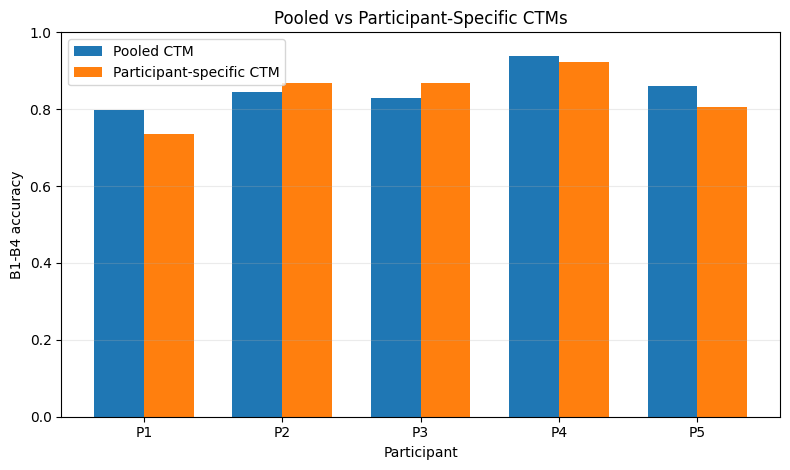

In [41]:
# ============================================================
# Pooled versus participant-specific accuracy
# ============================================================

import matplotlib.pyplot as plt

plot_df = (
    participant_comparison
    .set_index(
        "participant"
    )
)

fig, ax = plt.subplots(
    figsize=(
        8,
        4.8,
    )
)

x = np.arange(
    len(
        plot_df
    )
)

width = 0.36

ax.bar(
    x - width / 2,
    plot_df[
        "pooled_mc_accuracy"
    ],
    width,
    label="Pooled CTM",
)

ax.bar(
    x + width / 2,
    plot_df[
        "participant_specific_mc_accuracy"
    ],
    width,
    label="Participant-specific CTM",
)

ax.set_xticks(
    x,
)

ax.set_xticklabels(
    [
        f"P{participant}"
        for participant
        in plot_df.index
    ]
)

ax.set_ylim(
    0.0,
    1.0,
)

ax.set_ylabel(
    "B1-B4 accuracy"
)

ax.set_xlabel(
    "Participant"
)

ax.set_title(
    "Pooled vs Participant-Specific CTMs"
)

ax.grid(
    axis="y",
    alpha=0.25,
)

ax.legend()

plt.tight_layout()
plt.show()

### 20.4 Participant-Specific Physical-Time Anticipation

The participant-specific CTMs are now evaluated using the same physical-time anticipation protocol as the pooled model.

For each participant, the corresponding CTM is evaluated only on that participant's B1-B4 recordings and uses the scaler fitted exclusively on that participant's B0 training recordings.

Two input representations are compared at each physical lead time:

1. **Resampled-to-100:** the physically available movement prefix is resampled to 100 positions before classification.
2. **Raw variable-length:** only the physically available raw glove observations are supplied, without temporal resampling, padding, or artificial observations.

The same requested lead times are used:

- 500 ms
- 400 ms
- 300 ms
- 200 ms
- 100 ms
- object lift

The comparison tests whether participant-specific anticipation depends on presenting partial trajectories in the fixed 100-position representation used during training.

All models remain frozen during evaluation.

In [42]:
# ============================================================
# Participant-specific saved model directories
# ============================================================

participant_run_dirs = {
    1: Path(
        "results/rtg/"
        "20260928T141738Z_participant_1_b0_to_b1_b4_fixed150_seed0"
    ),

    2: Path(
        "results/rtg/"
        "20260928T143101Z_participant_2_b0_to_b1_b4_fixed150_seed0"
    ),

    3: Path(
        "results/rtg/"
        "20260928T143117Z_participant_3_b0_to_b1_b4_fixed150_seed0"
    ),

    4: Path(
        "results/rtg/"
        "20260928T143131Z_participant_4_b0_to_b1_b4_fixed150_seed0"
    ),

    5: Path(
        "results/rtg/"
        "20260928T143145Z_participant_5_b0_to_b1_b4_fixed150_seed0"
    ),
}

for participant, run_dir in (
    participant_run_dirs.items()
):
    assert run_dir.exists(), (
        f"Missing P{participant}: {run_dir}"
    )

print(
    "All participant model directories found."
)

All participant model directories found.


In [43]:
# ============================================================
# Restore one participant-specific CTM
# ============================================================

def restore_participant_specific_model(
    participant,
):
    participant = int(
        participant
    )

    run_dir = (
        participant_run_dirs[
            participant
        ]
    )

    with (
        run_dir
        / "config.json"
    ).open(
        "r",
        encoding="utf-8",
    ) as f:

        config_dict = json.load(
            f
        )

    participant_config = (
        RTGExperimentConfig(
            **config_dict
        )
    )

    bundle = (
        rtg_experiment_runner
        .build_participant_specific_transfer_bundle(
            config=participant_config,
            participant=participant,
        )
    )

    # --------------------------------------------------------
    # Verify saved participant-specific scaler
    # --------------------------------------------------------

    scaler_npz = np.load(
        run_dir
        / "scaler.npz"
    )

    np.testing.assert_allclose(
        bundle[
            "scaler"
        ]["mean"],
        scaler_npz[
            "mean"
        ],
        rtol=0.0,
        atol=1e-7,
    )

    np.testing.assert_allclose(
        bundle[
            "scaler"
        ]["std"],
        scaler_npz[
            "std"
        ],
        rtol=0.0,
        atol=1e-7,
    )

    checkpoint = torch.load(
        run_dir
        / "checkpoint.pt",
        map_location="cpu",
        weights_only=False,
    )

    participant_device = (
        resolve_device(
            participant_config.device
        )
    )

    model = build_model(
        participant_config,
        participant_device,
    )

    # Materialize lazy components.
    dry_X, _ = next(
        iter(
            bundle[
                "test_loader"
            ]
        )
    )

    with torch.no_grad():

        model(
            dry_X[
                :1
            ].to(
                participant_device
            )
        )

    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ],
        strict=True,
    )

    model.eval()

    return {
        "model":
            model,

        "device":
            participant_device,

        "config":
            participant_config,

        "bundle":
            bundle,

        "run_dir":
            run_dir,
    }

In [44]:
# ============================================================
# P1 participant-specific anticipation pilot
# ============================================================

physical_lead_times_ms = [
    500,
    400,
    300,
    200,
    100,
    0,
]

p1_restored = (
    restore_participant_specific_model(
        participant=1
    )
)

p1_resampled_physical = (
    rtg_experiment_runner
    .evaluate_physical_time_cutoffs(
        model=p1_restored[
            "model"
        ],
        device=p1_restored[
            "device"
        ],
        bundle=p1_restored[
            "bundle"
        ],
        config=p1_restored[
            "config"
        ],
        lead_times_ms=(
            physical_lead_times_ms
        ),
    )
)

p1_raw_physical = (
    rtg_experiment_runner
    .evaluate_raw_variable_length_physical_cutoffs(
        model=p1_restored[
            "model"
        ],
        device=p1_restored[
            "device"
        ],
        bundle=p1_restored[
            "bundle"
        ],
        lead_times_ms=(
            physical_lead_times_ms
        ),
    )
)

Using neuron select type: random-pairing
Synch representation size action: 32
Synch representation size out: 32


In [45]:
# ============================================================
# P1 eligibility identity check
# ============================================================

p1_eligibility_records = []

for lead_time_ms in (
    physical_lead_times_ms
):

    lead = float(
        lead_time_ms
    )

    resampled_df = (
        p1_resampled_physical[
            "metadata_by_lead"
        ][lead]
        .copy()
    )

    raw_df = (
        p1_raw_physical[
            "metadata_by_lead"
        ][lead]
        .copy()
    )

    resampled_keys = set(
        make_recording_key(
            resampled_df
        )
    )

    raw_keys = set(
        make_recording_key(
            raw_df
        )
    )

    p1_eligibility_records.append(
        {
            "lead_time_ms":
                lead_time_ms,

            "n_resampled":
                len(
                    resampled_keys
                ),

            "n_raw":
                len(
                    raw_keys
                ),

            "same_recordings":
                (
                    resampled_keys
                    ==
                    raw_keys
                ),
        }
    )


p1_eligibility_check = (
    pd.DataFrame(
        p1_eligibility_records
    )
)

p1_eligibility_check

,lead_time_ms,n_resampled,n_raw,same_recordings
0,500,113,113,True
1,400,115,115,True
2,300,123,123,True
3,200,125,125,True
4,100,125,125,True
5,0,128,128,True


In [46]:
assert (
    p1_eligibility_check[
        "same_recordings"
    ]
    .all()
)

print(
    "P1 physical-time eligibility check: PASSED"
)

P1 physical-time eligibility check: PASSED


In [47]:
# ============================================================
# P1 physical-time representation comparison
# ============================================================

p1_physical_records = []

for lead_time_ms in (
    physical_lead_times_ms
):

    lead = float(
        lead_time_ms
    )

    resampled_outputs = (
        p1_resampled_physical[
            "outputs_by_lead"
        ][lead]
    )

    raw_df = (
        p1_raw_physical[
            "metadata_by_lead"
        ][lead]
    )

    p1_physical_records.append(
        {
            "participant":
                1,

            "lead_time_ms":
                lead_time_ms,

            "n":
                len(
                    raw_df
                ),

            "resampled100_mc_accuracy":
                (
                    resampled_outputs[
                        "most_certain_prediction"
                    ]
                    ==
                    resampled_outputs[
                        "targets"
                    ]
                ).mean(),

            "resampled100_final_accuracy":
                (
                    resampled_outputs[
                        "final_prediction"
                    ]
                    ==
                    resampled_outputs[
                        "targets"
                    ]
                ).mean(),

            "raw_variable_mc_accuracy":
                raw_df[
                    "correct_most_certain"
                ].mean(),

            "raw_variable_final_accuracy":
                raw_df[
                    "correct_final_tick"
                ].mean(),

            "mean_raw_input_length":
                raw_df[
                    "input_length"
                ].mean(),

            "mean_actual_lead_ms":
                raw_df[
                    "actual_lead_ms"
                ].mean(),
        }
    )


p1_physical_comparison = (
    pd.DataFrame(
        p1_physical_records
    )
)

p1_physical_comparison

,participant,lead_time_ms,n,resampled100_mc_accuracy,resampled100_final_accuracy,raw_variable_mc_accuracy,raw_variable_final_accuracy,mean_raw_input_length,mean_actual_lead_ms
0,1,500,113,0.566372,0.566372,0.566372,0.566372,21.681416,505.238938
1,1,400,115,0.617391,0.617391,0.617391,0.617391,27.408696,409.208696
2,1,300,123,0.666667,0.666667,0.666667,0.666667,31.951220,307.414634
3,1,200,125,0.720000,0.720000,0.720000,0.720000,37.944000,205.072000
4,1,100,125,0.736000,0.736000,0.736000,0.736000,43.944000,110.456000
5,1,0,128,0.734375,0.734375,0.734375,0.734375,49.851562,0.000000


In [48]:
# ============================================================
# Participant-specific physical-time follow-up output directory
# ============================================================

STAGE4_DIR = (
    FOLLOWUP_ROOT
    / "stage4_participant_physical_time"
)

STAGE4_DIR.mkdir(
    parents=True,
    exist_ok=False,
)

print(
    "Stage 4 directory:",
    STAGE4_DIR.resolve(),
)

Stage 4 directory: /Users/arthu/Desktop/CTM_Res-Pro/models/ctm/results/rtg/20260928T123450Z_rtg_supervisor_followup/stage4_participant_physical_time


In [49]:
# ============================================================
# Evaluate one participant under both physical-time
# representations
# ============================================================

def evaluate_participant_physical_time(
    participant,
    lead_times_ms,
):
    participant = int(
        participant
    )

    restored = (
        restore_participant_specific_model(
            participant
        )
    )

    model = restored[
        "model"
    ]

    device = restored[
        "device"
    ]

    bundle = restored[
        "bundle"
    ]

    config = restored[
        "config"
    ]

    # --------------------------------------------------------
    # Representation A:
    # physical prefix -> resample to 100
    # --------------------------------------------------------

    resampled_result = (
        rtg_experiment_runner
        .evaluate_physical_time_cutoffs(
            model=model,
            device=device,
            bundle=bundle,
            config=config,
            lead_times_ms=(
                lead_times_ms
            ),
        )
    )

    # --------------------------------------------------------
    # Representation B:
    # physical prefix -> native raw sequence length
    # --------------------------------------------------------

    raw_result = (
        rtg_experiment_runner
        .evaluate_raw_variable_length_physical_cutoffs(
            model=model,
            device=device,
            bundle=bundle,
            lead_times_ms=(
                lead_times_ms
            ),
        )
    )

    comparison_records = []
    paired_by_lead = {}

    # --------------------------------------------------------
    # Pair exact recordings at every cutoff
    # --------------------------------------------------------

    for lead_time_ms in (
        lead_times_ms
    ):

        lead = float(
            lead_time_ms
        )

        resampled_metadata = (
            resampled_result[
                "metadata_by_lead"
            ][lead]
            .copy()
            .reset_index(
                drop=True
            )
        )

        resampled_outputs = (
            resampled_result[
                "outputs_by_lead"
            ][lead]
        )

        raw_metadata = (
            raw_result[
                "metadata_by_lead"
            ][lead]
            .copy()
            .reset_index(
                drop=True
            )
        )

        # ----------------------------------------------------
        # Attach resampled predictions to their recording IDs
        # ----------------------------------------------------

        resampled_metadata[
            "target_resampled"
        ] = resampled_outputs[
            "targets"
        ]

        resampled_metadata[
            "prediction_mc_resampled"
        ] = resampled_outputs[
            "most_certain_prediction"
        ]

        resampled_metadata[
            "prediction_final_resampled"
        ] = resampled_outputs[
            "final_prediction"
        ]

        # ----------------------------------------------------
        # Identity check
        # ----------------------------------------------------

        resampled_paths = set(
            resampled_metadata[
                "path"
            ].astype(str)
        )

        raw_paths = set(
            raw_metadata[
                "path"
            ].astype(str)
        )

        assert (
            resampled_paths
            ==
            raw_paths
        )

        # ----------------------------------------------------
        # Pair one-to-one by globally unique path
        # ----------------------------------------------------

        paired = (
            resampled_metadata[
                [
                    "path",
                    "participant",
                    "block",
                    "class_label",
                    "target_resampled",
                    "prediction_mc_resampled",
                    "prediction_final_resampled",
                ]
            ]
            .merge(
                raw_metadata[
                    [
                        "path",
                        "prediction_most_certain",
                        "prediction_final_tick",
                        "correct_most_certain",
                        "correct_final_tick",
                        "input_length",
                        "actual_lead_ms",
                    ]
                ],
                on="path",
                how="inner",
                validate="one_to_one",
            )
        )

        assert len(
            paired
        ) == len(
            raw_metadata
        )

        assert np.array_equal(
            paired[
                "target_resampled"
            ].to_numpy(),
            paired[
                "class_label"
            ].to_numpy(),
        )

        paired[
            "resampled_correct_mc"
        ] = (
            paired[
                "prediction_mc_resampled"
            ]
            ==
            paired[
                "class_label"
            ]
        )

        paired[
            "resampled_correct_final"
        ] = (
            paired[
                "prediction_final_resampled"
            ]
            ==
            paired[
                "class_label"
            ]
        )

        paired[
            "mc_prediction_disagreement"
        ] = (
            paired[
                "prediction_mc_resampled"
            ]
            !=
            paired[
                "prediction_most_certain"
            ]
        )

        paired[
            "final_prediction_disagreement"
        ] = (
            paired[
                "prediction_final_resampled"
            ]
            !=
            paired[
                "prediction_final_tick"
            ]
        )

        paired[
            "lead_time_ms"
        ] = lead_time_ms

        paired_by_lead[
            lead
        ] = paired

        comparison_records.append(
            {
                "participant":
                    participant,

                "lead_time_ms":
                    lead_time_ms,

                "n":
                    len(
                        paired
                    ),

                "mean_actual_lead_ms":
                    paired[
                        "actual_lead_ms"
                    ].mean(),

                "mean_raw_input_length":
                    paired[
                        "input_length"
                    ].mean(),

                "resampled100_mc_accuracy":
                    paired[
                        "resampled_correct_mc"
                    ].mean(),

                "resampled100_final_accuracy":
                    paired[
                        "resampled_correct_final"
                    ].mean(),

                "raw_variable_mc_accuracy":
                    paired[
                        "correct_most_certain"
                    ].mean(),

                "raw_variable_final_accuracy":
                    paired[
                        "correct_final_tick"
                    ].mean(),

                "mc_prediction_disagreement_rate":
                    paired[
                        "mc_prediction_disagreement"
                    ].mean(),

                "final_prediction_disagreement_rate":
                    paired[
                        "final_prediction_disagreement"
                    ].mean(),
            }
        )

    comparison = pd.DataFrame(
        comparison_records
    )

    # --------------------------------------------------------
    # Fixed common cohort
    #
    # Use recordings already valid 500 ms before lift.
    # --------------------------------------------------------

    common_paths = set(
        paired_by_lead[
            500.0
        ][
            "path"
        ]
    )

    common_records = []

    for lead_time_ms in (
        lead_times_ms
    ):

        paired = (
            paired_by_lead[
                float(
                    lead_time_ms
                )
            ]
        )

        common = paired[
            paired[
                "path"
            ].isin(
                common_paths
            )
        ].copy()

        assert len(
            common
        ) == len(
            common_paths
        )

        common_records.append(
            {
                "participant":
                    participant,

                "lead_time_ms":
                    lead_time_ms,

                "n_common":
                    len(
                        common
                    ),

                "resampled100_mc_accuracy":
                    common[
                        "resampled_correct_mc"
                    ].mean(),

                "resampled100_final_accuracy":
                    common[
                        "resampled_correct_final"
                    ].mean(),

                "raw_variable_mc_accuracy":
                    common[
                        "correct_most_certain"
                    ].mean(),

                "raw_variable_final_accuracy":
                    common[
                        "correct_final_tick"
                    ].mean(),

                "mc_prediction_disagreement_rate":
                    common[
                        "mc_prediction_disagreement"
                    ].mean(),

                "mean_raw_input_length":
                    common[
                        "input_length"
                    ].mean(),
            }
        )

    common_cohort = pd.DataFrame(
        common_records
    )

    return {
        "restored":
            restored,

        "resampled":
            resampled_result,

        "raw":
            raw_result,

        "comparison":
            comparison,

        "common_cohort":
            common_cohort,

        "paired_by_lead":
            paired_by_lead,
    }

In [53]:
import importlib
import rtg_experiment_runner

importlib.reload(
    rtg_experiment_runner
)

<module 'rtg_experiment_runner' from '/Users/arthu/Desktop/CTM_Res-Pro/models/ctm/rtg_experiment_runner.py'>

In [54]:
# ============================================================
# Evaluate all participant-specific CTMs
# ============================================================

participant_physical_results = {}

all_comparisons = []
all_common_cohorts = []

for participant in [
    1,
    2,
    3,
    4,
    5,
]:

    print()
    print(
        "=" * 72
    )

    print(
        f"Physical-time evaluation: P{participant}"
    )

    print(
        "=" * 72
    )

    result = (
        evaluate_participant_physical_time(
            participant=participant,
            lead_times_ms=(
                physical_lead_times_ms
            ),
        )
    )

    participant_physical_results[
        participant
    ] = result

    all_comparisons.append(
        result[
            "comparison"
        ]
    )

    all_common_cohorts.append(
        result[
            "common_cohort"
        ]
    )

    print(
        result[
            "comparison"
        ][
            [
                "lead_time_ms",
                "n",
                "resampled100_mc_accuracy",
                "raw_variable_mc_accuracy",
                "mc_prediction_disagreement_rate",
            ]
        ]
    )


Physical-time evaluation: P1
Using neuron select type: random-pairing
Synch representation size action: 32
Synch representation size out: 32
   lead_time_ms    n  resampled100_mc_accuracy  raw_variable_mc_accuracy  \
0           500  113                  0.566372                  0.566372   
1           400  115                  0.617391                  0.617391   
2           300  123                  0.666667                  0.666667   
3           200  125                  0.720000                  0.720000   
4           100  125                  0.736000                  0.736000   
5             0  128                  0.734375                  0.734375   

   mc_prediction_disagreement_rate  
0                         0.017699  
1                         0.000000  
2                         0.000000  
3                         0.000000  
4                         0.000000  
5                         0.000000  

Physical-time evaluation: P2
Using neuron select type: random-pai

In [55]:
# ============================================================
# Consolidated participant-specific anticipation tables
# ============================================================

participant_physical_comparison = (
    pd.concat(
        all_comparisons,
        ignore_index=True,
    )
)

participant_common_cohort = (
    pd.concat(
        all_common_cohorts,
        ignore_index=True,
    )
)

participant_physical_comparison

,participant,lead_time_ms,n,mean_actual_lead_ms,mean_raw_input_length,resampled100_mc_accuracy,resampled100_final_accuracy,raw_variable_mc_accuracy,raw_variable_final_accuracy,mc_prediction_disagreement_rate,final_prediction_disagreement_rate
0,1,500,113,505.238938,21.681416,0.566372,0.566372,0.566372,0.566372,0.017699,0.017699
1,1,400,115,409.208696,27.408696,0.617391,0.617391,0.617391,0.617391,0.000000,0.000000
2,1,300,123,307.414634,31.951220,0.666667,0.666667,0.666667,0.666667,0.000000,0.000000
3,1,200,125,205.072000,37.944000,0.720000,0.720000,0.720000,0.720000,0.000000,0.000000
4,1,100,125,110.456000,43.944000,0.736000,0.736000,0.736000,0.736000,0.000000,0.000000
5,1,0,128,0.000000,49.851562,0.734375,0.734375,0.734375,0.734375,0.000000,0.000000
6,2,500,121,506.074380,34.851240,0.537190,0.528926,0.528926,0.520661,0.008264,0.016529
7,2,400,122,407.729508,40.795082,0.606557,0.598361,0.606557,0.598361,0.000000,0.000000
8,2,300,123,309.268293,46.707317,0.642276,0.642276,0.658537,0.658537,0.016260,0.016260
9,2,200,123,203.731707,53.439024,0.707317,0.699187,0.707317,0.699187,0.016260,0.016260


In [56]:
participant_common_cohort

,participant,lead_time_ms,n_common,resampled100_mc_accuracy,resampled100_final_accuracy,raw_variable_mc_accuracy,raw_variable_final_accuracy,mc_prediction_disagreement_rate,mean_raw_input_length
0,1,500,113,0.566372,0.566372,0.566372,0.566372,0.017699,21.681416
1,1,400,113,0.628319,0.628319,0.628319,0.628319,0.000000,27.778761
2,1,300,113,0.663717,0.663717,0.663717,0.663717,0.000000,34.212389
3,1,200,113,0.716814,0.716814,0.716814,0.716814,0.000000,40.743363
4,1,100,113,0.725664,0.725664,0.725664,0.725664,0.000000,46.743363
5,1,0,113,0.716814,0.716814,0.716814,0.716814,0.000000,53.743363
6,2,500,121,0.537190,0.528926,0.528926,0.520661,0.008264,34.851240
7,2,400,121,0.603306,0.595041,0.603306,0.595041,0.000000,41.115702
8,2,300,121,0.636364,0.636364,0.652893,0.652893,0.016529,47.388430
9,2,200,121,0.702479,0.694215,0.702479,0.694215,0.016529,54.115702


In [57]:
# ============================================================
# Save participant-specific physical-time artifacts
# ============================================================

participant_physical_comparison.to_csv(
    STAGE4_DIR
    / "participant_physical_time_comparison.csv",
    index=False,
)

participant_common_cohort.to_csv(
    STAGE4_DIR
    / "participant_physical_time_common_cohort.csv",
    index=False,
)


for participant, result in (
    participant_physical_results.items()
):

    participant_dir = (
        STAGE4_DIR
        / f"participant_{participant}"
    )

    participant_dir.mkdir(
        parents=True,
        exist_ok=False,
    )

    # --------------------------------------------------------
    # Summary tables
    # --------------------------------------------------------

    result[
        "resampled"
    ][
        "summary"
    ].to_csv(
        participant_dir
        / "resampled100_summary.csv",
        index=False,
    )

    result[
        "raw"
    ][
        "summary"
    ].to_csv(
        participant_dir
        / "raw_variable_summary.csv",
        index=False,
    )

    result[
        "comparison"
    ].to_csv(
        participant_dir
        / "representation_comparison.csv",
        index=False,
    )

    result[
        "common_cohort"
    ].to_csv(
        participant_dir
        / "common_cohort_comparison.csv",
        index=False,
    )

    # --------------------------------------------------------
    # Per-cutoff detailed artifacts
    # --------------------------------------------------------

    for lead_time_ms in (
        physical_lead_times_ms
    ):

        lead = float(
            lead_time_ms
        )

        lead_dir = (
            participant_dir
            / f"lead_{int(lead_time_ms):03d}ms"
        )

        lead_dir.mkdir(
            parents=True,
            exist_ok=False,
        )

        # Paired per-recording comparison.
        result[
            "paired_by_lead"
        ][lead].to_csv(
            lead_dir
            / "paired_predictions.csv",
            index=False,
        )

        # Raw variable-length metadata.
        result[
            "raw"
        ][
            "metadata_by_lead"
        ][lead].to_csv(
            lead_dir
            / "raw_variable_metadata.csv",
            index=False,
        )

        # Explicit exclusions.
        result[
            "raw"
        ][
            "excluded_by_lead"
        ][lead].to_csv(
            lead_dir
            / "excluded_recordings.csv",
            index=False,
        )

        # Resampled outputs.
        resampled_outputs = (
            result[
                "resampled"
            ][
                "outputs_by_lead"
            ][lead]
        )

        np.savez_compressed(
            lead_dir
            / "resampled100_outputs.npz",

            **resampled_outputs,
        )

        # Raw variable-length outputs.
        raw_outputs = (
            result[
                "raw"
            ][
                "outputs_by_lead"
            ][lead]
        )

        np.savez_compressed(
            lead_dir
            / "raw_variable_outputs.npz",

            **raw_outputs,
        )


print(
    "Stage 4 physical-time artifacts:",
    STAGE4_DIR.resolve(),
)

Stage 4 physical-time artifacts: /Users/arthu/Desktop/CTM_Res-Pro/models/ctm/results/rtg/20260928T123450Z_rtg_supervisor_followup/stage4_participant_physical_time


In [58]:
# ============================================================
# Participant x physical lead-time table
# Raw variable-length representation
# ============================================================

participant_raw_latency_table = (
    participant_physical_comparison
    .pivot(
        index="participant",
        columns="lead_time_ms",
        values="raw_variable_mc_accuracy",
    )
    .sort_index(
        axis=1,
        ascending=False,
    )
)

participant_raw_latency_table

lead_time_ms,500,400,300,200,100,0
participant,,,,,,
1,0.566372,0.617391,0.666667,0.720000,0.736000,0.734375
2,0.528926,0.606557,0.658537,0.707317,0.772358,0.867188
3,0.565574,0.632000,0.682540,0.753968,0.833333,0.867188
4,0.698413,0.746032,0.795276,0.866142,0.905512,0.921875
5,0.539683,0.574803,0.653543,0.695312,0.773438,0.804688


In [59]:
# ============================================================
# Raw-variable minus resampled-to-100 accuracy
# ============================================================

participant_physical_comparison[
    "raw_minus_resampled_pp"
] = 100.0 * (
    participant_physical_comparison[
        "raw_variable_mc_accuracy"
    ]
    -
    participant_physical_comparison[
        "resampled100_mc_accuracy"
    ]
)

representation_difference_table = (
    participant_physical_comparison
    .pivot(
        index="participant",
        columns="lead_time_ms",
        values="raw_minus_resampled_pp",
    )
    .sort_index(
        axis=1,
        ascending=False,
    )
)

representation_difference_table

lead_time_ms,500,400,300,200,100,0
participant,,,,,,
1,0.000000,0.0,0.000000,0.0,0.00000,0.0
2,-0.826446,0.0,1.626016,0.0,0.00000,0.0
3,0.000000,0.0,0.793651,0.0,0.00000,0.0
4,0.793651,0.0,0.787402,0.0,0.00000,0.0
5,0.000000,0.0,0.000000,0.0,0.78125,0.0


In [60]:
# ============================================================
# Aggregate pooled versus participant-specific anticipation
# ============================================================

specific_latency_summary = (
    participant_physical_comparison
    .groupby(
        "lead_time_ms"
    )
    .apply(
        lambda group: pd.Series(
            {
                "n_total":
                    group["n"].sum(),

                "participant_specific_weighted_mc":
                    np.average(
                        group[
                            "raw_variable_mc_accuracy"
                        ],
                        weights=group[
                            "n"
                        ],
                    ),

                "participant_specific_mean_participant_mc":
                    group[
                        "raw_variable_mc_accuracy"
                    ].mean(),
            }
        ),
        include_groups=False,
    )
    .reset_index()
)

pooled_latency_summary = (
    raw_physical_summary[
        [
            "lead_time_ms",
            "n_valid",
            "accuracy_most_certain",
        ]
    ]
    .rename(
        columns={
            "n_valid":
                "pooled_n",

            "accuracy_most_certain":
                "pooled_raw_mc",
        }
    )
)

final_latency_comparison = (
    pooled_latency_summary
    .merge(
        specific_latency_summary,
        on="lead_time_ms",
        how="inner",
    )
    .sort_values(
        "lead_time_ms",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)

final_latency_comparison[
    "specific_minus_pooled_pp"
] = 100.0 * (
    final_latency_comparison[
        "participant_specific_weighted_mc"
    ]
    -
    final_latency_comparison[
        "pooled_raw_mc"
    ]
)

final_latency_comparison

,lead_time_ms,pooled_n,pooled_raw_mc,n_total,participant_specific_weighted_mc,participant_specific_mean_participant_mc,specific_minus_pooled_pp
0,500.0,608,0.534539,608.0,0.580592,0.579793,4.605263
1,400.0,615,0.622764,615.0,0.635772,0.635357,1.300813
2,300.0,626,0.699681,626.0,0.691693,0.691312,-0.798722
3,200.0,629,0.780604,629.0,0.748808,0.748548,-3.179650
4,100.0,629,0.833068,629.0,0.804452,0.804128,-2.861685
5,0.0,640,0.853125,640.0,0.839063,0.839063,-1.406250


In [61]:
# ============================================================
# Raw versus resampled prediction disagreement
# ============================================================

prediction_disagreement_table = (
    participant_physical_comparison
    .pivot(
        index="participant",
        columns="lead_time_ms",
        values="mc_prediction_disagreement_rate",
    )
    .sort_index(
        axis=1,
        ascending=False,
    )
)

prediction_disagreement_table

lead_time_ms,500,400,300,200,100,0
participant,,,,,,
1,0.017699,0.0,0.000000,0.000000,0.000000,0.0
2,0.008264,0.0,0.016260,0.016260,0.000000,0.0
3,0.000000,0.0,0.007937,0.000000,0.000000,0.0
4,0.007937,0.0,0.007874,0.000000,0.000000,0.0
5,0.000000,0.0,0.000000,0.015625,0.007812,0.0


### 20.5 Follow-Up Findings

The supervisor-requested follow-up produced three main findings.

First, the restored pooled CTM exactly reproduced the established final B0-to-B1-B4 evaluation. Its most-certain-tick accuracy was 85.31%, and its final-tick accuracy was 85.63%.

Reporting the pooled model separately by participant revealed substantial participant-level variation, with most-certain-tick accuracy ranging from approximately 80% to 94%.

Second, the CTM was found to accept variable temporal input lengths directly. Physical-time anticipation was therefore re-evaluated without stretching every available prefix to the 100-position training representation.

The raw variable-length and resampled-to-100 representations produced nearly identical anticipation results. Across participant-specific models, most representation comparisons differed by less than one percentage point, and prediction-level disagreement was below 1% at every evaluated lead time.

The early-prediction findings therefore do not appear to depend materially on resampling short physical-time prefixes to 100 positions.

Third, participant-specific CTMs did not consistently outperform the pooled CTM.

Participant-specific training improved full-trajectory transfer for P2 and P3, but reduced performance for P1, P4, and P5.

Across all 640 B1-B4 recordings:

$$
\mathrm{pooled\ MC\ accuracy} = 85.31\%
$$

whereas the participant-specific models produced:

$$
\mathrm{participant\text{-}specific\ MC\ accuracy} = 83.91\%.
$$

Because each participant contributes the same number of test recordings, the recording-weighted accuracy and mean participant accuracy are identical for this dataset.

Participant-specific models showed somewhat stronger aggregate performance at the earliest physical lead times, while the pooled model performed better closer to object lift and at the full trajectory.

These comparisons use one fixed training seed and a predetermined optimization budget. They should therefore be interpreted as participant-level behavior under the current protocol rather than as evidence of statistical superiority of pooled or participant-specific training.

The final RTG artifacts preserve the checkpoints, scalers, configurations, training histories, recording identities, per-recording predictions, and per-tick logits and certainty values required for subsequent CTM internal-dynamics analysis.